# Question 1 — data review, clustering and annual/monthly forecasting

> **Main limitation — read before the results.** Borough-month estimates are noisy: the median
> Kish effective sample size is **25.18**, **25.9%** of observed borough-months are below 20 and
> **69.4%** are below 30. A monthly target therefore contains substantial survey-estimation noise
> as well as behavioural change. All borough-month forecasts in this notebook are
> **exploratory**, even when a model improves on the seasonal baseline.
> The selected model's final-year absolute performance remains limited: Active MAE **8.59 percentage points**, Inactive MAE **7.54 points**, Fairly-active \(R^2=0.017\), and average empirical-band widths of **19.2–36.6 points**. Its 26.0% relative improvement over Seasonal Naive must be read alongside these values.

This notebook provides an auditable workflow for the prepared physical-activity panels and is intentionally numbered 02 after the unified preparation notebook:

1. load, standardise and validate all annual and monthly outputs;
2. show simple annual and monthly charts at London, Inner/Outer and borough levels;
3. audit the precision of borough-month estimates before deciding how strongly monthly borough forecasts may be interpreted;
4. use a chronological base-training, rolling-validation and untouched-test design for a fixed-origin 12-month forecast;
5. compare seasonal naive, Ridge, Random Forest and Gradient Boosting methods;
6. treat COVID as an explicit historical shock in charts, validation and model diagnostics;
7. inspect absolute errors, target-specific R², empirical error bands, residuals and low-effective-sample sensitivity;
8. run model-specific external-context ablations and compare all 372 activity fields with a compact 51-index representation;
9. cluster boroughs using Years 1–6 only and test the stability of the result;
10. forecast Year 8 after training on Years 2–6 and validation on Year 7;
11. test whether clustering adds information beyond Inner/Outer London before deciding whether any cluster forecast is justified.

The annual panels were already aggregated with `wt_final`; the monthly panels were already aggregated with `wt_time`. They must not be survey-weighted a second time. `effective_n` is used only as a reliability/sample weight for fitting and evaluation, never as a predictor.

To prevent target leakage, every survey-derived monthly predictor is lagged by exactly 12 months and every annual predictor by one survey year. No contemporaneous activity or MEMS variable is used. The COVID fields are pre-defined calendar indicators, not survey outcomes. Clustering is fitted on Years 1–6 and frozen before Year 7 validation and Year 8 testing.


In [1]:
from pathlib import Path
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from IPython.display import display, Markdown

from sklearn.base import clone
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    make_scorer,
    normalized_mutual_info_score,
    r2_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
os.environ.setdefault('LOKY_MAX_CPU_COUNT', str(os.cpu_count() or 1))
TEST_START_MONTH = 85
TEST_END_MONTH = 96
ALR_EPSILON = 1e-4
TARGETS = ['inactive_rate', 'fairly_active_rate', 'active_rate']
TARGET_LABELS = {
    'inactive_rate': 'Inactive',
    'fairly_active_rate': 'Fairly active',
    'active_rate': 'Active',
}
COMPOSITION_FEATURES = ['older_adult_rate', 'limiting_disability_rate', 'online_response_rate']
SOCIODEMOGRAPHIC_CONTEXT_FEATURES = [
    'adult_population',
    'population_age_16_34_rate',
    'population_age_65_plus_rate',
    'population_female_rate',
    'net_migration_per_1000',
    'median_weekly_earnings_gbp',
    'earnings_relative_to_london',
    'economic_inactivity_rate',
]
EXTERNAL_QUALITY_FEATURES = [
    'earnings_confidence_pct',
    'economic_inactivity_confidence_pp',
]
WEATHER_CONTEXT_FEATURES = [
    'weather_mean_temperature_c',
    'weather_total_precipitation_mm',
    'weather_total_sunshine_hours',
    'weather_mean_max_wind_kmh',
    'weather_wet_day_rate',
]
# Avoid redundant inputs: raw earnings duplicates the relative measure, adult population
# is not a direct predictor of a rate, and sex composition varies little across boroughs.
FORECAST_CONTEXT_FEATURES = [
    'population_age_16_34_rate',
    'population_age_65_plus_rate',
    'net_migration_per_1000',
    'earnings_relative_to_london',
    'economic_inactivity_rate',
] + WEATHER_CONTEXT_FEATURES
CLUSTER_CONTEXT_FEATURES = [
    'population_age_16_34_rate',
    'population_age_65_plus_rate',
    'population_female_rate',
    'net_migration_per_1000',
    'earnings_relative_to_london',
    'economic_inactivity_rate',
]
ACTIVITY_PREFIXES = ('MONTHS12_RATE_', 'DAYS_ANY_RATE_', 'DAYS_2PLUS_RATE_')

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == 'physical_activity_analysis' else cwd
DATA_DIR = PROJECT_ROOT / 'physical_activity_analysis' / 'csv_outputs'
OUTPUT_DIR = PROJECT_ROOT / 'physical_activity_analysis' / 'prediction_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PATHS = {
    'london_annual': DATA_DIR / 'question1_london_annual.csv',
    'area_annual': DATA_DIR / 'question1_inner_outer_annual.csv',
    'borough_annual': DATA_DIR / 'question1_borough_annual.csv',
    'london_monthly': DATA_DIR / 'question1_london_monthly.csv',
    'area_monthly': DATA_DIR / 'question1_inner_outer_monthly.csv',
    'borough_monthly': DATA_DIR / 'question1_borough_monthly.csv',
}
assert all(path.exists() for path in PATHS.values())

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)

# London/England calendar periods used consistently in charts and modelling.
# End dates are exclusive so that the full final month is included.
COVID_PERIODS = (
    {
        'label': 'Major restrictions and staged reopening',
        'start': pd.Timestamp('2020-03-01'),
        'end': pd.Timestamp('2021-08-01'),
    },
    {
        'label': 'Omicron / Plan B',
        'start': pd.Timestamp('2021-12-01'),
        'end': pd.Timestamp('2022-03-01'),
    },
)


def covid_restriction_flag(dates):
    dates = pd.to_datetime(dates)
    flag = np.zeros(len(dates), dtype=int)
    for period in COVID_PERIODS:
        flag |= ((dates >= period['start']) & (dates < period['end'])).astype(int)
    return flag


def shade_covid_periods(ax, show_labels=False):
    for index, period in enumerate(COVID_PERIODS):
        label = period['label'] if show_labels else None
        ax.axvspan(
            period['start'],
            period['end'],
            color='#78909c',
            alpha=0.12,
            linewidth=0,
            label=label,
            zorder=0,
        )


## 1. Load the six prepared panels

**Purpose.** Establish the analysis inventory without modifying source files.

Dates are parsed in memory and London, Inner/Outer and borough panels remain separate; combining
levels would count the same survey evidence more than once. The inventory verifies dimensions,
geography counts and the stable activity schema before analysis begins.


In [2]:
panels = {name: pd.read_csv(path) for name, path in PATHS.items()}
for name, frame in panels.items():
    if 'period_start' in frame.columns:
        frame['period_start'] = pd.to_datetime(frame['period_start'], format='%Y-%m')

london_annual = panels['london_annual']
area_annual = panels['area_annual']
borough_annual = panels['borough_annual']
london_monthly = panels['london_monthly']
area_monthly = panels['area_monthly']
borough_monthly = panels['borough_monthly']

activity_columns = [
    column for column in borough_monthly.columns if column.startswith(ACTIVITY_PREFIXES)
]
activity_counts = {
    prefix: sum(column.startswith(prefix) for column in activity_columns)
    for prefix in ACTIVITY_PREFIXES
}

inventory = []
for name, frame in panels.items():
    inventory.append(
        {
            'panel': name,
            'rows': len(frame),
            'columns': len(frame.columns),
            'geographies': frame['geography_name'].nunique(),
            'all-target-missing rows': int(frame[TARGETS].isna().all(axis=1).sum()),
        }
    )
display(pd.DataFrame(inventory))


,panel,rows,columns,geographies,all-target-missing rows
0,london_annual,8,400,1,0
1,area_annual,16,401,2,0
2,borough_annual,256,401,32,0
3,london_monthly,96,403,1,0
4,area_monthly,192,404,2,0
5,borough_monthly,3072,404,32,1


### Findings

All expected panels are present: 8/16/256 annual rows and 96/192/3,072 monthly rows at
London/Inner–Outer/borough levels. The schema contains 124 variables in each of the three activity
families (**372 total**). Only one borough-month has all outcomes missing.


## 2. Data-quality gate

The notebook stops if keys repeat, numeric values are infinite, rates leave `[0, 1]`, activity
columns drift, outcomes fail to sum to one, or an upstream split label appears. Missing survey
estimates stay missing. Compact quality summaries are exported for audit.


In [3]:
EXPECTED_ROWS = {
    'london_annual': 8,
    'area_annual': 16,
    'borough_annual': 256,
    'london_monthly': 96,
    'area_monthly': 192,
    'borough_monthly': 3072,
}
KEYS = {
    'london_annual': ['year'],
    'area_annual': ['year', 'geography_code'],
    'borough_annual': ['year', 'geography_code'],
    'london_monthly': ['month_index'],
    'area_monthly': ['month_index', 'geography_code'],
    'borough_monthly': ['month_index', 'geography_code'],
}

quality_rows = []
for name, frame in panels.items():
    assert len(frame) == EXPECTED_ROWS[name]
    assert not frame.duplicated(KEYS[name]).any()
    assert 'data_split' not in frame.columns
    assert not any(column.startswith(('MEMS7_', 'MEMS7GR_')) for column in frame.columns)
    panel_activity = [column for column in frame.columns if column.startswith(ACTIVITY_PREFIXES)]
    assert panel_activity == activity_columns

    observed = frame[TARGETS].notna().all(axis=1)
    assert frame.loc[observed, TARGETS + COMPOSITION_FEATURES].notna().all().all()
    assert (
        frame.loc[observed, TARGETS + COMPOSITION_FEATURES]
        .apply(lambda series: series.between(0, 1))
        .all()
        .all()
    )
    assert np.allclose(frame.loc[observed, TARGETS].sum(axis=1), 1.0, atol=1e-10)
    assert frame.loc[observed, 'effective_n'].gt(0).all()
    assert frame.loc[observed, activity_columns].stack().between(0, 1).all()
    external_columns = (
        SOCIODEMOGRAPHIC_CONTEXT_FEATURES + EXTERNAL_QUALITY_FEATURES + WEATHER_CONTEXT_FEATURES
    )
    assert frame[external_columns].notna().all().all()
    assert np.isfinite(frame[external_columns].to_numpy(float)).all()
    rate_columns = [
        'population_age_16_34_rate',
        'population_age_65_plus_rate',
        'population_female_rate',
        'economic_inactivity_rate',
        'weather_wet_day_rate',
    ]
    assert frame[rate_columns].apply(lambda series: series.between(0, 1)).all().all()

    quality_rows.append(
        {
            'panel': name,
            'observed rows': int(observed.sum()),
            'missing rows': int((~observed).sum()),
            'minimum effective_n': frame.loc[observed, 'effective_n'].min(),
            'median effective_n': frame.loc[observed, 'effective_n'].median(),
            'activity missing cells (%)': 100 * frame[activity_columns].isna().to_numpy().mean(),
        }
    )

quality_summary = pd.DataFrame(quality_rows)
display(
    quality_summary.style.format(
        {
            'minimum effective_n': '{:.2f}',
            'median effective_n': '{:.2f}',
            'activity missing cells (%)': '{:.3f}',
        }
    )
)

missing_borough_months = borough_monthly.loc[
    borough_monthly[TARGETS].isna().all(axis=1),
    ['month_index', 'period_start', 'geography_code', 'geography_name'],
]
assert missing_borough_months.to_dict('records') == [
    {
        'month_index': 60,
        'period_start': pd.Timestamp('2020-10-01'),
        'geography_code': 'E09000002',
        'geography_name': 'Barking and Dagenham',
    }
]
display(missing_borough_months)


,panel,observed rows,missing rows,minimum effective_n,median effective_n,activity missing cells (%)
0,london_annual,8,0,8669.77,9163.01,0.000
1,area_annual,16,0,3458.68,4569.56,0.000
2,borough_annual,256,0,212.55,294.72,0.000
3,london_monthly,96,0,267.61,746.42,0.000
4,area_monthly,192,0,117.47,366.00,0.000
5,borough_monthly,3071,1,2.80,25.18,0.033


,month_index,period_start,geography_code,geography_name
1888,60,2020-10-01,E09000002,Barking and Dagenham


,panel,variable group,variables,missing cells,missing cells (%)
35,borough_monthly,three outcomes,3,3,0.033
36,borough_monthly,three composition fields,3,3,0.033
37,borough_monthly,372 activity fields,372,372,0.033
38,borough_monthly,effective sample size,1,1,0.033


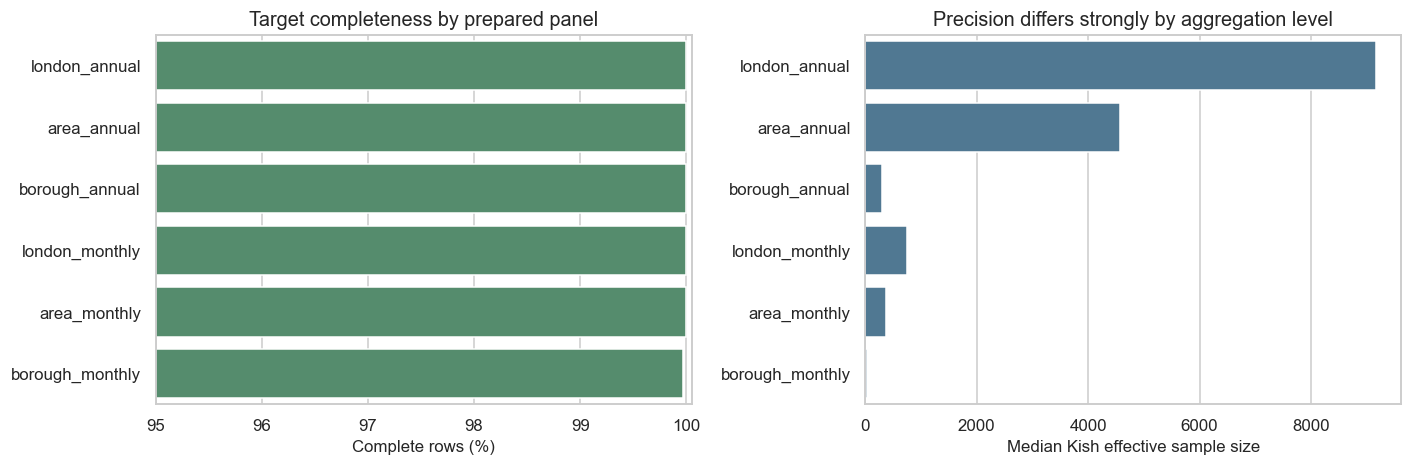

In [4]:
# Compact, analysis-specific missingness and reliability audit.
quality_group_rows = []
variable_groups = {
    'three outcomes': TARGETS,
    'three composition fields': COMPOSITION_FEATURES,
    '372 activity fields': activity_columns,
    'effective sample size': ['effective_n'],
    'eight socioeconomic/demographic fields': SOCIODEMOGRAPHIC_CONTEXT_FEATURES,
    'five weather fields': WEATHER_CONTEXT_FEATURES,
    'two external-source uncertainty fields': EXTERNAL_QUALITY_FEATURES,
}
for panel_name, frame in panels.items():
    numeric = frame.select_dtypes(include=[np.number])
    assert np.isfinite(numeric.to_numpy()[~np.isnan(numeric.to_numpy())]).all()
    for group_name, columns in variable_groups.items():
        cells = frame[columns]
        quality_group_rows.append(
            {
                'panel': panel_name,
                'variable group': group_name,
                'variables': len(columns),
                'missing cells': int(cells.isna().to_numpy().sum()),
                'missing cells (%)': 100 * cells.isna().to_numpy().mean(),
            }
        )

quality_by_group = pd.DataFrame(quality_group_rows)
quality_summary.to_csv(
    OUTPUT_DIR / 'question1_panel_quality_summary.csv', index=False, encoding='utf-8-sig'
)
quality_by_group.to_csv(
    OUTPUT_DIR / 'question1_panel_missingness_summary.csv', index=False, encoding='utf-8-sig'
)

display(
    quality_by_group.loc[quality_by_group['missing cells'].gt(0)].style.format(
        {'missing cells (%)': '{:.3f}'}
    )
)

plot_quality = quality_summary.copy()
plot_quality['target-complete rows (%)'] = (
    100
    * plot_quality['observed rows']
    / (plot_quality['observed rows'] + plot_quality['missing rows'])
)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
sns.barplot(
    data=plot_quality, y='panel', x='target-complete rows (%)', color='#4c956c', ax=axes[0]
)
axes[0].set(
    xlim=(95, 100.05),
    title='Target completeness by prepared panel',
    xlabel='Complete rows (%)',
    ylabel='',
)
sns.barplot(data=plot_quality, y='panel', x='median effective_n', color='#457b9d', ax=axes[1])
axes[1].set(
    title='Precision differs strongly by aggregation level',
    xlabel='Median Kish effective sample size',
    ylabel='',
)
plt.tight_layout()
plt.show()


### Findings

Every structural, range and composition check passes. The sole empty outcome row is Barking and
Dagenham in October 2020 and remains visible rather than imputed. External fields are complete, and
no upstream train/test marker has leaked into the panels.


## 3. Annual descriptive patterns

The figures move from London totals to Inner/Outer comparison and borough trajectories. They show
what changed, not why it changed; contextual explanation is reserved for Notebook 03.


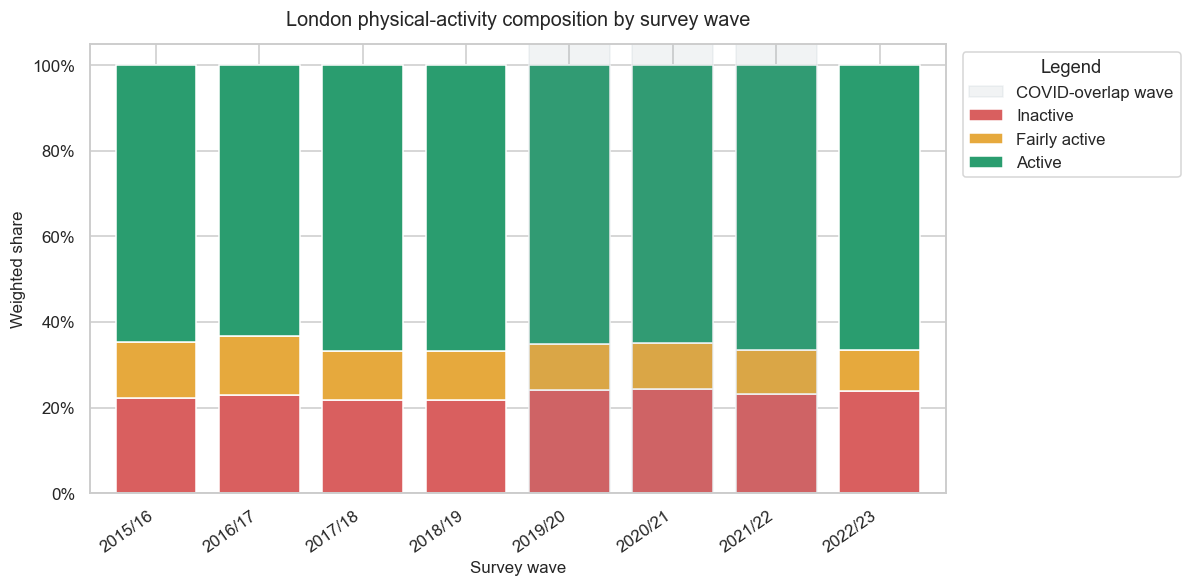

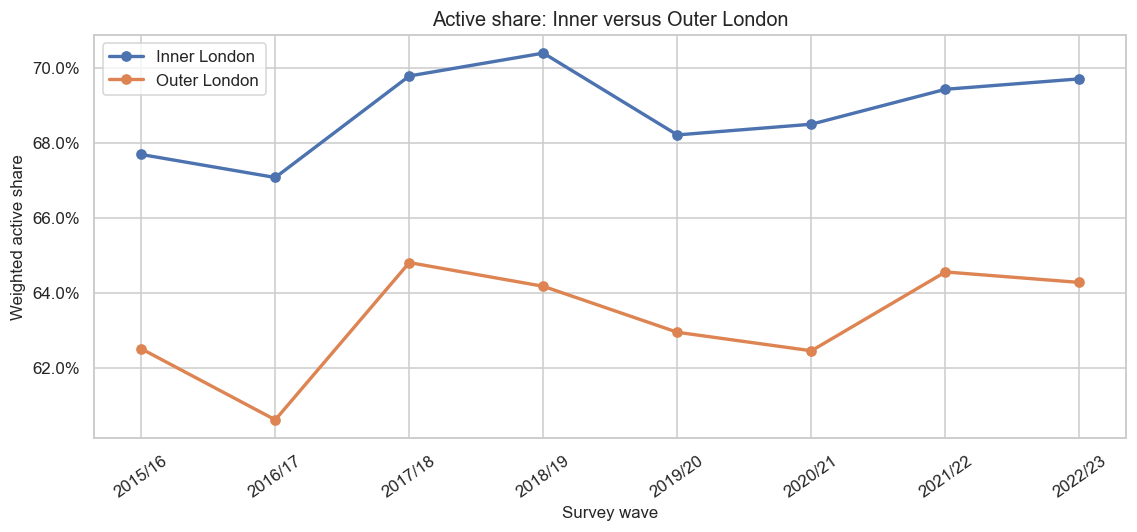

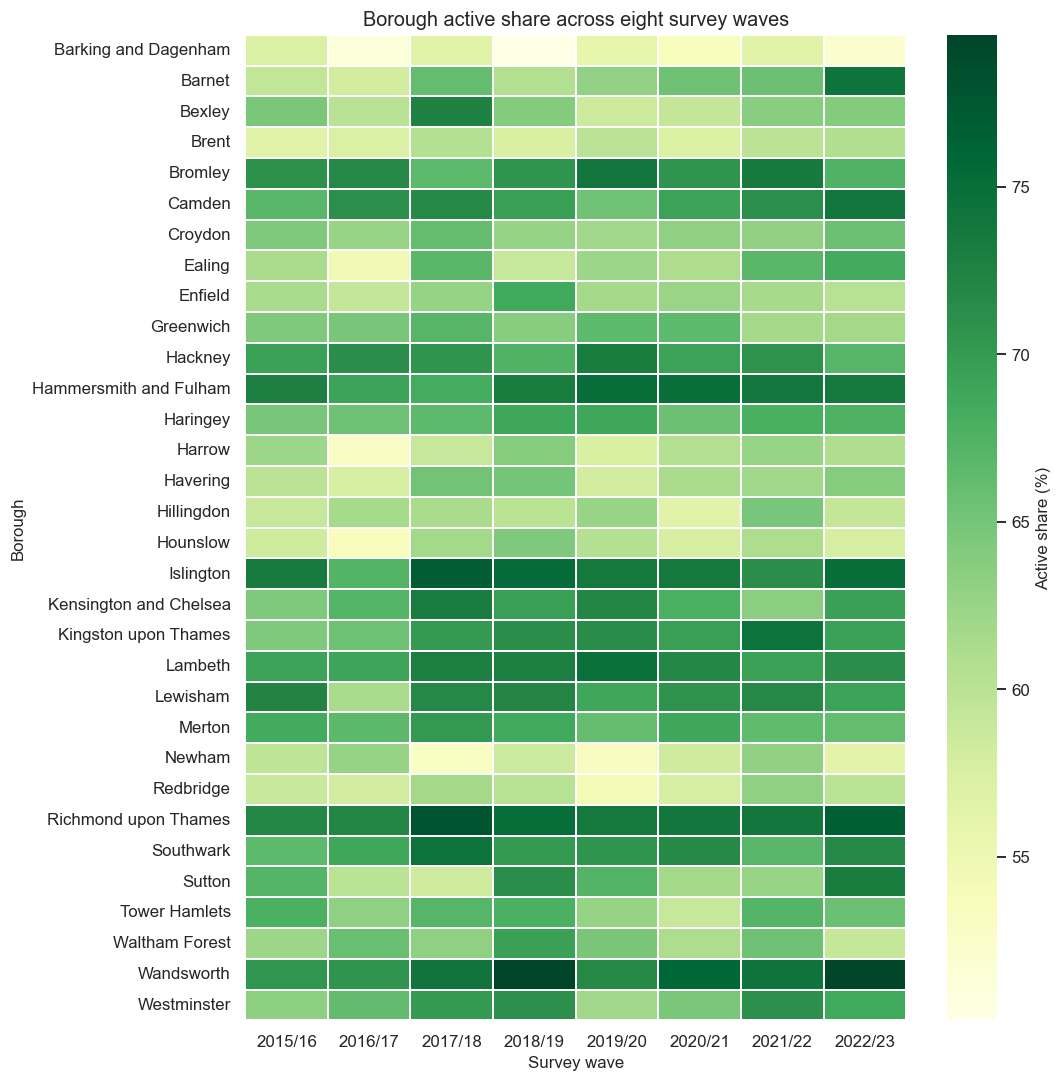

In [5]:
annual_plot = london_annual.set_index('survey_wave')[TARGETS].mul(100)
annual_plot.columns = [TARGET_LABELS[column] for column in TARGETS]
ax = annual_plot.plot(
    kind='bar',
    stacked=True,
    figsize=(11, 5.5),
    color=['#d95f5f', '#e6a93d', '#2a9d6f'],
    width=0.78,
)
for position, wave in enumerate(annual_plot.index):
    if wave in {'2019/20', '2020/21', '2021/22'}:
        ax.axvspan(
            position - 0.39,
            position + 0.39,
            color='#78909c',
            alpha=0.10,
            label='COVID-overlap wave' if wave == '2019/20' else None,
        )
ax.set(xlabel='Survey wave', ylabel='Weighted share')
ax.set_title('London physical-activity composition by survey wave', pad=12)
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.legend(title='Legend', loc='upper left', bbox_to_anchor=(1.01, 1.0))
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10.5, 5))
for area_name, group in area_annual.groupby('inner_outer', sort=False):
    ax.plot(
        group['survey_wave'],
        100 * group['active_rate'],
        marker='o',
        linewidth=2.2,
        label=area_name,
    )
ax.set(
    title='Active share: Inner versus Outer London',
    xlabel='Survey wave',
    ylabel='Weighted active share',
)
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.tick_params(axis='x', rotation=35)
ax.legend()
plt.tight_layout()
plt.show()

borough_heat = borough_annual.pivot(
    index='geography_name', columns='survey_wave', values='active_rate'
)
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    100 * borough_heat, cmap='YlGn', linewidths=0.15, cbar_kws={'label': 'Active share (%)'}, ax=ax
)
ax.set(
    title='Borough active share across eight survey waves', xlabel='Survey wave', ylabel='Borough'
)
plt.tight_layout()
plt.show()


### Findings

London active share rises modestly from **64.6% to 66.4%** between 2015/16 and 2022/23, with a dip
around 2019/20–2020/21 and recovery thereafter. Borough trajectories vary much more than the London
average, so the aggregate trend should not be treated as a universal borough path.


## 4. External context: coverage and descriptive association

Coverage and ranges are reviewed first. For the borough correlation plot, variables are centred
within survey year so the comparison asks why boroughs differ **at the same time**. Weather is
separate because one London-wide series cannot explain same-month borough differences. These are
descriptive associations, not policy or causal estimates.


,file,decision,role,reason,source
0,myebtablesenglandwales20112024.xlsx,included,actual population age/sex structure and net mi...,official annual estimates; complete 2015–2023 ...,ONS mid-year population estimates and componen...
1,earnings-residence-borough.xlsx,included,residence-based median weekly earnings,complete 2015–2023 coverage for the 32 study b...,ONS Annual Survey of Hours and Earnings via Lo...
2,economic-inactivity.csv,included,working-age economic inactivity rate,official APS annual series with complete study...,ONS Annual Population Survey via London Datastore
3,open-meteo historical weather data,included,London-wide monthly weather context,daily historical values cover every month from...,Open-Meteo historical weather API and user-sup...
4,2022_Identified_Capacity_10yr_central_fert_std...,excluded,GLA demographic projections,projections are unnecessary because actual ONS...,GLA 2022-based demographic projections
5,open-meteo-51.50N0.10W23m.csv,excluded,2024–2030 climate-model projections,future model scenarios are not observations an...,Open-Meteo climate projections
6,MPS Borough Level Crime.csv,excluded,borough crime,starts 2020-06 and offence definitions change ...,Metropolitan Police Service
7,nomis_2026_07_14_*.xlsx,excluded,intended APS extracts,both workbooks contain only a title and no obs...,Nomis download attempts


,variable,rows,missing,minimum,median,maximum
0,adult_population,288,0,123715.000,221997.000,320227.000
1,population_age_16_34_rate,288,0,0.242,0.359,0.547
2,population_age_65_plus_rate,288,0,0.069,0.141,0.226
3,population_female_rate,288,0,0.492,0.522,0.542
4,net_migration_per_1000,288,0,-26.060,-2.000,27.592
5,median_weekly_earnings_gbp,288,0,421.600,581.800,855.900
6,earnings_relative_to_london,288,0,0.793,0.973,1.402
7,economic_inactivity_rate,288,0,0.088,0.211,0.357
8,earnings_confidence_pct,288,0,2.900,5.000,12.000
9,economic_inactivity_confidence_pp,288,0,3.100,4.000,8.400


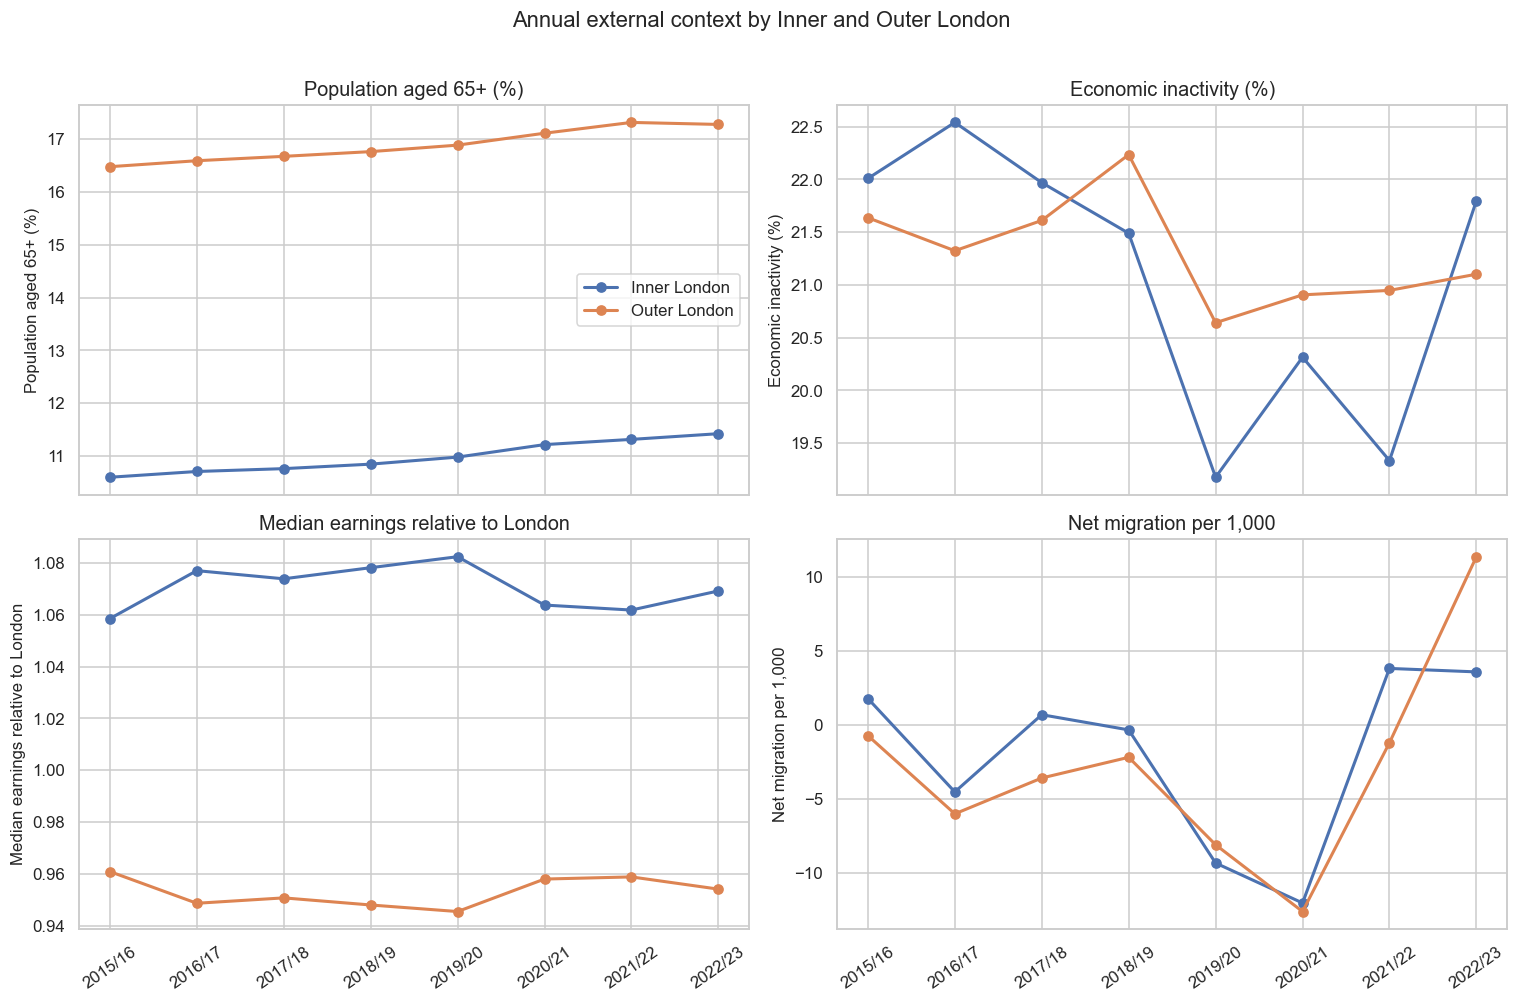

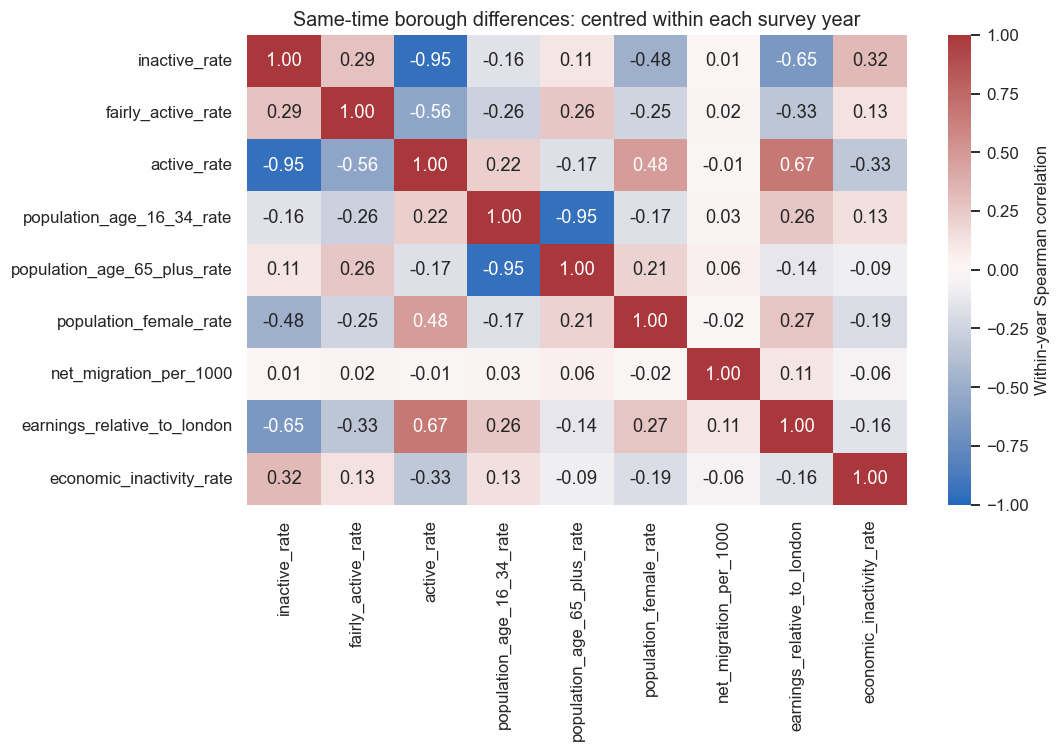

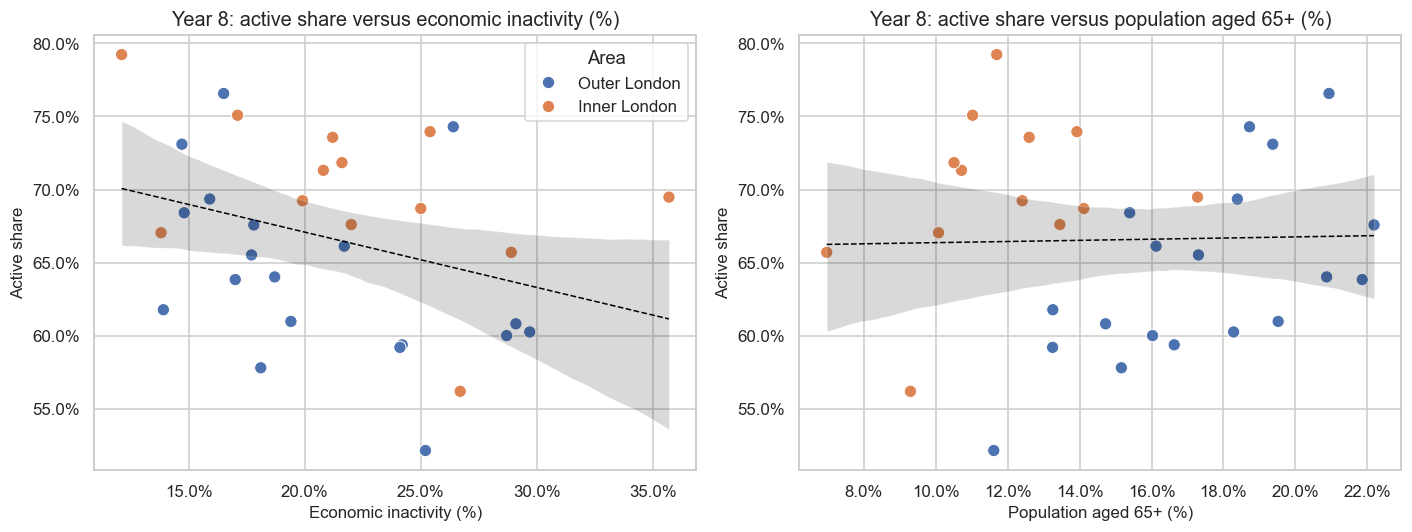

In [6]:
external_inventory = pd.read_csv(DATA_DIR / 'question1_external_data_inventory.csv')
external_quality = pd.read_csv(DATA_DIR / 'question1_external_quality_summary.csv')
display(external_inventory)
display(
    external_quality.style.format(
        {
            'minimum': '{:.3f}',
            'median': '{:.3f}',
            'maximum': '{:.3f}',
        }
    )
)

context_plot_specs = [
    ('population_age_65_plus_rate', 'Population aged 65+ (%)', 100),
    ('economic_inactivity_rate', 'Economic inactivity (%)', 100),
    ('earnings_relative_to_london', 'Median earnings relative to London', 1),
    ('net_migration_per_1000', 'Net migration per 1,000', 1),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for ax, (variable, ylabel, multiplier) in zip(axes.flat, context_plot_specs):
    for area_name, group in area_annual.groupby('inner_outer', sort=False):
        ax.plot(
            group['survey_wave'],
            multiplier * group[variable],
            marker='o',
            linewidth=2,
            label=area_name,
        )
    ax.set(title=ylabel, xlabel='', ylabel=ylabel)
    ax.tick_params(axis='x', rotation=35)
axes[0, 0].legend()
plt.suptitle('Annual external context by Inner and Outer London', y=1.01)
plt.tight_layout()
plt.show()

same_time_variables = TARGETS + CLUSTER_CONTEXT_FEATURES
within_year = borough_annual[same_time_variables].copy()
within_year = within_year - borough_annual.groupby('year')[same_time_variables].transform('mean')
same_time_correlation = within_year.corr(method='spearman')
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    same_time_correlation,
    vmin=-1,
    vmax=1,
    center=0,
    cmap='vlag',
    annot=True,
    fmt='.2f',
    cbar_kws={'label': 'Within-year Spearman correlation'},
    ax=ax,
)
ax.set_title('Same-time borough differences: centred within each survey year')
plt.tight_layout()
plt.show()

latest_context = borough_annual.loc[borough_annual['year'].eq(borough_annual['year'].max())]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, variable, label in [
    (axes[0], 'economic_inactivity_rate', 'Economic inactivity (%)'),
    (axes[1], 'population_age_65_plus_rate', 'Population aged 65+ (%)'),
]:
    sns.scatterplot(
        data=latest_context, x=variable, y='active_rate', hue='inner_outer', s=65, ax=ax
    )
    sns.regplot(
        data=latest_context,
        x=variable,
        y='active_rate',
        scatter=False,
        color='black',
        line_kws={'linestyle': '--', 'linewidth': 1},
        ax=ax,
    )
    ax.set(
        xlabel=label, ylabel='Active share', title=f'Year 8: active share versus {label.lower()}'
    )
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.yaxis.set_major_formatter(PercentFormatter(1))
axes[1].get_legend().remove()
axes[0].legend(title='Area')
plt.tight_layout()
plt.show()


### Findings

The 288 borough-year context rows are complete. Across borough-years, median weekly earnings range
from about **£422 to £856**, economic inactivity from **8.8% to 35.7%**, and net migration from
about **−26 to +28 per 1,000**. The within-year plots show meaningful borough contrasts, but these
unadjusted relationships are not interpreted causally.


## 5. Monthly patterns and the borough-sample decision

London and Inner/Outer time series are shown with approximate Kish-based Wilson bands. Borough
precision is then evaluated against pre-declared effective-sample thresholds before any model is
fitted. The final chart identifies common activity families but does not treat overlapping activity
items as a composition.


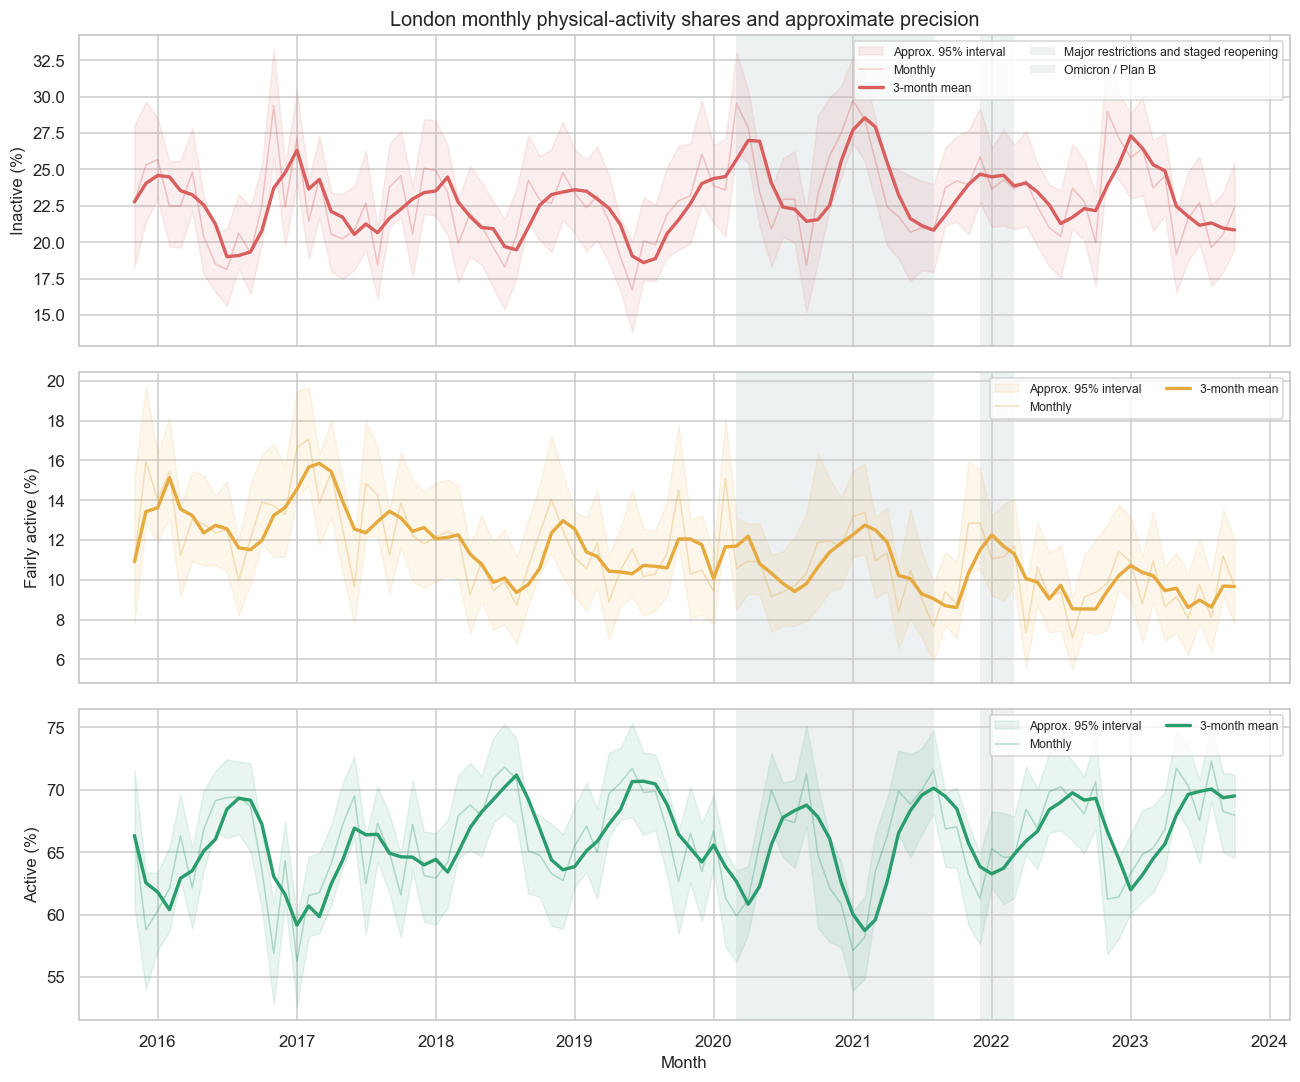

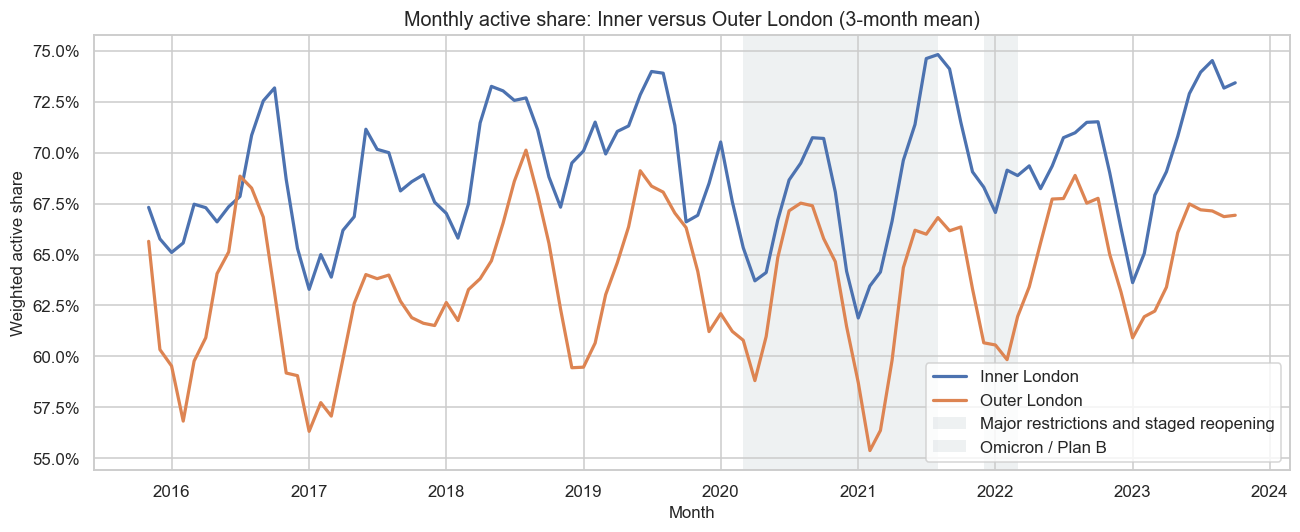

In [7]:
def wilson_interval(proportion, effective_n, z=1.96):
    p = np.asarray(proportion, dtype=float)
    n = np.asarray(effective_n, dtype=float)
    denominator = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denominator
    radius = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denominator
    return np.clip(centre - radius, 0, 1), np.clip(centre + radius, 0, 1)


fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
colors = ['#d95f5f', '#e6a93d', '#2a9d6f']
for ax, target, color in zip(axes, TARGETS, colors):
    raw_share = london_monthly[target]
    smooth = 100 * raw_share.rolling(3, min_periods=1).mean()
    ci_low, ci_high = wilson_interval(raw_share, london_monthly['effective_n'])
    ax.fill_between(
        london_monthly['period_start'],
        100 * ci_low,
        100 * ci_high,
        color=color,
        alpha=0.10,
        label='Approx. 95% interval',
    )
    ax.plot(
        london_monthly['period_start'],
        100 * raw_share,
        color=color,
        alpha=0.32,
        linewidth=1,
        label='Monthly',
    )
    ax.plot(
        london_monthly['period_start'], smooth, color=color, linewidth=2.2, label='3-month mean'
    )
    shade_covid_periods(ax, show_labels=(target == TARGETS[0]))
    ax.set_ylabel(TARGET_LABELS[target] + ' (%)')
    ax.legend(loc='upper right', fontsize=8, ncol=2)
axes[0].set_title('London monthly physical-activity shares and approximate precision')
axes[-1].set_xlabel('Month')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
for area_name, group in area_monthly.groupby('inner_outer', sort=False):
    group = group.sort_values('month_index')
    smooth = group['active_rate'].rolling(3, min_periods=1).mean()
    ax.plot(group['period_start'], 100 * smooth, linewidth=2.1, label=area_name)
shade_covid_periods(ax, show_labels=True)
ax.set(
    title='Monthly active share: Inner versus Outer London (3-month mean)',
    xlabel='Month',
    ylabel='Weighted active share',
)
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.legend()
plt.tight_layout()
plt.show()


In [9]:
# Pre-declared project diagnostic rules; neither value is an official suppression threshold.
VERY_LOW_EFFECTIVE_N = 10
LOW_EFFECTIVE_N = 20
PREFERRED_EFFECTIVE_N = 30
MAX_ACCEPTABLE_SHARE_BELOW_20 = 0.20

monthly_observed = (
    borough_monthly.loc[
        borough_monthly[TARGETS].notna().all(axis=1) & borough_monthly['effective_n'].gt(0)
    ]
    .sort_values(['geography_code', 'month_index'])
    .copy()
)
monthly_observed['effective_n_band'] = pd.cut(
    monthly_observed['effective_n'],
    bins=[0, VERY_LOW_EFFECTIVE_N, LOW_EFFECTIVE_N, PREFERRED_EFFECTIVE_N, np.inf],
    right=False,
    labels=['<10 (very low)', '10–<20 (low)', '20–<30 (caution)', '≥30 (preferred)'],
)

target_change = monthly_observed.groupby('geography_code', sort=False)[TARGETS].diff().abs()
monthly_observed['month_to_month_tv'] = 0.5 * target_change.sum(axis=1, min_count=len(TARGETS))

median_effective_n = monthly_observed['effective_n'].median()
share_below_20 = monthly_observed['effective_n'].lt(LOW_EFFECTIVE_N).mean()
share_below_30 = monthly_observed['effective_n'].lt(PREFERRED_EFFECTIVE_N).mean()
worst_case_moe_at_median = 1.96 * np.sqrt(0.25 / median_effective_n)
MONTHLY_BOROUGH_EXPLORATORY = bool(
    median_effective_n < PREFERRED_EFFECTIVE_N or share_below_20 > MAX_ACCEPTABLE_SHARE_BELOW_20
)
MONTHLY_BOROUGH_STATUS = 'Exploratory' if MONTHLY_BOROUGH_EXPLORATORY else 'Primary'

reliability_threshold_summary = pd.DataFrame(
    [
        {
            'threshold': threshold,
            'rows below threshold': int(monthly_observed['effective_n'].lt(threshold).sum()),
            'share below threshold': monthly_observed['effective_n'].lt(threshold).mean(),
        }
        for threshold in [VERY_LOW_EFFECTIVE_N, LOW_EFFECTIVE_N, PREFERRED_EFFECTIVE_N]
    ]
)
reliability_band_summary = (
    monthly_observed.groupby('effective_n_band', observed=True)
    .agg(
        rows=('effective_n', 'size'),
        median_effective_n=('effective_n', 'median'),
        median_month_to_month_tv=('month_to_month_tv', 'median'),
        mean_month_to_month_tv=('month_to_month_tv', 'mean'),
    )
    .reset_index()
)
reliability_by_month = monthly_observed.groupby(
    ['month_index', 'period_start'], as_index=False
).agg(
    median_effective_n=('effective_n', 'median'),
    share_below_20=('effective_n', lambda values: values.lt(LOW_EFFECTIVE_N).mean()),
    share_below_30=('effective_n', lambda values: values.lt(PREFERRED_EFFECTIVE_N).mean()),
)
reliability_by_borough = (
    monthly_observed.groupby(['geography_code', 'geography_name'], as_index=False)
    .agg(
        median_effective_n=('effective_n', 'median'),
        share_below_20=('effective_n', lambda values: values.lt(LOW_EFFECTIVE_N).mean()),
        share_below_30=('effective_n', lambda values: values.lt(PREFERRED_EFFECTIVE_N).mean()),
    )
    .sort_values('median_effective_n')
)

display(reliability_threshold_summary.style.format({'share below threshold': '{:.1%}'}))
display(
    reliability_band_summary.style.format(
        {
            'median_effective_n': '{:.1f}',
            'median_month_to_month_tv': '{:.1%}',
            'mean_month_to_month_tv': '{:.1%}',
        }
    )
)


,threshold,rows below threshold,share below threshold
0,10,61,2.0%
1,20,794,25.9%
2,30,2130,69.4%


,effective_n_band,rows,median_effective_n,median_month_to_month_tv,mean_month_to_month_tv
0,<10 (very low),61,8.1,17.9%,21.7%
1,10–<20 (low),733,17.0,14.8%,16.1%
2,20–<30 (caution),1336,24.7,13.3%,14.4%
3,≥30 (preferred),941,35.3,11.7%,13.0%


### Precision visualisation

The distribution, threshold prevalence, borough heat map and sample-size/volatility relationship make the reliability decision visible rather than hiding it in a single summary number.


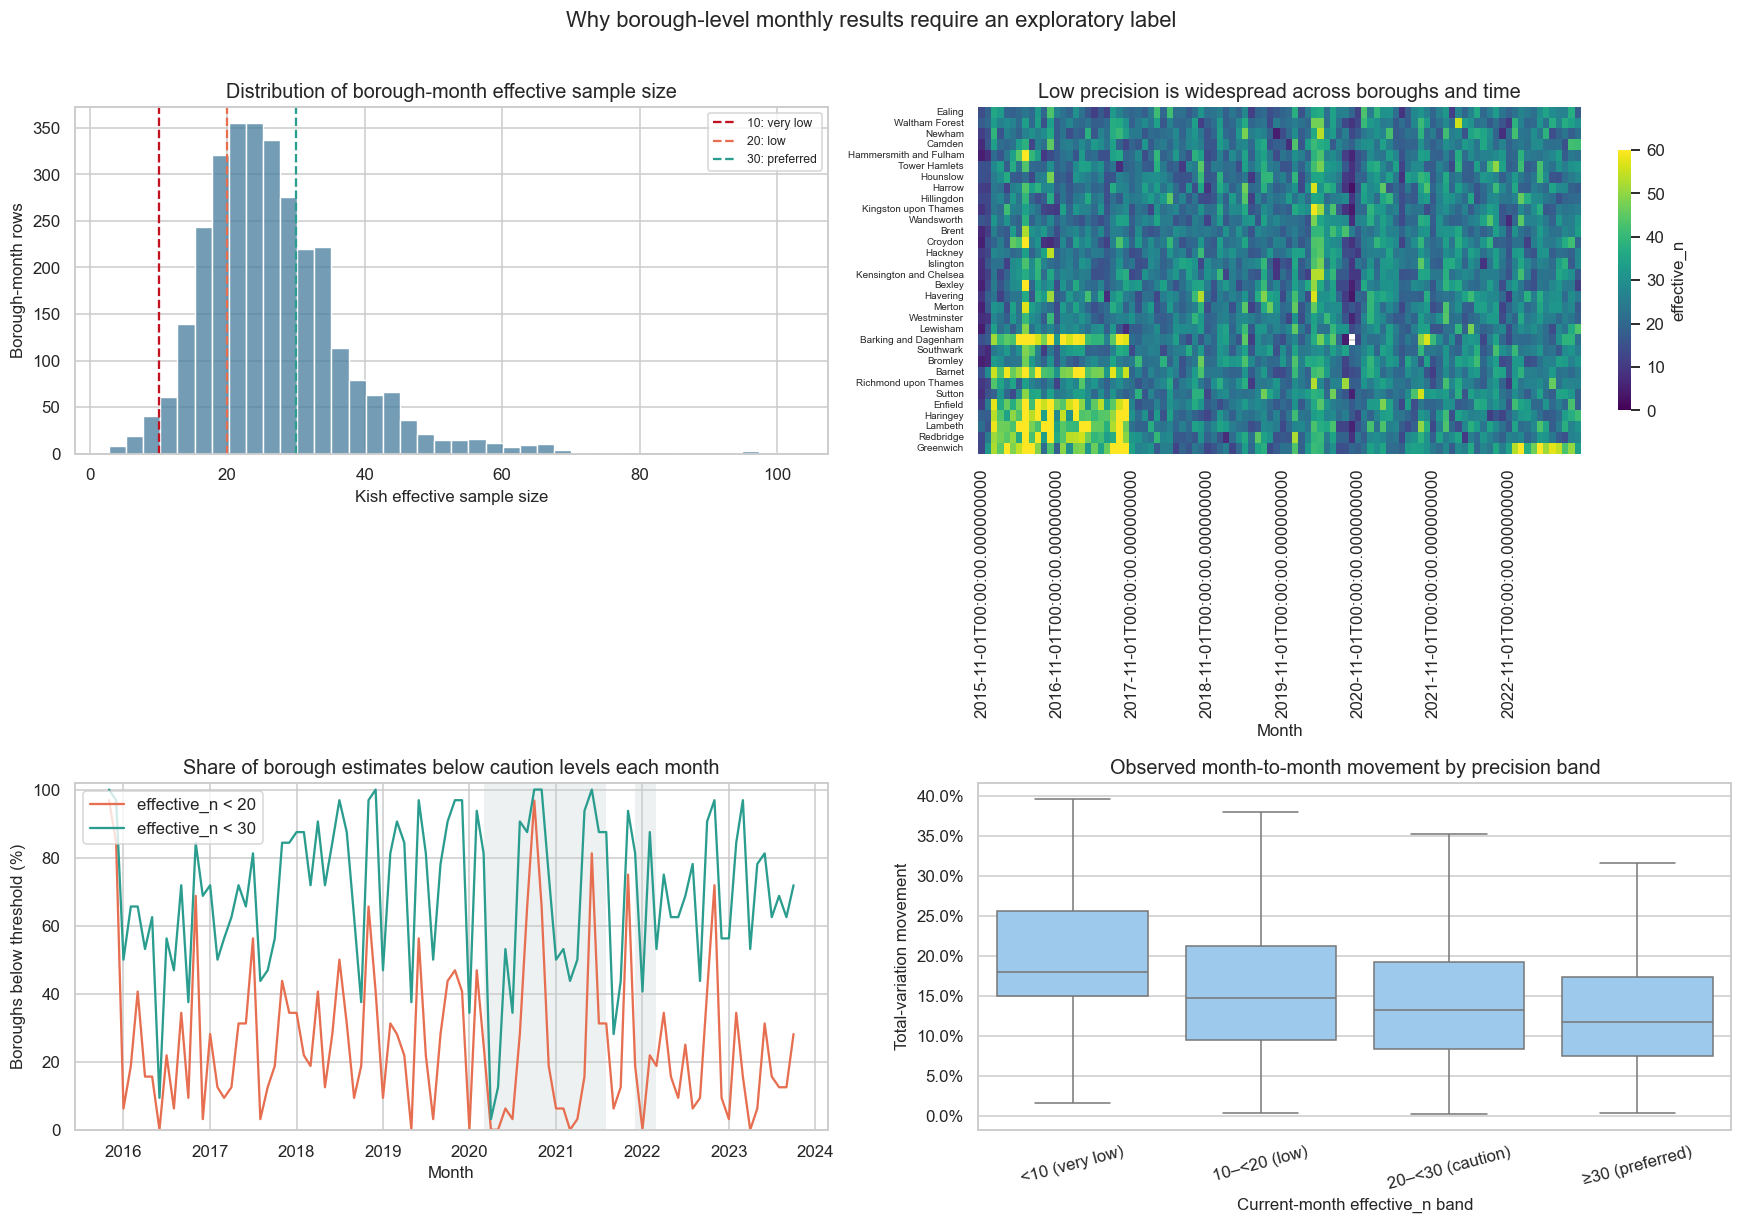

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
sns.histplot(monthly_observed['effective_n'], bins=40, color='#457b9d', ax=axes[0, 0])
for threshold, color, label in [
    (10, '#c1121f', '10: very low'),
    (20, '#e76f51', '20: low'),
    (30, '#2a9d8f', '30: preferred'),
]:
    axes[0, 0].axvline(threshold, color=color, linestyle='--', linewidth=1.5, label=label)
axes[0, 0].set(
    title='Distribution of borough-month effective sample size',
    xlabel='Kish effective sample size',
    ylabel='Borough-month rows',
)
axes[0, 0].legend(fontsize=8)

heat_order = reliability_by_borough['geography_name'].tolist()
heat = monthly_observed.pivot(
    index='geography_name', columns='period_start', values='effective_n'
).reindex(heat_order)
sns.heatmap(
    heat,
    cmap='viridis',
    vmin=0,
    vmax=60,
    xticklabels=12,
    yticklabels=True,
    cbar_kws={'label': 'effective_n', 'shrink': 0.75},
    ax=axes[0, 1],
)
axes[0, 1].set(
    title='Low precision is widespread across boroughs and time', xlabel='Month', ylabel=''
)
axes[0, 1].tick_params(axis='y', labelsize=6.5)

axes[1, 0].plot(
    reliability_by_month['period_start'],
    100 * reliability_by_month['share_below_20'],
    label='effective_n < 20',
    color='#e76f51',
)
axes[1, 0].plot(
    reliability_by_month['period_start'],
    100 * reliability_by_month['share_below_30'],
    label='effective_n < 30',
    color='#2a9d8f',
)
shade_covid_periods(axes[1, 0], show_labels=False)
axes[1, 0].set(
    title='Share of borough estimates below caution levels each month',
    xlabel='Month',
    ylabel='Boroughs below threshold (%)',
    ylim=(0, 102),
)
axes[1, 0].legend()

sns.boxplot(
    data=monthly_observed,
    x='effective_n_band',
    y='month_to_month_tv',
    showfliers=False,
    color='#90caf9',
    ax=axes[1, 1],
)
axes[1, 1].set(
    title='Observed month-to-month movement by precision band',
    xlabel='Current-month effective_n band',
    ylabel='Total-variation movement',
)
axes[1, 1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1, 1].tick_params(axis='x', rotation=15)
plt.suptitle('Why borough-level monthly results require an exploratory label', y=1.01)
plt.tight_layout()
plt.show()

reliability_threshold_summary.to_csv(
    OUTPUT_DIR / 'monthly_borough_reliability_thresholds.csv', index=False, encoding='utf-8-sig'
)
reliability_band_summary.to_csv(
    OUTPUT_DIR / 'monthly_borough_reliability_by_band.csv', index=False, encoding='utf-8-sig'
)
reliability_by_month.to_csv(
    OUTPUT_DIR / 'monthly_borough_reliability_by_month.csv', index=False, encoding='utf-8-sig'
)
reliability_by_borough.to_csv(
    OUTPUT_DIR / 'monthly_borough_reliability_by_borough.csv', index=False, encoding='utf-8-sig'
)


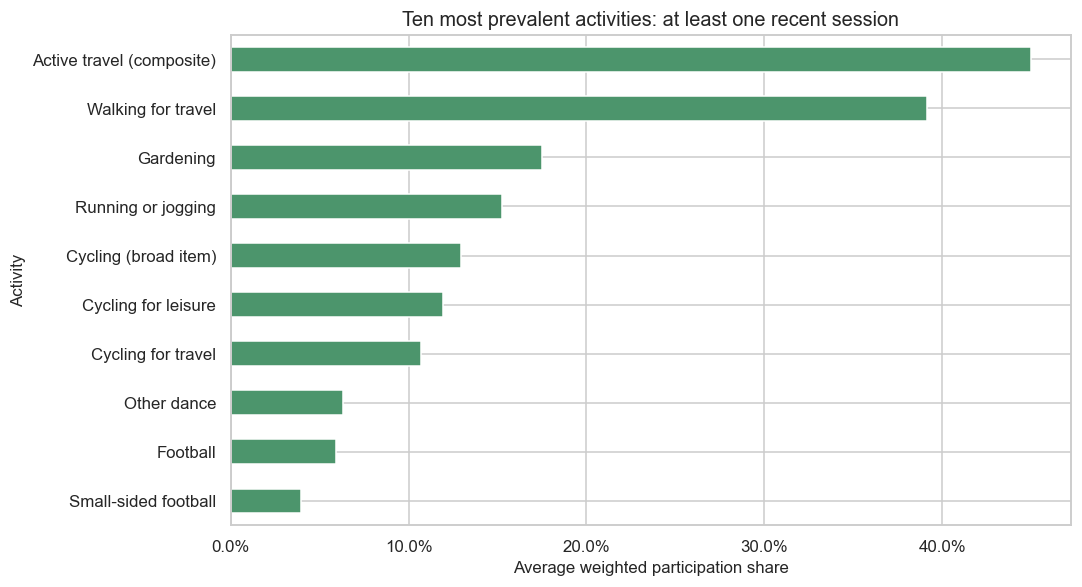

,average_percent
Small-sided football,3.941733
Football,5.915903
Other dance,6.344941
Cycling for travel,10.692553
Cycling for leisure,11.927517
Cycling (broad item),12.933007
Running or jogging,15.264698
Gardening,17.483264
Walking for travel,39.155530
Active travel (composite),44.997503


In [11]:
days_any_columns = [column for column in activity_columns if column.startswith('DAYS_ANY_RATE_')]
top_activity_columns = london_monthly[days_any_columns].mean().nlargest(10).index
READABLE_ACTIVITY_LABELS = {
    'ACTTRAV_C03': 'Active travel (composite)',
    'WALKTRAV_B02': 'Walking for travel',
    'GARD_B08': 'Gardening',
    'RUNJOG_U07': 'Running or jogging',
    'CYC_OLD_M02': 'Cycling (broad item)',
    'CYCLEISURE_N01': 'Cycling for leisure',
    'CYCTRAV_B04': 'Cycling for travel',
    'DANCEOTHER_O01': 'Other dance',
    'FOOTBALL_F01': 'Football',
    'FOOTBALLSMALL_Q02': 'Small-sided football',
}
top_activities = (
    london_monthly[top_activity_columns]
    .mean()
    .mul(100)
    .rename(
        lambda column: READABLE_ACTIVITY_LABELS.get(
            column.removeprefix('DAYS_ANY_RATE_'),
            column.removeprefix('DAYS_ANY_RATE_').replace('_', ' ').title(),
        )
    )
    .sort_values()
)
fig, ax = plt.subplots(figsize=(10, 5.5))
top_activities.plot(kind='barh', color='#4c956c', ax=ax)
ax.set(
    title='Ten most prevalent activities: at least one recent session',
    xlabel='Average weighted participation share',
    ylabel='Activity',
)
ax.xaxis.set_major_formatter(PercentFormatter(100))
plt.tight_layout()
plt.show()
display(top_activities.rename('average_percent').to_frame())


### Findings

- Median borough-month Kish `effective_n` is **25.18**; **25.9%** of observed months are below 20
  and **69.4%** below 30.
- The worst-case approximate 95% margin of error at the median is about **±19.5 percentage points**.
- Month-to-month TV volatility declines as effective sample size rises.
- The pre-declared decision is therefore **Exploratory**. Monthly borough forecasts remain useful
  as a backtest, not as precise operational estimates.
- Walking/active-travel items are the most common displayed activities, but overlapping items mean
  these percentages must not be added together.


## 6. Weather and COVID timing

Observed daily weather is aligned to each survey month. Exact restriction periods are shaded.
Weather is useful for temporal description and lagged forecast testing, but it is excluded from
borough clustering because every borough receives the same London-wide monthly value.


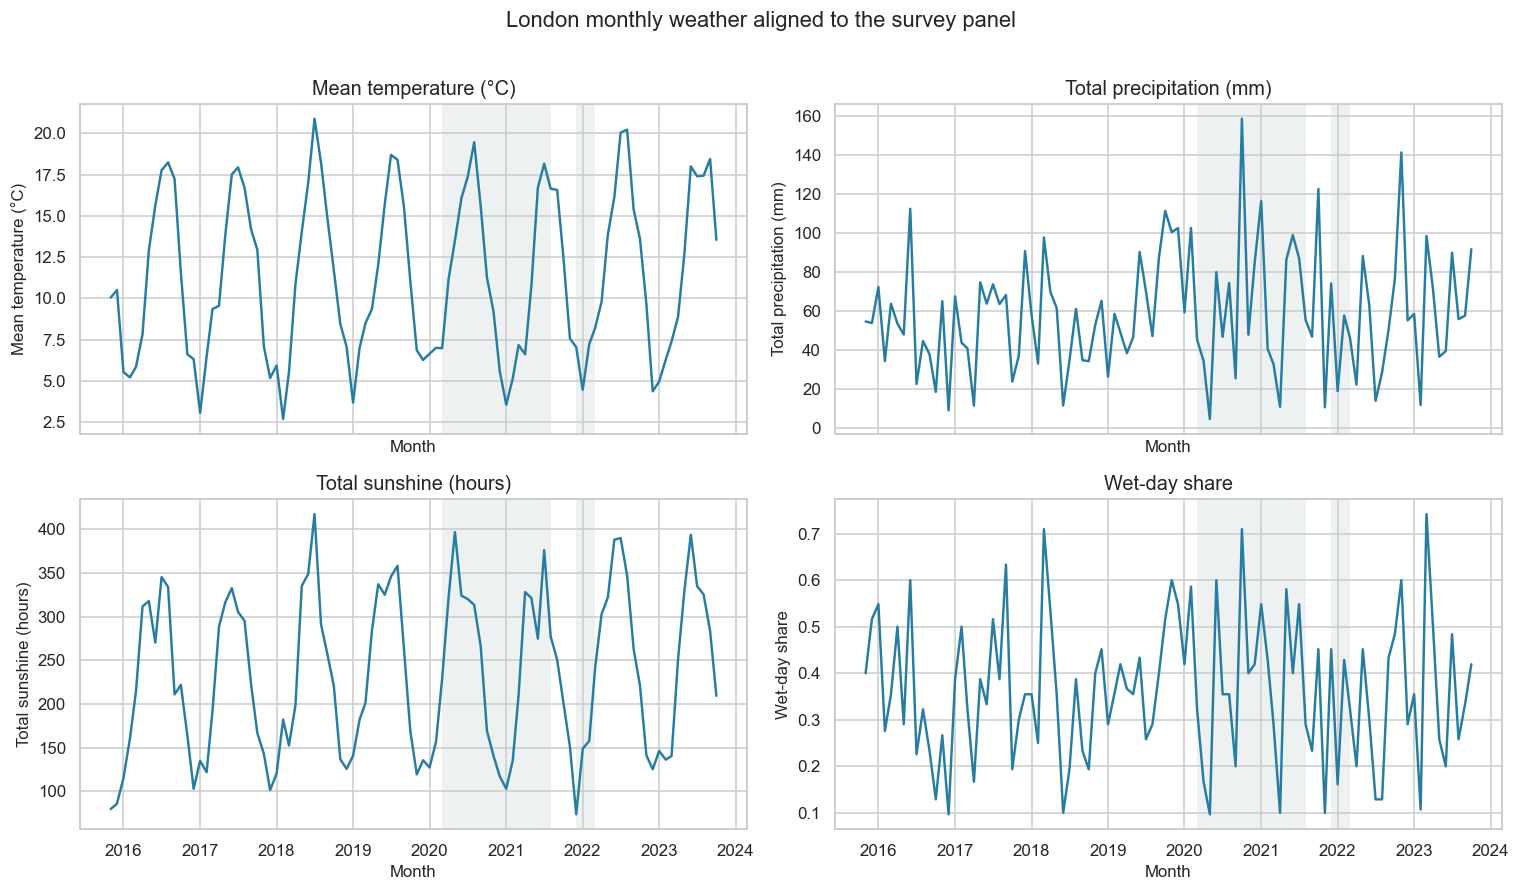

,weather variable,correlation with season-adjusted active-share anomaly
1,weather_total_precipitation_mm,-0.093
3,weather_mean_max_wind_kmh,-0.067
4,weather_wet_day_rate,-0.063
2,weather_total_sunshine_hours,0.057
0,weather_mean_temperature_c,0.088


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
weather_plot_specs = [
    ('weather_mean_temperature_c', 'Mean temperature (°C)'),
    ('weather_total_precipitation_mm', 'Total precipitation (mm)'),
    ('weather_total_sunshine_hours', 'Total sunshine (hours)'),
    ('weather_wet_day_rate', 'Wet-day share'),
]
for ax, (variable, ylabel) in zip(axes.flat, weather_plot_specs):
    ax.plot(
        london_monthly['period_start'], london_monthly[variable], color='#277da1', linewidth=1.6
    )
    shade_covid_periods(ax, show_labels=False)
    ax.set(title=ylabel, xlabel='Month', ylabel=ylabel)
plt.suptitle('London monthly weather aligned to the survey panel', y=1.01)
plt.tight_layout()
plt.show()

# Remove recurring calendar-month means before a simple descriptive association check.
weather_association = london_monthly[
    ['month_of_wave', 'active_rate'] + WEATHER_CONTEXT_FEATURES
].copy()
for variable in ['active_rate'] + WEATHER_CONTEXT_FEATURES:
    weather_association[f'{variable}_anomaly'] = weather_association[
        variable
    ] - weather_association.groupby('month_of_wave')[variable].transform('mean')
weather_correlations = pd.DataFrame(
    {
        'weather variable': WEATHER_CONTEXT_FEATURES,
        'correlation with season-adjusted active-share anomaly': [
            weather_association['active_rate_anomaly'].corr(
                weather_association[f'{variable}_anomaly']
            )
            for variable in WEATHER_CONTEXT_FEATURES
        ],
    }
).sort_values('correlation with season-adjusted active-share anomaly')
display(
    weather_correlations.style.format(
        {'correlation with season-adjusted active-share anomaly': '{:.3f}'}
    )
)
weather_correlations.to_csv(
    OUTPUT_DIR / 'monthly_weather_activity_descriptive_correlations.csv',
    index=False,
    encoding='utf-8-sig',
)


### Findings

Season-adjusted correlations between monthly active-share anomalies and individual weather
variables are weak: all absolute correlations are below **0.10**. COVID periods visibly overlap
unusual months, but the chart alone cannot separate restrictions, sampling noise, seasonality and
other simultaneous changes.


## 7. Leakage-safe monthly forecast design

The task is a fixed-origin 12-month borough forecast. All survey and external predictors are
lagged exactly 12 months within borough; calendar/trend and pre-defined COVID indicators are the
only contemporaneously known inputs. Months 13–48 form base training, three successive 12-month
blocks form rolling validation, and months 85–96 remain untouched until final evaluation.


In [12]:
panel = (
    borough_monthly.sort_values(['geography_code', 'month_index']).reset_index(drop=True).copy()
)
survey_source_lag_columns = TARGETS + COMPOSITION_FEATURES + activity_columns
external_source_lag_columns = FORECAST_CONTEXT_FEATURES
source_lag_columns = survey_source_lag_columns + external_source_lag_columns
grouped = panel.groupby('geography_code', sort=False)

engineered = {
    'trend': panel['month_index'].astype(float),
    'month_sin': np.sin(2 * np.pi * (panel['month_of_wave'] - 1) / 12),
    'month_cos': np.cos(2 * np.pi * (panel['month_of_wave'] - 1) / 12),
    'covid_restriction_flag': covid_restriction_flag(panel['period_start']),
    'covid_lag12_source_flag': covid_restriction_flag(
        panel['period_start'] - pd.DateOffset(years=1)
    ),
}
for column in source_lag_columns:
    engineered[f'{column}_lag12'] = grouped[column].shift(12)

engineered_frame = pd.DataFrame(engineered, index=panel.index)
model_panel = pd.concat([panel, engineered_frame], axis=1)


### Compact-feature sensitivity

For stability comparison, the 372 activity rates are averaged within 17 source-code families and three measurement windows, producing 51 indices. The primary fields remain unchanged.


In [13]:
# Compact, auditable alternative: average the 124 activity rates within each of the
# 17 source-code families, separately for the three measurement windows. These are
# indices, not participation proportions. The original 372 fields remain untouched.
compact_activity_groups = {}
for source_column in activity_columns:
    measure = next(
        prefix.removesuffix('_RATE_')
        for prefix in ACTIVITY_PREFIXES
        if source_column.startswith(prefix)
    )
    code_family = source_column.rsplit('_', 1)[-1][0]
    compact_name = f'COMPACT_{measure}_{code_family}_MEAN_lag12'
    compact_activity_groups.setdefault(compact_name, []).append(f'{source_column}_lag12')
compact_activity_frame = pd.DataFrame(
    {
        compact_name: model_panel[source_columns].mean(axis=1, skipna=True)
        for compact_name, source_columns in compact_activity_groups.items()
    },
    index=model_panel.index,
)
model_panel = pd.concat([model_panel, compact_activity_frame], axis=1)
compact_activity_features = sorted(compact_activity_groups)
compact_activity_map = pd.DataFrame(
    [
        {
            'compact_feature': compact_name,
            'source_activity_fields': len(source_columns),
            'source_columns': ' | '.join(source_columns),
        }
        for compact_name, source_columns in sorted(compact_activity_groups.items())
    ]
)
assert len(compact_activity_features) == 51
compact_activity_map.to_csv(
    OUTPUT_DIR / 'monthly_forecast_compact_activity_feature_map.csv',
    index=False,
    encoding='utf-8-sig',
)


### Supervised modelling panel

Only lagged predictors, calendar features and borough identity enter the candidate models.


In [14]:
survey_lagged_features = [f'{column}_lag12' for column in survey_source_lag_columns]
external_lagged_features = [f'{column}_lag12' for column in external_source_lag_columns]
lagged_source_features = survey_lagged_features + external_lagged_features
model_panel['lag_missing_fraction'] = model_panel[lagged_source_features].isna().mean(axis=1)

calendar_numeric_features = [
    'trend',
    'month_sin',
    'month_cos',
    'covid_restriction_flag',
    'covid_lag12_source_flag',
]
base_numeric_features = calendar_numeric_features + survey_lagged_features
extended_numeric_features = base_numeric_features + external_lagged_features
non_activity_lagged_features = [f'{column}_lag12' for column in TARGETS + COMPOSITION_FEATURES]
compact_numeric_features = (
    calendar_numeric_features + non_activity_lagged_features + compact_activity_features
)
numeric_features = base_numeric_features.copy()
categorical_features = ['geography_name']
model_features = numeric_features + categorical_features

supervised = model_panel.loc[
    model_panel['month_index'].ge(13)
    & model_panel[TARGETS].notna().all(axis=1)
    & model_panel['lag_missing_fraction'].lt(0.95)
].copy()

development = supervised.loc[supervised['month_index'].lt(TEST_START_MONTH)].copy()
holdout = supervised.loc[
    supervised['month_index'].between(TEST_START_MONTH, TEST_END_MONTH)
].copy()

assert development['month_index'].max() == 84
assert holdout['month_index'].min() == 85 and holdout['month_index'].max() == 96
assert len(holdout) == 12 * 32
assert not any(column in model_features for column in source_lag_columns)
assert all(column.endswith('_lag12') for column in lagged_source_features)
assert holdout['covid_restriction_flag'].eq(0).all()
assert development['covid_restriction_flag'].eq(1).any()
assert int(holdout['covid_lag12_source_flag'].sum()) == 3 * 32


### Chronological folds

Each validation block is a full year and each later fold expands the available history.


In [15]:
CV_BLOCKS = [
    {'fold': 1, 'train_end': 48, 'valid_start': 49, 'valid_end': 60},
    {'fold': 2, 'train_end': 60, 'valid_start': 61, 'valid_end': 72},
    {'fold': 3, 'train_end': 72, 'valid_start': 73, 'valid_end': 84},
]
split_summary = []
for block in CV_BLOCKS:
    train_rows = supervised['month_index'].le(block['train_end'])
    valid_rows = supervised['month_index'].between(block['valid_start'], block['valid_end'])
    split_summary.append(
        {
            **block,
            'training rows': int(train_rows.sum()),
            'validation rows': int(valid_rows.sum()),
        }
    )
split_summary.append(
    {
        'fold': 'final test',
        'train_end': 84,
        'valid_start': 85,
        'valid_end': 96,
        'training rows': len(development),
        'validation rows': len(holdout),
    }
)
display(pd.DataFrame(split_summary))


,fold,train_end,valid_start,valid_end,training rows,validation rows
0,1,48,49,60,1152,383
1,2,60,61,72,1535,383
2,3,72,73,84,1918,384
3,final test,84,85,96,2302,384


,stage,target months,calendar,role
0,Lag warm-up (inputs only),1–12,2015-11 to 2016-10,No supervised target
1,Base training,13–48,2016-11 to 2019-10,Initial model fitting
2,Rolling validation,49–84,2019-11 to 2022-10,Three 12-month folds for selection
3,Independent test,85–96,2022-11 to 2023-10,Opened once after selection


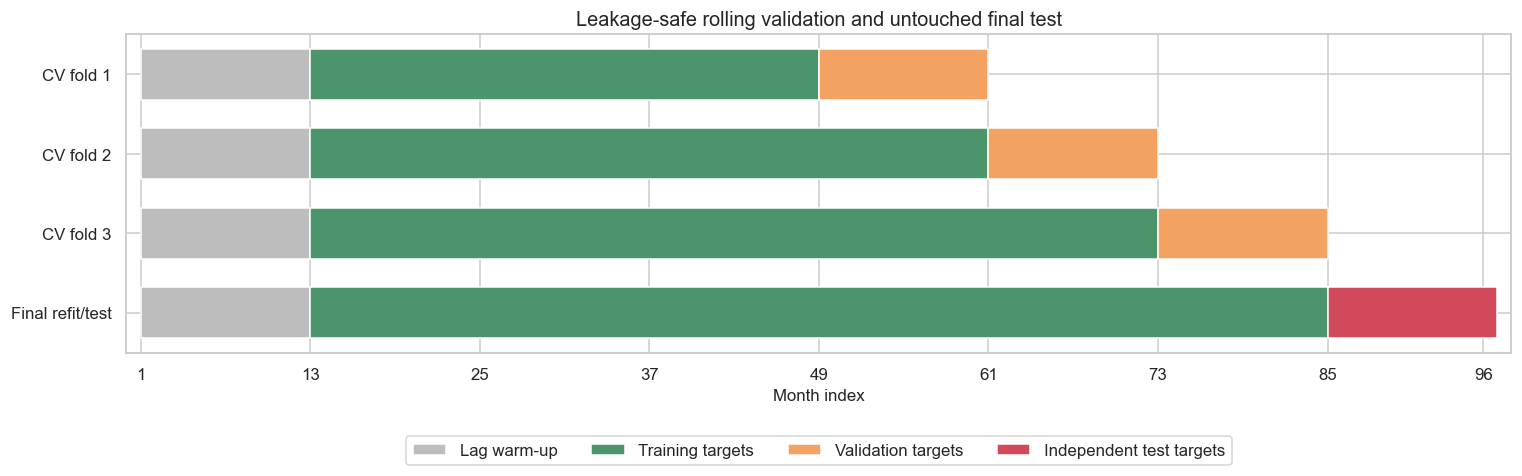

In [16]:
split_definition = pd.DataFrame(
    [
        {
            'stage': 'Lag warm-up (inputs only)',
            'target months': '1–12',
            'calendar': '2015-11 to 2016-10',
            'role': 'No supervised target',
        },
        {
            'stage': 'Base training',
            'target months': '13–48',
            'calendar': '2016-11 to 2019-10',
            'role': 'Initial model fitting',
        },
        {
            'stage': 'Rolling validation',
            'target months': '49–84',
            'calendar': '2019-11 to 2022-10',
            'role': 'Three 12-month folds for selection',
        },
        {
            'stage': 'Independent test',
            'target months': '85–96',
            'calendar': '2022-11 to 2023-10',
            'role': 'Opened once after selection',
        },
    ]
)
display(split_definition)
split_definition.to_csv(
    OUTPUT_DIR / 'monthly_forecast_split_definition.csv', index=False, encoding='utf-8-sig'
)

timeline_rows = [
    ('CV fold 1', 48, 49, 60),
    ('CV fold 2', 60, 61, 72),
    ('CV fold 3', 72, 73, 84),
    ('Final refit/test', 84, 85, 96),
]
fig, ax = plt.subplots(figsize=(14, 4.8))
for y, (label, train_end, eval_start, eval_end) in enumerate(timeline_rows):
    ax.broken_barh([(1, 12)], (y - 0.32, 0.64), facecolors='#bdbdbd')
    ax.broken_barh([(13, train_end - 12)], (y - 0.32, 0.64), facecolors='#4c956c')
    eval_color = '#f4a261' if label.startswith('CV') else '#d1495b'
    ax.broken_barh(
        [(eval_start, eval_end - eval_start + 1)], (y - 0.32, 0.64), facecolors=eval_color
    )
ax.set_yticks(range(len(timeline_rows)), [row[0] for row in timeline_rows])
ax.set_xticks([1, 13, 25, 37, 49, 61, 73, 85, 96])
ax.set(
    xlim=(0, 98),
    xlabel='Month index',
    title='Leakage-safe rolling validation and untouched final test',
)
ax.invert_yaxis()
from matplotlib.patches import Patch

ax.legend(
    handles=[
        Patch(facecolor='#bdbdbd', label='Lag warm-up'),
        Patch(facecolor='#4c956c', label='Training targets'),
        Patch(facecolor='#f4a261', label='Validation targets'),
        Patch(facecolor='#d1495b', label='Independent test targets'),
    ],
    ncol=4,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.38),
)
plt.tight_layout()
plt.show()


### Design audit

The development panel has **2,302 rows** and the untouched test has **384**. Candidate inputs are
383 survey-only, 393 context-extended or 62 compact numeric fields plus borough identity. No test
target month is inside a defined restriction period, although 96 test rows use lag-12 inputs from
the Omicron/Plan B period.


## 8. Models, coherent shares and common metrics

Seasonal Naive, Ridge, Random Forest and Gradient Boosting are compared on the same data. The
three shares are mapped to two additive log-ratio coordinates for fitting and transformed back to
non-negative predictions that sum to one. Kish `effective_n` is clipped and normalised as a
reliability weight. Weighted total-variation error is the primary model-selection metric; MAE,
RMSE and target-specific R² remain visible.


In [17]:
def shares_to_alr(shares, epsilon=ALR_EPSILON):
    values = np.asarray(shares, dtype=float)
    values = np.clip(values, epsilon, None)
    values = values / values.sum(axis=1, keepdims=True)
    return np.column_stack(
        [
            np.log(values[:, 0] / values[:, 2]),
            np.log(values[:, 1] / values[:, 2]),
        ]
    )


def alr_to_shares(coordinates):
    coordinates = np.asarray(coordinates, dtype=float)
    logits = np.column_stack([coordinates[:, 0], coordinates[:, 1], np.zeros(len(coordinates))])
    logits = logits - logits.max(axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / exp_logits.sum(axis=1, keepdims=True)


def normalised_fit_weights(weights):
    values = np.asarray(weights, dtype=float)
    low, high = np.quantile(values, [0.05, 0.95])
    values = np.clip(values, low, high)
    return values / values.mean()


def composition_metrics(actual, predicted, weights):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    weights = np.asarray(weights, dtype=float)
    absolute = np.abs(actual - predicted)
    squared = np.square(actual - predicted)
    row_tv = 0.5 * absolute.sum(axis=1)
    result = {
        'weighted_tv': float(np.average(row_tv, weights=weights)),
        'unweighted_tv': float(row_tv.mean()),
    }
    for index, target in enumerate(TARGETS):
        result[f'{target}_mae'] = float(np.average(absolute[:, index], weights=weights))
        result[f'{target}_rmse'] = float(np.sqrt(np.average(squared[:, index], weights=weights)))
        result[f'{target}_r2'] = float(
            r2_score(actual[:, index], predicted[:, index], sample_weight=weights)
        )
    return result


### Preprocessing and estimator factories

Scaling is used only where required; imputation and near-zero-variance filtering are fitted inside each training fold.


In [18]:
def make_preprocessor(scale_numeric, selected_numeric_features=None):
    selected_numeric_features = (
        numeric_features if selected_numeric_features is None else selected_numeric_features
    )
    numeric_steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('variance', VarianceThreshold(threshold=1e-10)),
    ]
    if scale_numeric:
        numeric_steps.append(('scaler', StandardScaler()))
    return ColumnTransformer(
        [
            ('numeric', Pipeline(numeric_steps), selected_numeric_features),
            (
                'borough',
                OneHotEncoder(handle_unknown='ignore', sparse_output=False),
                categorical_features,
            ),
        ]
    )


def make_ridge(alpha, selected_numeric_features=None):
    return Pipeline(
        [
            (
                'preprocessor',
                make_preprocessor(
                    scale_numeric=True, selected_numeric_features=selected_numeric_features
                ),
            ),
            ('model', Ridge(alpha=alpha)),
        ]
    )


def make_random_forest(
    selected_numeric_features=None,
    n_estimators=300,
    max_features=0.40,
    min_samples_leaf=5,
    max_depth=None,
):
    return Pipeline(
        [
            (
                'preprocessor',
                make_preprocessor(
                    scale_numeric=False, selected_numeric_features=selected_numeric_features
                ),
            ),
            (
                'model',
                RandomForestRegressor(
                    n_estimators=n_estimators,
                    min_samples_leaf=min_samples_leaf,
                    max_features=max_features,
                    max_depth=max_depth,
                    oob_score=True,
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


def make_gradient_boosting(
    selected_numeric_features=None,
    n_estimators=140,
    learning_rate=0.03,
    max_depth=2,
    min_samples_leaf=10,
    loss='huber',
):
    base = GradientBoostingRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        loss=loss,
        random_state=RANDOM_STATE,
    )
    return Pipeline(
        [
            (
                'preprocessor',
                make_preprocessor(
                    scale_numeric=False, selected_numeric_features=selected_numeric_features
                ),
            ),
            ('model', MultiOutputRegressor(base, n_jobs=-1)),
        ]
    )


### Baseline and shared rolling-validation runner

One runner guarantees identical folds, weights and scoring across algorithms.


In [19]:
def seasonal_naive(frame):
    prediction = frame[[f'{target}_lag12' for target in TARGETS]].to_numpy(float)
    assert np.isfinite(prediction).all()
    return prediction / prediction.sum(axis=1, keepdims=True)


def run_temporal_cv(model_name, estimator=None, selected_numeric_features=None):
    selected_numeric_features = (
        numeric_features if selected_numeric_features is None else list(selected_numeric_features)
    )
    selected_model_features = selected_numeric_features + categorical_features
    fold_metrics = []
    prediction_parts = []
    for block in CV_BLOCKS:
        train = supervised.loc[supervised['month_index'].le(block['train_end'])]
        valid = supervised.loc[
            supervised['month_index'].between(block['valid_start'], block['valid_end'])
        ]
        actual = valid[TARGETS].to_numpy(float)

        if estimator is None:
            predicted = seasonal_naive(valid)
        else:
            fitted = clone(estimator)
            fitted.fit(
                train[selected_model_features],
                shares_to_alr(train[TARGETS]),
                model__sample_weight=normalised_fit_weights(train['effective_n']),
            )
            predicted = alr_to_shares(fitted.predict(valid[selected_model_features]))

        metrics = composition_metrics(actual, predicted, valid['effective_n'])
        fold_metrics.append({'model': model_name, 'fold': block['fold'], **metrics})

        part = valid[
            ['month_index', 'period_start', 'geography_code', 'geography_name', 'effective_n']
        ].copy()
        part['fold'] = block['fold']
        for index, target in enumerate(TARGETS):
            part[f'actual_{target}'] = actual[:, index]
            part[f'predicted_{target}'] = predicted[:, index]
        prediction_parts.append(part)
    return pd.DataFrame(fold_metrics), pd.concat(prediction_parts, ignore_index=True)


## 9. Expanding-window cross-validation, parameter tuning and model selection

All parameter decisions are made before the independent test year is opened. Each candidate is assessed on the same three expanding-window, 12-month validation blocks using Kish-effective-sample-size-weighted total-variation error. The grids are deliberately bounded and specified in advance: they cover materially different regularisation, tree-depth, leaf-size, feature-subsampling and learning-rate regimes without turning the small borough-month panel into an unrestricted search exercise.

Within each model and feature configuration, the notebook applies a **one-standard-error rule**: among candidates statistically close to the minimum mean CV error, it chooses the pre-ranked simpler candidate. The full candidate audit, fold variation, one-SE threshold and selection flag are exported. The external-variable ablation, compact-versus-372 comparison and final algorithm choice then use only these development-period results; the test year is used once for final assessment.


In [20]:
# Every method receives its own development-only tuning and external-context
# ablation. Compact activity indices are a separate stability benchmark. Neither
# parameter selection nor feature selection can use the independent test year.
CONTEXT_MIN_CV_GAIN = 0.001
FULL_SURVEY = 'Full 372 activity fields — survey only'
FULL_EXTERNAL = 'Full 372 activity fields — survey + external'
COMPACT_SURVEY = 'Compact 51 activity-family indices — survey only'
configuration_rows = []
configuration_results = {}
hyperparameter_rows = []


def monthly_candidate_specs(model_name, selected_numeric_features):
    if model_name == 'Ridge':
        # Higher alpha is ranked as simpler because it shrinks the high-dimensional
        # activity block more strongly.
        alphas = [10000.0, 1000.0, 100.0, 10.0, 1.0, 0.1]
        return [
            {
                'label': f'alpha={alpha:g}',
                'params': {'alpha': alpha},
                'simplicity_rank': rank,
                'estimator': make_ridge(alpha, selected_numeric_features),
            }
            for rank, alpha in enumerate(alphas)
        ]
    if model_name == 'Random Forest':
        # Ordered from strongest to weakest capacity control.
        grid = [
            {'n_estimators': 300, 'max_features': 0.20, 'min_samples_leaf': 15, 'max_depth': 8},
            {'n_estimators': 300, 'max_features': 0.35, 'min_samples_leaf': 12, 'max_depth': 10},
            {'n_estimators': 300, 'max_features': 0.50, 'min_samples_leaf': 8, 'max_depth': 12},
            {'n_estimators': 300, 'max_features': 0.40, 'min_samples_leaf': 5, 'max_depth': 16},
            {'n_estimators': 300, 'max_features': 0.65, 'min_samples_leaf': 5, 'max_depth': None},
        ]
        return [
            {
                'label': (
                    f'mtry={params["max_features"]:.2f}, leaf={params["min_samples_leaf"]}, '
                    f'depth={params["max_depth"]}'
                ),
                'params': params,
                'simplicity_rank': rank,
                'estimator': make_random_forest(selected_numeric_features, **params),
            }
            for rank, params in enumerate(grid)
        ]
    if model_name == 'Gradient Boosting':
        # The grid changes tree interaction depth, leaf regularisation and the
        # learning-rate/tree-count trade-off. Huber loss is fixed for robustness.
        grid = [
            {
                'n_estimators': 100,
                'learning_rate': 0.03,
                'max_depth': 1,
                'min_samples_leaf': 20,
                'loss': 'huber',
            },
            {
                'n_estimators': 140,
                'learning_rate': 0.03,
                'max_depth': 1,
                'min_samples_leaf': 10,
                'loss': 'huber',
            },
            {
                'n_estimators': 100,
                'learning_rate': 0.05,
                'max_depth': 1,
                'min_samples_leaf': 10,
                'loss': 'huber',
            },
            {
                'n_estimators': 140,
                'learning_rate': 0.03,
                'max_depth': 2,
                'min_samples_leaf': 20,
                'loss': 'huber',
            },
            {
                'n_estimators': 140,
                'learning_rate': 0.03,
                'max_depth': 2,
                'min_samples_leaf': 10,
                'loss': 'huber',
            },
            {
                'n_estimators': 220,
                'learning_rate': 0.02,
                'max_depth': 2,
                'min_samples_leaf': 10,
                'loss': 'huber',
            },
            {
                'n_estimators': 140,
                'learning_rate': 0.03,
                'max_depth': 3,
                'min_samples_leaf': 20,
                'loss': 'huber',
            },
        ]
        return [
            {
                'label': (
                    f'n={params["n_estimators"]}, lr={params["learning_rate"]:.2f}, '
                    f'depth={params["max_depth"]}, leaf={params["min_samples_leaf"]}'
                ),
                'params': params,
                'simplicity_rank': rank,
                'estimator': make_gradient_boosting(selected_numeric_features, **params),
            }
            for rank, params in enumerate(grid)
        ]
    raise ValueError(model_name)


### Evaluate one model/feature configuration

Every candidate is scored on identical rolling folds; the one-standard-error rule selects the simplest statistically comparable setting.


In [21]:
def evaluate_monthly_configuration(model_name, configuration_name, selected_numeric_features):
    candidate_results = []
    for candidate in monthly_candidate_specs(model_name, selected_numeric_features):
        fold_metrics, predictions = run_temporal_cv(
            model_name, candidate['estimator'], selected_numeric_features
        )
        mean_error = fold_metrics['weighted_tv'].mean()
        sd_error = fold_metrics['weighted_tv'].std(ddof=1)
        candidate_results.append(
            {
                **candidate,
                'fold_metrics': fold_metrics,
                'predictions': predictions,
                'mean_error': mean_error,
                'sd_error': sd_error,
                'standard_error': sd_error / np.sqrt(len(CV_BLOCKS)),
            }
        )

    empirical_best = min(candidate_results, key=lambda item: item['mean_error'])
    one_se_limit = empirical_best['mean_error'] + empirical_best['standard_error']
    eligible = [item for item in candidate_results if item['mean_error'] <= one_se_limit]
    selected = min(eligible, key=lambda item: (item['simplicity_rank'], item['mean_error']))

    for item in candidate_results:
        row = {
            'model': model_name,
            'feature configuration': configuration_name,
            'numeric features': len(selected_numeric_features),
            'candidate': item['label'],
            'simplicity rank': item['simplicity_rank'],
            'mean CV weighted TV': item['mean_error'],
            'sd CV weighted TV': item['sd_error'],
            'standard error': item['standard_error'],
            'one SE limit': one_se_limit,
            'within one SE': item['mean_error'] <= one_se_limit,
            'selected by one SE': item is selected,
        }
        row.update(item['params'])
        hyperparameter_rows.append(row)

    configuration_rows.append(
        {
            'model': model_name,
            'feature configuration': configuration_name,
            'numeric features': len(selected_numeric_features),
            'tuned configuration': selected['label'],
            'mean CV weighted TV': selected['mean_error'],
            'sd CV weighted TV': selected['sd_error'],
            'standard error': selected['standard_error'],
            'empirical minimum CV weighted TV': empirical_best['mean_error'],
            'one SE limit': one_se_limit,
            'one SE excess over empirical minimum': selected['mean_error']
            - empirical_best['mean_error'],
        }
    )
    configuration_results[(model_name, configuration_name)] = {
        'numeric_features': list(selected_numeric_features),
        'estimator': selected['estimator'],
        'fold_metrics': selected['fold_metrics'].assign(model=model_name),
        'predictions': selected['predictions'],
        'params': selected['params'],
        'tuning_label': selected['label'],
    }


### Execute the development-only search

Each model is tuned independently for full survey-only, full plus external, and compact survey-only inputs.


In [22]:
for candidate_model in ['Ridge', 'Random Forest', 'Gradient Boosting']:
    evaluate_monthly_configuration(candidate_model, FULL_SURVEY, base_numeric_features)
    evaluate_monthly_configuration(candidate_model, FULL_EXTERNAL, extended_numeric_features)
    evaluate_monthly_configuration(candidate_model, COMPACT_SURVEY, compact_numeric_features)


### Feature-configuration decisions

External context is retained separately by model, while the compact activity representation remains a sensitivity benchmark.


In [23]:
configuration_comparison = pd.DataFrame(configuration_rows)
hyperparameter_cv = pd.DataFrame(hyperparameter_rows).sort_values(
    ['model', 'feature configuration', 'simplicity rank']
)
external_ablation_rows = []
compact_ablation_rows = []
selected_configuration_by_model = {}
selected_numeric_features_by_model = {}
selected_estimators_by_model = {}
selected_external_by_model = {}

for candidate_model in ['Ridge', 'Random Forest', 'Gradient Boosting']:
    rows = configuration_comparison.loc[configuration_comparison['model'].eq(candidate_model)]
    full_survey = rows.loc[rows['feature configuration'].eq(FULL_SURVEY)].iloc[0]
    full_external = rows.loc[rows['feature configuration'].eq(FULL_EXTERNAL)].iloc[0]
    compact = rows.loc[rows['feature configuration'].eq(COMPACT_SURVEY)].iloc[0]
    external_gain = full_survey['mean CV weighted TV'] - full_external['mean CV weighted TV']
    retain_external = bool(external_gain >= CONTEXT_MIN_CV_GAIN)
    selected_name = FULL_EXTERNAL if retain_external else FULL_SURVEY
    selected_configuration_by_model[candidate_model] = selected_name
    selected_external_by_model[candidate_model] = retain_external
    selected_result = configuration_results[(candidate_model, selected_name)]
    selected_numeric_features_by_model[candidate_model] = selected_result['numeric_features']
    selected_estimators_by_model[candidate_model] = selected_result['estimator']
    external_ablation_rows.append(
        {
            'model': candidate_model,
            'survey_only_mean_cv_weighted_tv': full_survey['mean CV weighted TV'],
            'survey_plus_external_mean_cv_weighted_tv': full_external['mean CV weighted TV'],
            'external_cv_gain': external_gain,
            'minimum_required_gain': CONTEXT_MIN_CV_GAIN,
            'external_context_retained': retain_external,
            'selected_feature_configuration': selected_name,
        }
    )
    compact_ablation_rows.append(
        {
            'model': candidate_model,
            'full_selected_mean_cv_weighted_tv': rows.loc[
                rows['feature configuration'].eq(selected_name), 'mean CV weighted TV'
            ].iloc[0],
            'compact_mean_cv_weighted_tv': compact['mean CV weighted TV'],
            'compact_minus_full_weighted_tv': (
                compact['mean CV weighted TV']
                - rows.loc[
                    rows['feature configuration'].eq(selected_name), 'mean CV weighted TV'
                ].iloc[0]
            ),
            'full_activity_fields': 372,
            'compact_activity_indices': 51,
            'compact_is_sensitivity_only': True,
        }
    )


### Export the full tuning audit

Candidate-level scores, selected parameters, feature ablations and compactness comparisons are saved before final model selection.


In [24]:
external_feature_ablation = pd.DataFrame(external_ablation_rows)
compact_feature_ablation = pd.DataFrame(compact_ablation_rows)
selected_hyperparameter_rows = []
for candidate_model in ['Ridge', 'Random Forest', 'Gradient Boosting']:
    selected_name = selected_configuration_by_model[candidate_model]
    selected_result = configuration_results[(candidate_model, selected_name)]
    row = {
        'model': candidate_model,
        'feature_configuration': selected_name,
        'selection_rule': 'three expanding-window folds; weighted TV; one-standard-error parsimony rule',
    }
    row.update(selected_result['params'])
    selected_hyperparameter_rows.append(row)
selected_hyperparameters = pd.DataFrame(selected_hyperparameter_rows)

configuration_comparison.to_csv(
    OUTPUT_DIR / 'monthly_forecast_feature_configuration_cv.csv', index=False, encoding='utf-8-sig'
)
hyperparameter_cv.to_csv(
    OUTPUT_DIR / 'monthly_forecast_hyperparameter_cv.csv', index=False, encoding='utf-8-sig'
)
selected_hyperparameters.to_csv(
    OUTPUT_DIR / 'monthly_forecast_selected_hyperparameters.csv', index=False, encoding='utf-8-sig'
)
external_feature_ablation.to_csv(
    OUTPUT_DIR / 'monthly_forecast_external_feature_ablation.csv',
    index=False,
    encoding='utf-8-sig',
)
compact_feature_ablation.to_csv(
    OUTPUT_DIR / 'monthly_forecast_activity_compactness_ablation.csv',
    index=False,
    encoding='utf-8-sig',
)
display(selected_hyperparameters)
display(
    external_feature_ablation.style.format(
        {
            'survey_only_mean_cv_weighted_tv': '{:.4f}',
            'survey_plus_external_mean_cv_weighted_tv': '{:.4f}',
            'external_cv_gain': '{:.4f}',
            'minimum_required_gain': '{:.4f}',
        }
    )
)
display(
    compact_feature_ablation.style.format(
        {
            'full_selected_mean_cv_weighted_tv': '{:.4f}',
            'compact_mean_cv_weighted_tv': '{:.4f}',
            'compact_minus_full_weighted_tv': '{:+.4f}',
        }
    )
)


,model,feature_configuration,selection_rule,alpha,n_estimators,max_features,min_samples_leaf,max_depth,learning_rate,loss
0,Ridge,Full 372 activity fields — survey only,three expanding-window folds; weighted TV; one...,10000.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Random Forest,Full 372 activity fields — survey + external,three expanding-window folds; weighted TV; one...,NaN,300.0,0.2,15.0,8.0,NaN,NaN
2,Gradient Boosting,Full 372 activity fields — survey + external,three expanding-window folds; weighted TV; one...,NaN,100.0,NaN,20.0,1.0,0.03,huber


,model,survey_only_mean_cv_weighted_tv,survey_plus_external_mean_cv_weighted_tv,external_cv_gain,minimum_required_gain,external_context_retained,selected_feature_configuration
0,Ridge,0.1056,0.1047,0.0009,0.0010,False,Full 372 activity fields — survey only
1,Random Forest,0.1077,0.1049,0.0028,0.0010,True,Full 372 activity fields — survey + external
2,Gradient Boosting,0.1049,0.1023,0.0026,0.0010,True,Full 372 activity fields — survey + external


,model,full_selected_mean_cv_weighted_tv,compact_mean_cv_weighted_tv,compact_minus_full_weighted_tv,full_activity_fields,compact_activity_indices,compact_is_sensitivity_only
0,Ridge,0.1056,0.1060,+0.0004,372,51,True
1,Random Forest,0.1049,0.1081,+0.0031,372,51,True
2,Gradient Boosting,0.1023,0.1052,+0.0028,372,51,True


### Select the final monthly algorithm

Selected feature configurations are compared with Seasonal Naive. A second one-standard-error rule gives priority to the simpler algorithm when development errors are statistically indistinguishable.


In [25]:
cv_fold_results = {}
cv_predictions = {}
naive_metrics, naive_predictions = run_temporal_cv('Seasonal naive')
cv_fold_results['Seasonal naive'] = naive_metrics
cv_predictions['Seasonal naive'] = naive_predictions
for candidate_model in ['Ridge', 'Random Forest', 'Gradient Boosting']:
    result = configuration_results[
        (candidate_model, selected_configuration_by_model[candidate_model])
    ]
    cv_fold_results[candidate_model] = result['fold_metrics']
    cv_predictions[candidate_model] = result['predictions']

all_cv_metrics = pd.concat(cv_fold_results.values(), ignore_index=True)
cv_comparison = (
    all_cv_metrics.groupby('model', as_index=False)
    .agg(
        mean_weighted_tv=('weighted_tv', 'mean'),
        sd_weighted_tv=('weighted_tv', 'std'),
        mean_unweighted_tv=('unweighted_tv', 'mean'),
    )
    .sort_values('mean_weighted_tv')
)
cv_comparison['standard_error'] = cv_comparison['sd_weighted_tv'] / np.sqrt(len(CV_BLOCKS))
best_row = cv_comparison.iloc[0]
one_se_limit = best_row['mean_weighted_tv'] + best_row['standard_error']
eligible = set(cv_comparison.loc[cv_comparison['mean_weighted_tv'].le(one_se_limit), 'model'])
priority = ['Seasonal naive', 'Ridge', 'Random Forest', 'Gradient Boosting']
SELECTED_MODEL = next(model for model in priority if model in eligible)

BEST_RIDGE_ALPHA = float(
    configuration_results[('Ridge', selected_configuration_by_model['Ridge'])]['params']['alpha']
)
numeric_features = selected_numeric_features_by_model[SELECTED_MODEL]
model_features = numeric_features + categorical_features
FORECAST_USE_EXTERNAL_CONTEXT = selected_external_by_model[SELECTED_MODEL]
external_cv_gain = external_feature_ablation.loc[
    external_feature_ablation['model'].eq(SELECTED_MODEL), 'external_cv_gain'
].iloc[0]

display(
    hyperparameter_cv.loc[hyperparameter_cv['selected by one SE']].style.format(
        {
            'mean CV weighted TV': '{:.4f}',
            'sd CV weighted TV': '{:.4f}',
            'standard error': '{:.4f}',
            'one SE limit': '{:.4f}',
        }
    )
)
display(
    cv_comparison.style.format(
        {
            'mean_weighted_tv': '{:.4f}',
            'sd_weighted_tv': '{:.4f}',
            'mean_unweighted_tv': '{:.4f}',
            'standard_error': '{:.4f}',
        }
    )
)


,model,feature configuration,numeric features,candidate,simplicity rank,mean CV weighted TV,sd CV weighted TV,standard error,one SE limit,within one SE,selected by one SE,alpha,n_estimators,max_features,min_samples_leaf,max_depth,learning_rate,loss
47,Gradient Boosting,Compact 51 activity-family indices — survey only,62,"n=100, lr=0.03, depth=1, leaf=20",0,0.1052,0.0045,0.0026,0.1071,True,True,nan,100.000000,nan,20.000000,1.000000,0.030000,huber
40,Gradient Boosting,Full 372 activity fields — survey + external,393,"n=100, lr=0.03, depth=1, leaf=20",0,0.1023,0.0036,0.0021,0.1033,True,True,nan,100.000000,nan,20.000000,1.000000,0.030000,huber
33,Gradient Boosting,Full 372 activity fields — survey only,383,"n=100, lr=0.03, depth=1, leaf=20",0,0.1049,0.0045,0.0026,0.1067,True,True,nan,100.000000,nan,20.000000,1.000000,0.030000,huber
28,Random Forest,Compact 51 activity-family indices — survey only,62,"mtry=0.20, leaf=15, depth=8",0,0.1081,0.0084,0.0048,0.1129,True,True,nan,300.000000,0.200000,15.000000,8.000000,nan,nan
23,Random Forest,Full 372 activity fields — survey + external,393,"mtry=0.20, leaf=15, depth=8",0,0.1049,0.0070,0.0041,0.1090,True,True,nan,300.000000,0.200000,15.000000,8.000000,nan,nan
18,Random Forest,Full 372 activity fields — survey only,383,"mtry=0.20, leaf=15, depth=8",0,0.1077,0.0084,0.0049,0.1126,True,True,nan,300.000000,0.200000,15.000000,8.000000,nan,nan
12,Ridge,Compact 51 activity-family indices — survey only,62,alpha=10000,0,0.1060,0.0053,0.0030,0.1091,True,True,10000.000000,nan,nan,nan,nan,nan,nan
6,Ridge,Full 372 activity fields — survey + external,393,alpha=10000,0,0.1047,0.0054,0.0031,0.1078,True,True,10000.000000,nan,nan,nan,nan,nan,nan
0,Ridge,Full 372 activity fields — survey only,383,alpha=10000,0,0.1056,0.0055,0.0032,0.1088,True,True,10000.000000,nan,nan,nan,nan,nan,nan


,model,mean_weighted_tv,sd_weighted_tv,mean_unweighted_tv,standard_error
0,Gradient Boosting,0.1023,0.0036,0.1078,0.0021
1,Random Forest,0.1049,0.0070,0.1099,0.0041
2,Ridge,0.1056,0.0055,0.1109,0.0032
3,Seasonal naive,0.1429,0.0051,0.1476,0.0030


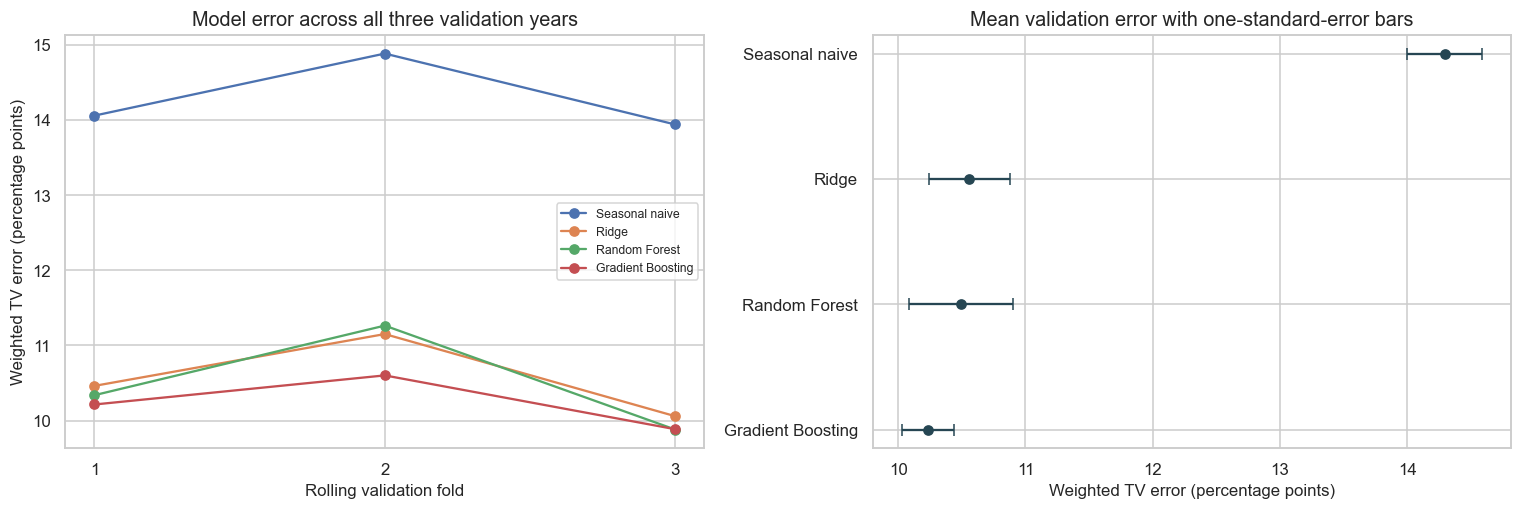

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for model_name, group in all_cv_metrics.groupby('model', sort=False):
    group = group.sort_values('fold')
    axes[0].plot(group['fold'], 100 * group['weighted_tv'], marker='o', label=model_name)
axes[0].set(
    title='Model error across all three validation years',
    xlabel='Rolling validation fold',
    ylabel='Weighted TV error (percentage points)',
    xticks=[1, 2, 3],
)
axes[0].legend(fontsize=8)

cv_plot = cv_comparison.sort_values('mean_weighted_tv')
axes[1].errorbar(
    100 * cv_plot['mean_weighted_tv'],
    cv_plot['model'],
    xerr=100 * cv_plot['standard_error'],
    fmt='o',
    color='#264653',
    capsize=4,
)
axes[1].set(
    title='Mean validation error with one-standard-error bars',
    xlabel='Weighted TV error (percentage points)',
    ylabel='',
)
plt.tight_layout()
plt.show()


### Findings

- Development CV selects **Gradient Boosting** with the full 372-field survey block plus lagged
  external context; mean weighted TV is **0.1023**.
- The one-SE parameters are 100 trees, learning rate 0.03, depth 1, minimum leaf size 20 and Huber
  loss—simpler than the empirical-minimum candidate.
- External context clears the 0.001 gain rule for Random Forest and Gradient Boosting, but not
  Ridge. The compact 51-index representation is slightly worse for every model, so it remains a
  sensitivity analysis.


## 10. One final-year evaluation

After development-only selection, every fitted model is retrained on all months through October
2022. The November 2022–October 2023 test year is opened once. Borough-block bootstrap intervals
describe uncertainty in aggregate test TV; they do not alter model selection.


In [27]:
model_templates = selected_estimators_by_model.copy()
fitted_models = {}
test_predictions = {'Seasonal naive': seasonal_naive(holdout)}
train_predictions = {'Seasonal naive': seasonal_naive(development)}

for model_name, template in model_templates.items():
    selected_features = selected_numeric_features_by_model[model_name] + categorical_features
    fitted = clone(template)
    fitted.fit(
        development[selected_features],
        shares_to_alr(development[TARGETS]),
        model__sample_weight=normalised_fit_weights(development['effective_n']),
    )
    fitted_models[model_name] = fitted
    test_predictions[model_name] = alr_to_shares(fitted.predict(holdout[selected_features]))
    train_predictions[model_name] = alr_to_shares(fitted.predict(development[selected_features]))


### Aggregate test-error uncertainty

A borough-block bootstrap keeps each borough's 12-month trajectory together.


In [28]:
def month_block_interval(frame, predicted, repeats=1000):
    rng = np.random.default_rng(RANDOM_STATE)
    months = np.sort(frame['month_index'].unique())
    actual = frame[TARGETS].to_numpy(float)
    weights = frame['effective_n'].to_numpy(float)
    month_values = frame['month_index'].to_numpy()
    estimates = []
    for _ in range(repeats):
        sampled_months = rng.choice(months, size=len(months), replace=True)
        indices = np.concatenate(
            [np.flatnonzero(month_values == month) for month in sampled_months]
        )
        estimates.append(
            composition_metrics(actual[indices], predicted[indices], weights[indices])[
                'weighted_tv'
            ]
        )
    return np.quantile(estimates, [0.025, 0.975])


### Score all frozen models

The test table reports absolute error, target R² and skill relative to Seasonal Naive.


In [29]:
test_metric_rows = []
generalisation_rows = []
actual_test = holdout[TARGETS].to_numpy(float)
actual_train = development[TARGETS].to_numpy(float)
for model_name, predicted in test_predictions.items():
    metrics = composition_metrics(actual_test, predicted, holdout['effective_n'])
    low, high = month_block_interval(holdout, predicted)
    test_metric_rows.append(
        {
            'model': model_name,
            **metrics,
            'weighted_tv_ci_low': low,
            'weighted_tv_ci_high': high,
        }
    )
    train_metric = composition_metrics(
        actual_train, train_predictions[model_name], development['effective_n']
    )
    generalisation_rows.append(
        {
            'model': model_name,
            'training weighted TV': train_metric['weighted_tv'],
            'test weighted TV': metrics['weighted_tv'],
            'test/train ratio': metrics['weighted_tv'] / train_metric['weighted_tv'],
        }
    )

test_metrics = pd.DataFrame(test_metric_rows).sort_values('weighted_tv')
naive_test_error = test_metrics.loc[
    test_metrics['model'].eq('Seasonal naive'), 'weighted_tv'
].iloc[0]
test_metrics['skill_vs_seasonal'] = 1 - test_metrics['weighted_tv'] / naive_test_error
generalisation = pd.DataFrame(generalisation_rows).sort_values('test weighted TV')

display(
    test_metrics[
        [
            'model',
            'weighted_tv',
            'weighted_tv_ci_low',
            'weighted_tv_ci_high',
            'unweighted_tv',
            'skill_vs_seasonal',
        ]
    ].style.format(
        {
            column: '{:.4f}'
            for column in [
                'weighted_tv',
                'weighted_tv_ci_low',
                'weighted_tv_ci_high',
                'unweighted_tv',
                'skill_vs_seasonal',
            ]
        }
    )
)
display(
    generalisation.style.format(
        {
            'training weighted TV': '{:.4f}',
            'test weighted TV': '{:.4f}',
            'test/train ratio': '{:.2f}',
        }
    )
)


,model,weighted_tv,weighted_tv_ci_low,weighted_tv_ci_high,unweighted_tv,skill_vs_seasonal
3,Gradient Boosting,0.1031,0.0958,0.1115,0.1052,0.2605
2,Random Forest,0.1034,0.0960,0.1117,0.1053,0.2587
1,Ridge,0.1043,0.0965,0.1125,0.1069,0.2519
0,Seasonal naive,0.1394,0.1272,0.1543,0.1439,0.0000


,model,training weighted TV,test weighted TV,test/train ratio
3,Gradient Boosting,0.0997,0.1031,1.03
2,Random Forest,0.0912,0.1034,1.13
1,Ridge,0.1027,0.1043,1.02
0,Seasonal naive,0.1413,0.1394,0.99


### Export holdout predictions

Observed and model-specific coherent shares are written once for audit and downstream explainability.


In [30]:
prediction_output = (
    holdout[
        [
            'month_index',
            'period_start',
            'geography_code',
            'geography_name',
            'inner_outer',
            'effective_n',
        ]
    ]
    .reset_index(drop=True)
    .copy()
)
for index, target in enumerate(TARGETS):
    prediction_output[f'actual_{target}'] = actual_test[:, index]
for model_name, predicted in test_predictions.items():
    safe_name = model_name.lower().replace(' ', '_')
    for index, target in enumerate(TARGETS):
        prediction_output[f'{safe_name}_{target}'] = predicted[:, index]

all_cv_metrics.to_csv(
    OUTPUT_DIR / 'monthly_forecast_cv_fold_metrics.csv', index=False, encoding='utf-8-sig'
)
cv_comparison.to_csv(
    OUTPUT_DIR / 'monthly_forecast_cv_metrics.csv', index=False, encoding='utf-8-sig'
)
test_metrics.to_csv(
    OUTPUT_DIR / 'monthly_forecast_test_metrics.csv', index=False, encoding='utf-8-sig'
)
prediction_output.to_csv(
    OUTPUT_DIR / 'monthly_forecast_holdout_predictions.csv', index=False, encoding='utf-8-sig'
)


In [31]:
target_metric_rows = []
for _, row in test_metrics.iterrows():
    for target in TARGETS:
        target_metric_rows.append(
            {
                'model': row['model'],
                'target': TARGET_LABELS[target],
                'weighted MAE': row[f'{target}_mae'],
                'weighted RMSE': row[f'{target}_rmse'],
                'weighted R2': row[f'{target}_r2'],
            }
        )
target_metrics = pd.DataFrame(target_metric_rows)
display(
    target_metrics.pivot(index='model', columns='target', values='weighted MAE').style.format(
        '{:.2%}'
    )
)
display(
    target_metrics.pivot(index='model', columns='target', values='weighted R2').style.format(
        '{:.3f}'
    )
)
target_metrics.to_csv(
    OUTPUT_DIR / 'monthly_forecast_test_target_metrics.csv', index=False, encoding='utf-8-sig'
)


target,Active,Fairly active,Inactive
model,,,
Gradient Boosting,8.59%,4.49%,7.54%
Random Forest,8.65%,4.51%,7.52%
Ridge,8.68%,4.47%,7.71%
Seasonal naive,11.26%,6.29%,10.33%


target,Active,Fairly active,Inactive
model,,,
Gradient Boosting,0.150,0.017,0.135
Random Forest,0.116,-0.058,0.136
Ridge,0.114,-0.015,0.107
Seasonal naive,-0.485,-0.986,-0.559


### Findings

On the independent test year, Gradient Boosting achieves weighted TV **0.1031**, compared with
**0.1394** for Seasonal Naive—a **26.0%** relative improvement. Absolute accuracy is still limited:
Inactive MAE is **7.54 pp**, Fairly-active MAE **4.49 pp**, Active MAE **8.59 pp**, and
Fairly-active R² is only **0.017**. Relative skill does not make the monthly estimates precise.


## 11. Forecast plots and empirical error bands

Actual and predicted shares are compared by target and month. Componentwise empirical error bands
use the 90th percentile of absolute rolling-validation residuals. They are descriptive error bands,
not model quantiles and not a joint probability region on the simplex.


,target,development residual quantile,weighted test coverage,average empirical band width
0,Inactive,90% absolute-error quantile,91.2%,32.8%
1,Fairly active,90% absolute-error quantile,92.6%,19.2%
2,Active,90% absolute-error quantile,92.9%,36.6%


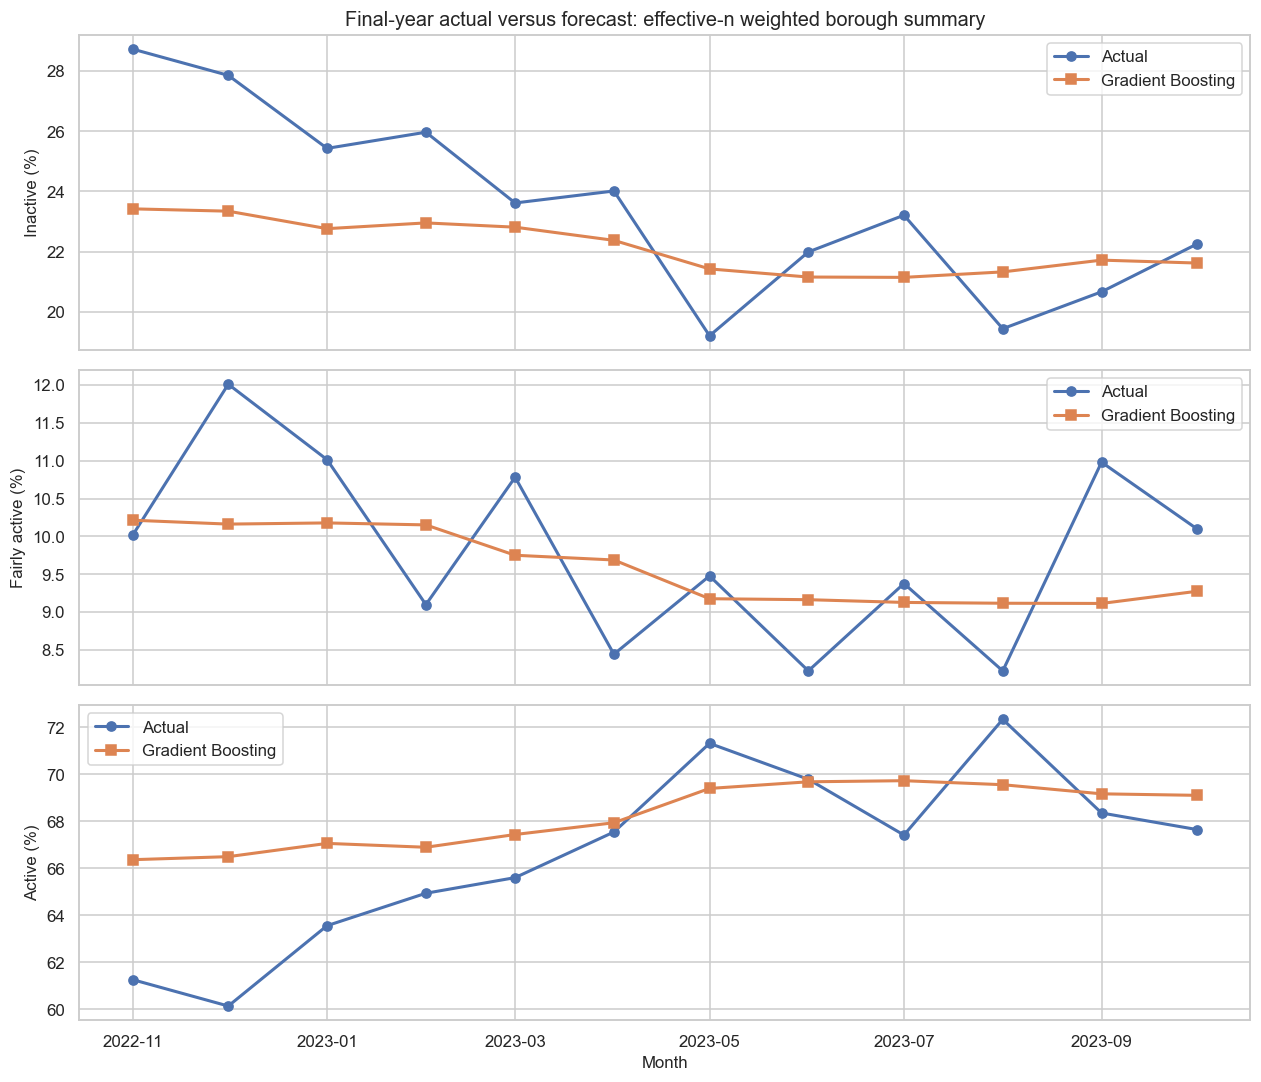

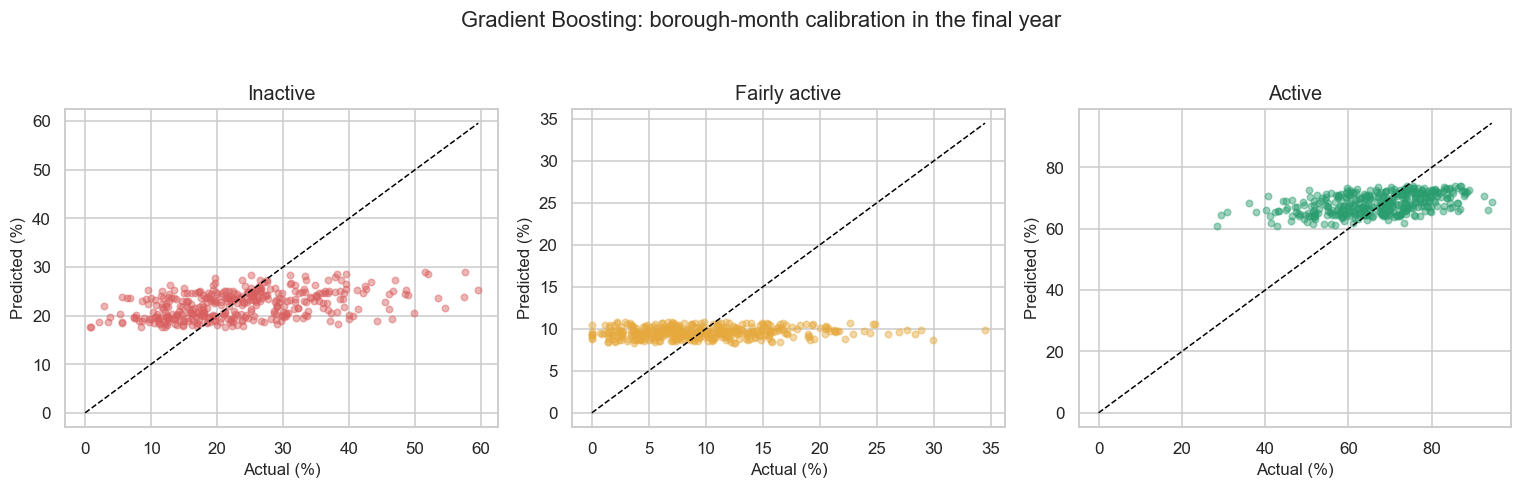

In [32]:
selected_predictions = test_predictions[SELECTED_MODEL]
selected_safe_name = SELECTED_MODEL.lower().replace(' ', '_')

cv_selected = cv_predictions[SELECTED_MODEL]
empirical_error_radii = {}
for target in TARGETS:
    empirical_error_radii[target] = np.quantile(
        np.abs(cv_selected[f'actual_{target}'] - cv_selected[f'predicted_{target}']), 0.90
    )

coverage_rows = []
for index, target in enumerate(TARGETS):
    radius = empirical_error_radii[target]
    lower = np.clip(selected_predictions[:, index] - radius, 0, 1)
    upper = np.clip(selected_predictions[:, index] + radius, 0, 1)
    prediction_output[f'{selected_safe_name}_{target}_empirical_error_band_lower'] = lower
    prediction_output[f'{selected_safe_name}_{target}_empirical_error_band_upper'] = upper
    covered = (actual_test[:, index] >= lower) & (actual_test[:, index] <= upper)
    coverage_rows.append(
        {
            'target': TARGET_LABELS[target],
            'development residual quantile': '90% absolute-error quantile',
            'weighted test coverage': np.average(covered, weights=holdout['effective_n']),
            'average empirical band width': np.average(
                upper - lower, weights=holdout['effective_n']
            ),
        }
    )
prediction_output.to_csv(
    OUTPUT_DIR / 'monthly_forecast_holdout_predictions.csv', index=False, encoding='utf-8-sig'
)
coverage_summary = pd.DataFrame(coverage_rows)
coverage_summary.to_csv(
    OUTPUT_DIR / 'monthly_forecast_empirical_error_band_coverage.csv',
    index=False,
    encoding='utf-8-sig',
)
display(
    coverage_summary.style.format(
        {'weighted test coverage': '{:.1%}', 'average empirical band width': '{:.1%}'}
    )
)


def weighted_monthly_series(frame, actual, predicted, target_index):
    rows = []
    for month, positions in frame.groupby('month_index').indices.items():
        positions = np.asarray(positions)
        weights = frame.iloc[positions]['effective_n'].to_numpy(float)
        rows.append(
            {
                'month_index': month,
                'period_start': frame.iloc[positions]['period_start'].iloc[0],
                'actual': np.average(actual[positions, target_index], weights=weights),
                'predicted': np.average(predicted[positions, target_index], weights=weights),
            }
        )
    return pd.DataFrame(rows).sort_values('month_index')


fig, axes = plt.subplots(3, 1, figsize=(11.5, 10), sharex=True)
for index, (ax, target) in enumerate(zip(axes, TARGETS)):
    series = weighted_monthly_series(
        holdout.reset_index(drop=True), actual_test, selected_predictions, index
    )
    ax.plot(
        series['period_start'], 100 * series['actual'], marker='o', linewidth=2, label='Actual'
    )
    ax.plot(
        series['period_start'],
        100 * series['predicted'],
        marker='s',
        linewidth=2,
        label=SELECTED_MODEL,
    )
    ax.set_ylabel(TARGET_LABELS[target] + ' (%)')
    ax.legend()
axes[0].set_title('Final-year actual versus forecast: effective-n weighted borough summary')
axes[-1].set_xlabel('Month')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
for index, (ax, target) in enumerate(zip(axes, TARGETS)):
    ax.scatter(
        100 * actual_test[:, index],
        100 * selected_predictions[:, index],
        s=18,
        alpha=0.45,
        color=colors[index],
    )
    limits = [0, 100 * max(actual_test[:, index].max(), selected_predictions[:, index].max())]
    ax.plot(limits, limits, color='black', linestyle='--', linewidth=1)
    ax.set(title=TARGET_LABELS[target], xlabel='Actual (%)', ylabel='Predicted (%)')
plt.suptitle(f'{SELECTED_MODEL}: borough-month calibration in the final year', y=1.03)
plt.tight_layout()
plt.show()


### Findings

The empirical bands cover roughly **91–93%** of weighted test observations, close to their nominal
90% development-residual target, but their average widths are large: about **19.2–36.6 percentage
points** depending on the component. They communicate forecast uncertainty, not a calibrated joint
distribution of the three shares.


## 12. Diagnostics and sensitivity

Diagnostics check borough/month residual structure, COVID versus other validation periods,
effective-sample thresholds, ALR epsilon, model coherence and feature reliance. These checks assess
stability; they do not reopen model selection after the test year.


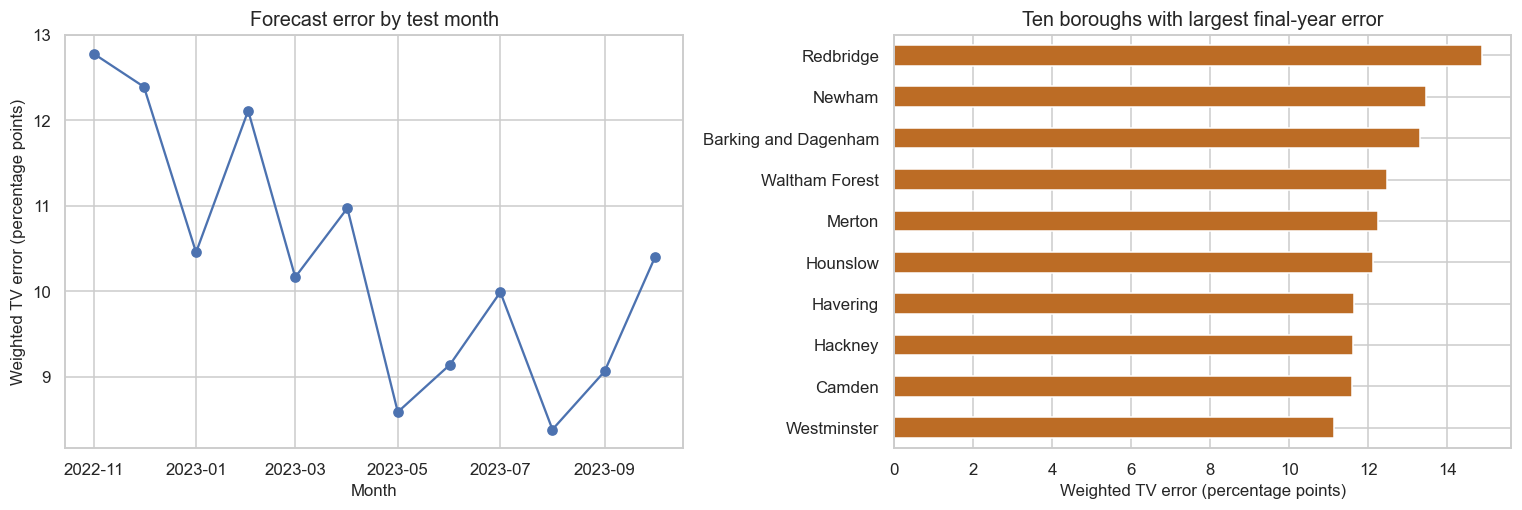

In [33]:
diagnostic = (
    holdout[['month_index', 'period_start', 'geography_name', 'effective_n']]
    .reset_index(drop=True)
    .copy()
)
diagnostic['total_variation_error'] = 0.5 * np.abs(actual_test - selected_predictions).sum(axis=1)
diagnostic['active_residual'] = actual_test[:, 2] - selected_predictions[:, 2]

monthly_error = (
    diagnostic.groupby(['month_index', 'period_start'])
    .apply(
        lambda group: np.average(group['total_variation_error'], weights=group['effective_n']),
        include_groups=False,
    )
    .rename('weighted_tv')
    .reset_index()
)
borough_error = (
    diagnostic.groupby('geography_name')
    .apply(
        lambda group: np.average(group['total_variation_error'], weights=group['effective_n']),
        include_groups=False,
    )
    .rename('weighted_tv')
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].plot(monthly_error['period_start'], 100 * monthly_error['weighted_tv'], marker='o')
axes[0].set(
    title='Forecast error by test month',
    xlabel='Month',
    ylabel='Weighted TV error (percentage points)',
)
borough_error.tail(10).mul(100).plot(kind='barh', color='#bc6c25', ax=axes[1])
axes[1].set(
    title='Ten boroughs with largest final-year error',
    xlabel='Weighted TV error (percentage points)',
    ylabel='',
)
plt.tight_layout()
plt.show()


### COVID-period validation error

This comparison diagnoses regime difficulty; it is not used to remove COVID observations.


In [34]:
cv_covid = cv_selected.copy()
cv_covid['covid_period'] = np.where(
    covid_restriction_flag(cv_covid['period_start']).astype(bool), 'COVID period', 'Other period'
)
covid_metric_rows = []
for period_label, group in cv_covid.groupby('covid_period', sort=False):
    actual_columns = [f'actual_{target}' for target in TARGETS]
    predicted_columns = [f'predicted_{target}' for target in TARGETS]
    metrics = composition_metrics(
        group[actual_columns], group[predicted_columns], group['effective_n']
    )
    covid_metric_rows.append(
        {
            'validation period': period_label,
            'rows': len(group),
            'months': group['month_index'].nunique(),
            'weighted TV': metrics['weighted_tv'],
            'unweighted TV': metrics['unweighted_tv'],
        }
    )
covid_sensitivity = pd.DataFrame(covid_metric_rows)
display(covid_sensitivity.style.format({'weighted TV': '{:.4f}', 'unweighted TV': '{:.4f}'}))
covid_sensitivity.to_csv(
    OUTPUT_DIR / 'monthly_forecast_covid_sensitivity.csv', index=False, encoding='utf-8-sig'
)


,validation period,rows,months,weighted TV,unweighted TV
0,Other period,511,16,0.0912,0.0967
1,COVID period,639,20,0.1111,0.1166


### Effective-sample sensitivity

Thresholding is reported only as a diagnostic because dropping low-precision observations after testing would bias the result.


In [35]:
sensitivity_rows = []
for threshold in [0, 10, 15, 20, 30]:
    keep = holdout['effective_n'].ge(threshold).to_numpy()
    metrics = composition_metrics(
        actual_test[keep], selected_predictions[keep], holdout.loc[keep, 'effective_n']
    )
    sensitivity_rows.append(
        {
            'minimum effective_n': threshold,
            'rows retained': int(keep.sum()),
            'weighted TV': metrics['weighted_tv'],
            'unweighted TV': metrics['unweighted_tv'],
        }
    )
sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity.style.format({'weighted TV': '{:.4f}', 'unweighted TV': '{:.4f}'}))


,minimum effective_n,rows retained,weighted TV,unweighted TV
0,0,384,0.1031,0.1052
1,10,381,0.1032,0.1054
2,15,365,0.1027,0.1043
3,20,307,0.1016,0.1027
4,30,106,0.0990,0.0995


### Transformation and coherence checks

The ALR zero guard is varied and every final prediction is checked to lie in `[0,1]` and sum to one.


In [36]:
epsilon_rows = []
for epsilon in [1e-6, ALR_EPSILON, 1e-3]:
    if SELECTED_MODEL == 'Seasonal naive':
        epsilon_prediction = seasonal_naive(holdout)
    elif np.isclose(epsilon, ALR_EPSILON):
        epsilon_prediction = selected_predictions
    else:
        epsilon_model = clone(model_templates[SELECTED_MODEL])
        epsilon_model.fit(
            development[model_features],
            shares_to_alr(development[TARGETS], epsilon=epsilon),
            model__sample_weight=normalised_fit_weights(development['effective_n']),
        )
        epsilon_prediction = alr_to_shares(epsilon_model.predict(holdout[model_features]))
    epsilon_metric = composition_metrics(actual_test, epsilon_prediction, holdout['effective_n'])
    epsilon_rows.append({'ALR epsilon': epsilon, 'weighted TV': epsilon_metric['weighted_tv']})
epsilon_sensitivity = pd.DataFrame(epsilon_rows)
display(epsilon_sensitivity.style.format({'ALR epsilon': '{:.0e}', 'weighted TV': '{:.4f}'}))
sensitivity.to_csv(
    OUTPUT_DIR / 'monthly_forecast_effective_n_sensitivity.csv', index=False, encoding='utf-8-sig'
)
epsilon_sensitivity.to_csv(
    OUTPUT_DIR / 'monthly_forecast_alr_sensitivity.csv', index=False, encoding='utf-8-sig'
)

assert np.allclose(selected_predictions.sum(axis=1), 1.0, atol=1e-12)
assert ((selected_predictions >= 0) & (selected_predictions <= 1)).all()


,ALR epsilon,weighted TV
0,1e-06,0.1031
1,1e-04,0.1031
2,1e-03,0.1031


,effective_n_band,rows,weighted_tv,unweighted_tv,median_effective_n
0,<10 (very low),3.000000,0.0833,0.0819,9.6
1,10–<20 (low),74.000000,0.1143,0.1165,17.4
2,20–<30 (caution),201.000000,0.1036,0.1043,24.9
3,≥30 (preferred),106.000000,0.0990,0.0995,34.9


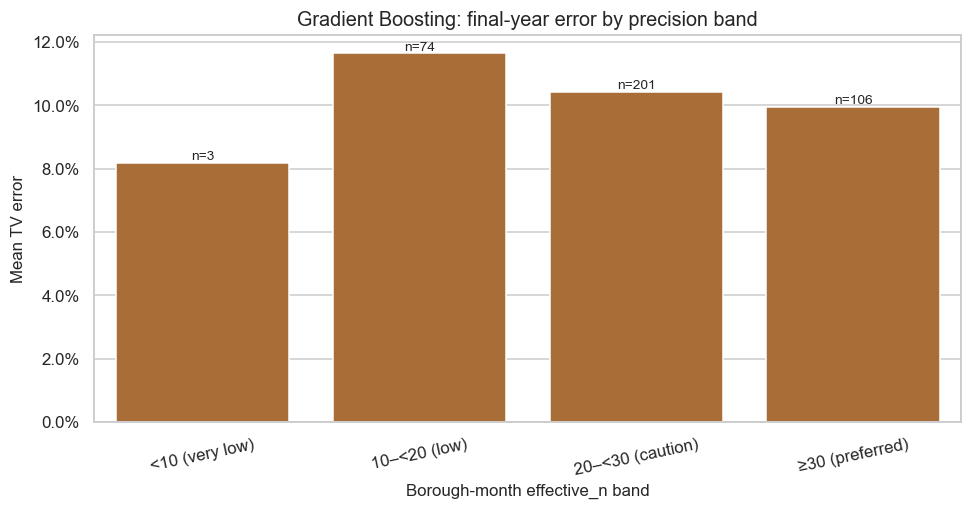

In [37]:
diagnostic['effective_n_band'] = pd.cut(
    diagnostic['effective_n'],
    bins=[0, VERY_LOW_EFFECTIVE_N, LOW_EFFECTIVE_N, PREFERRED_EFFECTIVE_N, np.inf],
    right=False,
    labels=['<10 (very low)', '10–<20 (low)', '20–<30 (caution)', '≥30 (preferred)'],
)
test_error_by_precision = (
    diagnostic.groupby('effective_n_band', observed=True)
    .apply(
        lambda group: pd.Series(
            {
                'rows': len(group),
                'weighted_tv': np.average(
                    group['total_variation_error'], weights=group['effective_n']
                ),
                'unweighted_tv': group['total_variation_error'].mean(),
                'median_effective_n': group['effective_n'].median(),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)
display(
    test_error_by_precision.style.format(
        {'weighted_tv': '{:.4f}', 'unweighted_tv': '{:.4f}', 'median_effective_n': '{:.1f}'}
    )
)

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(
    data=test_error_by_precision, x='effective_n_band', y='unweighted_tv', color='#bc6c25', ax=ax
)
for patch, rows in zip(ax.patches, test_error_by_precision['rows']):
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height(),
        f'n={int(rows)}',
        ha='center',
        va='bottom',
        fontsize=9,
    )
ax.set(
    title=f'{SELECTED_MODEL}: final-year error by precision band',
    xlabel='Borough-month effective_n band',
    ylabel='Mean TV error',
)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.tick_params(axis='x', rotation=12)
plt.tight_layout()
plt.show()
test_error_by_precision.to_csv(
    OUTPUT_DIR / 'monthly_forecast_error_by_effective_n_band.csv',
    index=False,
    encoding='utf-8-sig',
)


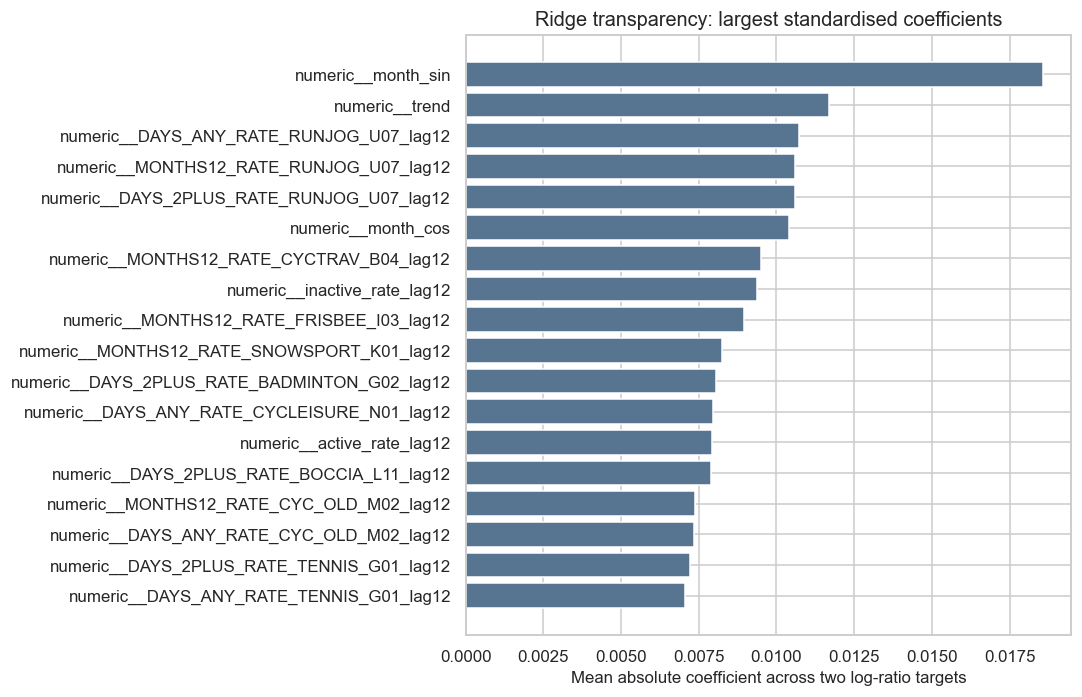

,feature,inactive_vs_active,fairly_vs_active,mean_abs_coefficient
1,numeric__month_sin,0.014094,0.023025,0.018560
0,numeric__trend,-0.002169,-0.021199,0.011684
237,numeric__DAYS_ANY_RATE_RUNJOG_U07_lag12,-0.014130,-0.007332,0.010731
115,numeric__MONTHS12_RATE_RUNJOG_U07_lag12,-0.013190,-0.008011,0.010600
358,numeric__DAYS_2PLUS_RATE_RUNJOG_U07_lag12,-0.013245,-0.007927,0.010586
2,numeric__month_cos,0.009666,0.011167,0.010416
12,numeric__MONTHS12_RATE_CYCTRAV_B04_lag12,-0.009824,-0.009150,0.009487
5,numeric__inactive_rate_lag12,0.013131,0.005587,0.009359
46,numeric__MONTHS12_RATE_FRISBEE_I03_lag12,-0.004064,-0.013837,0.008950
59,numeric__MONTHS12_RATE_SNOWSPORT_K01_lag12,-0.007199,-0.009324,0.008261


,explicit COVID calendar feature,inactive_vs_active,fairly_vs_active,mean_abs_coefficient
3,numeric__covid_restriction_flag,0.006005,0.001410,0.003708
4,numeric__covid_lag12_source_flag,-0.001044,-0.008657,0.004851


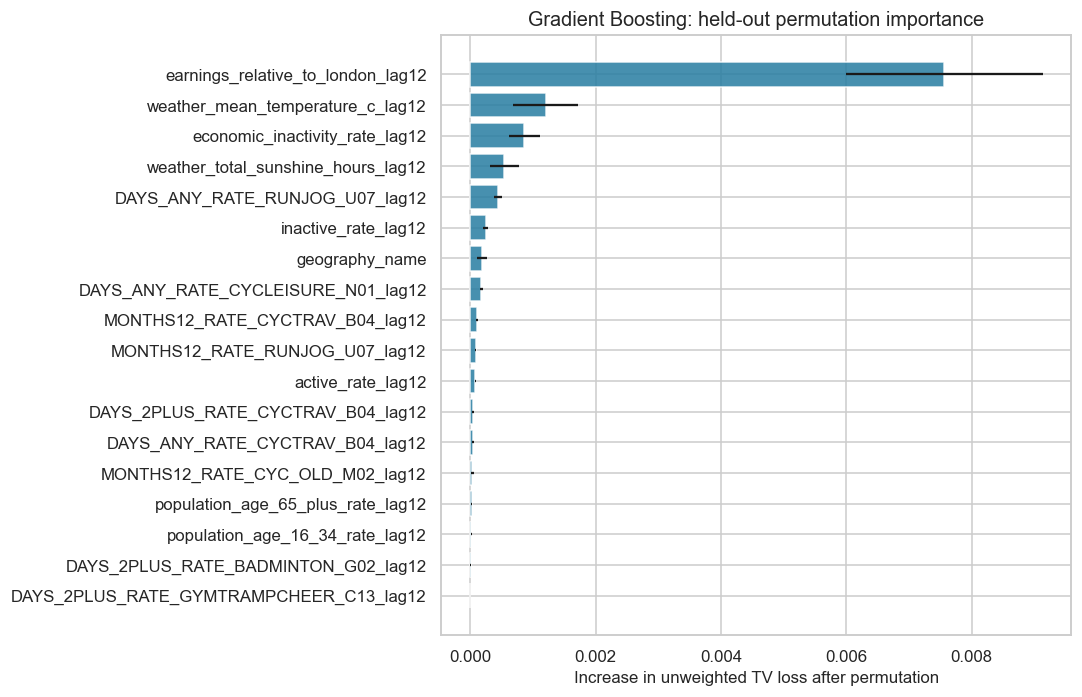

,feature,importance_mean,importance_sd
386,earnings_relative_to_london_lag12,0.007563,0.001570
388,weather_mean_temperature_c_lag12,0.001198,0.000524
387,economic_inactivity_rate_lag12,0.000856,0.000247
390,weather_total_sunshine_hours_lag12,0.000542,0.000239
239,DAYS_ANY_RATE_RUNJOG_U07_lag12,0.000436,0.000067
5,inactive_rate_lag12,0.000240,0.000045
393,geography_name,0.000188,0.000078
202,DAYS_ANY_RATE_CYCLEISURE_N01_lag12,0.000176,0.000025
12,MONTHS12_RATE_CYCTRAV_B04_lag12,0.000105,0.000014
115,MONTHS12_RATE_RUNJOG_U07_lag12,0.000081,0.000002


In [38]:
ridge = fitted_models['Ridge']
ridge_feature_names = ridge.named_steps['preprocessor'].get_feature_names_out()
ridge_coefficients = ridge.named_steps['model'].coef_
ridge_importance = pd.DataFrame(
    {
        'feature': ridge_feature_names,
        'inactive_vs_active': ridge_coefficients[0],
        'fairly_vs_active': ridge_coefficients[1],
    }
)
ridge_importance['mean_abs_coefficient'] = (
    ridge_importance[['inactive_vs_active', 'fairly_vs_active']].abs().mean(axis=1)
)
ridge_top = ridge_importance.nlargest(18, 'mean_abs_coefficient').sort_values(
    'mean_abs_coefficient'
)

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.barh(ridge_top['feature'], ridge_top['mean_abs_coefficient'], color='#577590')
ax.set(
    title='Ridge transparency: largest standardised coefficients',
    xlabel='Mean absolute coefficient across two log-ratio targets',
    ylabel='',
)
plt.tight_layout()
plt.show()
display(ridge_top.sort_values('mean_abs_coefficient', ascending=False).head(18))
display(
    ridge_importance.loc[
        ridge_importance['feature'].str.contains(r'covid_.*flag', regex=True)
    ].rename(columns={'feature': 'explicit COVID calendar feature'})
)


def alr_total_variation_loss(actual_coordinates, predicted_coordinates):
    actual = alr_to_shares(actual_coordinates)
    predicted = alr_to_shares(predicted_coordinates)
    return float(np.mean(0.5 * np.abs(actual - predicted).sum(axis=1)))


if SELECTED_MODEL != 'Seasonal naive':
    sample = holdout.sample(n=min(256, len(holdout)), random_state=RANDOM_STATE)
    scorer = make_scorer(alr_total_variation_loss, greater_is_better=False)
    permutation = permutation_importance(
        fitted_models[SELECTED_MODEL],
        sample[model_features],
        shares_to_alr(sample[TARGETS]),
        scoring=scorer,
        n_repeats=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    permutation_table = pd.DataFrame(
        {
            'feature': model_features,
            'importance_mean': permutation.importances_mean,
            'importance_sd': permutation.importances_std,
        }
    ).sort_values('importance_mean', ascending=False)
    permutation_top = permutation_table.head(18).sort_values('importance_mean')
    fig, ax = plt.subplots(figsize=(10, 6.5))
    ax.barh(
        permutation_top['feature'],
        permutation_top['importance_mean'],
        xerr=permutation_top['importance_sd'],
        color='#277da1',
        alpha=0.85,
    )
    ax.set(
        title=f'{SELECTED_MODEL}: held-out permutation importance',
        xlabel='Increase in unweighted TV loss after permutation',
        ylabel='',
    )
    plt.tight_layout()
    plt.show()
    display(permutation_table.head(20))
else:
    permutation_table = pd.DataFrame()


### Findings

COVID-period validation is harder than other periods (weighted TV **0.1111 vs 0.0912**). Restricting
the test to `effective_n ≥ 30` lowers TV from **0.1031 to 0.0990**, a modest change that does not
remove the exploratory label. ALR-epsilon and coherence checks pass. Feature rankings are treated
as model diagnostics; the more rigorous grouped explanation is in Notebook 03.


## 13. Monthly forecast conclusion

The compact table retains absolute target-level performance and empirical-band coverage. The
interpretation is stated in Markdown below rather than generated by presentation code.


In [39]:
selected_target_metrics = target_metrics.loc[target_metrics['model'].eq(SELECTED_MODEL)].copy()
absolute_performance = selected_target_metrics.merge(
    coverage_summary, on='target', validate='one_to_one'
)
absolute_performance.to_csv(
    OUTPUT_DIR / 'monthly_forecast_selected_model_absolute_performance.csv',
    index=False,
    encoding='utf-8-sig',
)
display(
    absolute_performance.style.format(
        {
            'weighted MAE': '{:.1%}',
            'weighted RMSE': '{:.1%}',
            'weighted R2': '{:.3f}',
            'weighted test coverage': '{:.1%}',
            'average empirical band width': '{:.1%}',
        }
    )
)

assert SELECTED_MODEL in {'Seasonal naive', 'Ridge', 'Random Forest', 'Gradient Boosting'}
assert test_metrics['weighted_tv'].notna().all()
assert (
    prediction_output.filter(regex=r'_(inactive|fairly_active|active)_rate$').notna().all().all()
)
assert set(external_feature_ablation['model']) == {'Ridge', 'Random Forest', 'Gradient Boosting'}
assert len(compact_activity_features) == 51


,model,target,weighted MAE,weighted RMSE,weighted R2,development residual quantile,weighted test coverage,average empirical band width
0,Gradient Boosting,Inactive,7.5%,9.7%,0.135,90% absolute-error quantile,91.2%,32.8%
1,Gradient Boosting,Fairly active,4.5%,5.7%,0.017,90% absolute-error quantile,92.6%,19.2%
2,Gradient Boosting,Active,8.6%,10.6%,0.150,90% absolute-error quantile,92.9%,36.6%


### Monthly conclusion

Gradient Boosting is the best development-selected benchmark and improves substantially on the
seasonal baseline, but borough-month sampling noise, 7.5–8.6 pp errors for the main inactive/active
components and wide empirical bands make the result **exploratory**. The honest conclusion is
therefore “useful relative signal, limited absolute precision.”


## 14. Borough clustering on development data only

Profiles use Years 1–6 and balanced feature blocks so the 372 activity fields cannot overwhelm
outcomes, survey composition or external context. PCA retains 90% variance. K-means, Ward and
Gaussian mixtures are assessed over 2–10 clusters using separation, minimum size and perturbation
stability; Year 7 and Year 8 never influence the solution.


In [40]:
CLUSTER_DEVELOPMENT_YEARS = range(1, 7)
CLUSTER_BLOCKS = {
    'outcomes': TARGETS,
    'survey composition': COMPOSITION_FEATURES,
    'external borough context': CLUSTER_CONTEXT_FEATURES,
    'activity participation': activity_columns,
}
CLUSTER_FEATURES = sum(CLUSTER_BLOCKS.values(), [])


def weighted_profile(group, columns):
    weights = group['effective_n'].to_numpy(float)[:, None]
    values = group[columns].to_numpy(float)
    valid = np.isfinite(values)
    numerator = np.nansum(values * weights, axis=0)
    denominator = np.sum(valid * weights, axis=0)
    return np.divide(
        numerator, denominator, out=np.full(len(columns), np.nan), where=denominator > 0
    )


cluster_profile_rows = []
cluster_source = borough_annual.loc[borough_annual['year'].isin(CLUSTER_DEVELOPMENT_YEARS)].copy()
for (code, name, area), group in cluster_source.groupby(
    ['geography_code', 'geography_name', 'inner_outer'], sort=True
):
    row = {'geography_code': code, 'geography_name': name, 'inner_outer': area}
    row.update(dict(zip(CLUSTER_FEATURES, weighted_profile(group, CLUSTER_FEATURES))))
    cluster_profile_rows.append(row)
borough_profiles = (
    pd.DataFrame(cluster_profile_rows).sort_values('geography_code').reset_index(drop=True)
)
assert len(borough_profiles) == 32 and borough_profiles['geography_code'].is_unique


def balanced_cluster_matrix(profile_frame, feature_blocks):
    # Equal total scale per conceptual block prevents 372 activity fields from
    # overwhelming the much smaller outcome, composition and context blocks.
    transformed_blocks = []
    for block_features in feature_blocks.values():
        values = SimpleImputer(strategy='median').fit_transform(profile_frame[block_features])
        values = StandardScaler().fit_transform(values)
        transformed_blocks.append(values / np.sqrt(len(block_features)))
    return np.column_stack(transformed_blocks)


profile_scaled = balanced_cluster_matrix(borough_profiles, CLUSTER_BLOCKS)
cluster_pca = PCA(n_components=0.90, svd_solver='full', random_state=RANDOM_STATE)
profile_scores = cluster_pca.fit_transform(profile_scaled)
assert profile_scores.shape[1] >= 2


### Candidate search and stability

All methods and cluster counts use the same PCA representation; perturbation ARI measures assignment stability.


In [41]:
def fit_cluster_labels(method, n_clusters, values, seed=RANDOM_STATE):
    if method == 'K-means':
        return KMeans(n_clusters=n_clusters, n_init=30, random_state=seed).fit_predict(values)
    if method == 'Ward':
        return AgglomerativeClustering(n_clusters=n_clusters, linkage='ward').fit_predict(values)
    if method == 'Gaussian mixture':
        return GaussianMixture(
            n_components=n_clusters,
            covariance_type='diag',
            reg_covar=1e-4,
            n_init=10,
            random_state=seed,
        ).fit_predict(values)
    raise ValueError(method)


rng = np.random.default_rng(RANDOM_STATE)
perturbation_scale = np.maximum(profile_scores.std(axis=0, ddof=1) * 0.03, 1e-8)
cluster_candidate_rows = []
area_reference_labels = borough_profiles['inner_outer'].eq('Inner London').astype(int).to_numpy()
for method in ['K-means', 'Ward', 'Gaussian mixture']:
    for n_clusters in range(2, 11):
        base_labels = fit_cluster_labels(method, n_clusters, profile_scores)
        stability = []
        for repeat in range(40):
            perturbed = profile_scores + rng.normal(0, perturbation_scale, profile_scores.shape)
            perturbed_labels = fit_cluster_labels(
                method, n_clusters, perturbed, seed=RANDOM_STATE + repeat + 1
            )
            stability.append(adjusted_rand_score(base_labels, perturbed_labels))
        counts = np.bincount(base_labels)
        cluster_candidate_rows.append(
            {
                'method': method,
                'n_clusters': n_clusters,
                'silhouette': silhouette_score(profile_scores, base_labels),
                'calinski_harabasz': calinski_harabasz_score(profile_scores, base_labels),
                'davies_bouldin': davies_bouldin_score(profile_scores, base_labels),
                'stability_ari': np.mean(stability),
                'inner_outer_nmi': normalized_mutual_info_score(
                    area_reference_labels, base_labels
                ),
                'minimum_cluster_size': counts.min(),
                'maximum_cluster_size': counts.max(),
            }
        )
cluster_selection = pd.DataFrame(cluster_candidate_rows)
eligible_clusters = cluster_selection.loc[
    cluster_selection['minimum_cluster_size'].ge(3) & cluster_selection['stability_ari'].ge(0.70)
].copy()
assert not eligible_clusters.empty
eligible_clusters['selection_rank'] = (
    eligible_clusters['silhouette'].rank(ascending=False, method='min')
    + eligible_clusters['calinski_harabasz'].rank(ascending=False, method='min')
    + eligible_clusters['davies_bouldin'].rank(ascending=True, method='min')
    + eligible_clusters['stability_ari'].rank(ascending=False, method='min')
)
best_two_cluster_row = (
    eligible_clusters.loc[eligible_clusters['n_clusters'].eq(2)]
    .sort_values(['selection_rank', 'stability_ari', 'silhouette'], ascending=[True, False, False])
    .iloc[0]
)
finer_candidates = eligible_clusters.loc[eligible_clusters['n_clusters'].ge(3)].copy()
best_finer_cluster_row = finer_candidates.sort_values(
    ['selection_rank', 'stability_ari', 'silhouette'], ascending=[True, False, False]
).iloc[0]
FINER_CLUSTER_SUPPORTED = bool(
    best_finer_cluster_row['silhouette'] >= best_two_cluster_row['silhouette'] + 0.02
    and best_finer_cluster_row['stability_ari'] >= 0.75
    and best_finer_cluster_row['minimum_cluster_size'] >= 3
)
chosen_cluster_row = best_finer_cluster_row if FINER_CLUSTER_SUPPORTED else best_two_cluster_row
CHOSEN_CLUSTER_METHOD = chosen_cluster_row['method']
CHOSEN_N_CLUSTERS = int(chosen_cluster_row['n_clusters'])
cluster_selection['eligible'] = cluster_selection['minimum_cluster_size'].ge(
    3
) & cluster_selection['stability_ari'].ge(0.70)
cluster_selection['selection_rank'] = np.nan
cluster_selection.loc[eligible_clusters.index, 'selection_rank'] = eligible_clusters[
    'selection_rank'
]
cluster_selection['selected'] = cluster_selection['method'].eq(
    CHOSEN_CLUSTER_METHOD
) & cluster_selection['n_clusters'].eq(CHOSEN_N_CLUSTERS)


### Freeze and label the selected solution

Cluster numbers are ordered by development-period active share, then compared with Inner/Outer London.


In [42]:
raw_cluster_labels = fit_cluster_labels(CHOSEN_CLUSTER_METHOD, CHOSEN_N_CLUSTERS, profile_scores)

# Give cluster numbers a stable interpretation: lower development-period active share first.
raw_active_means = (
    pd.Series(borough_profiles['active_rate']).groupby(raw_cluster_labels).mean().sort_values()
)
cluster_number_map = {
    raw_label: number for number, raw_label in enumerate(raw_active_means.index, start=1)
}
borough_profiles['cluster'] = [
    f'Cluster {cluster_number_map[label]}' for label in raw_cluster_labels
]
borough_profiles['pca_1'] = profile_scores[:, 0]
borough_profiles['pca_2'] = profile_scores[:, 1]
cluster_assignments = borough_profiles[
    ['geography_code', 'geography_name', 'inner_outer', 'cluster', 'pca_1', 'pca_2']
].copy()
if CHOSEN_N_CLUSTERS == 2:
    chosen_binary = cluster_assignments['cluster'].eq('Cluster 2').astype(int).to_numpy()
    inner_outer_agreement = max(
        np.mean(chosen_binary == area_reference_labels),
        np.mean((1 - chosen_binary) == area_reference_labels),
    )
    inner_outer_ari = adjusted_rand_score(area_reference_labels, chosen_binary)
else:
    inner_outer_agreement = np.nan
    inner_outer_ari = np.nan
TWO_CLUSTER_REPRODUCES_INNER_OUTER = bool(CHOSEN_N_CLUSTERS == 2 and inner_outer_agreement >= 0.85)
CLUSTER_FORECAST_JUSTIFIED = bool(
    FINER_CLUSTER_SUPPORTED and chosen_cluster_row['minimum_cluster_size'] >= 5
)
# Keep clusters descriptive: only 32 boroughs and six development years do not
# provide an independent cluster-level forecast sample, and group forecasting
# would overlap the team's Inner/Outer analysis.
USE_CLUSTER_FORECASTS = False
cluster_decision = pd.DataFrame(
    [
        {
            'chosen_method': CHOSEN_CLUSTER_METHOD,
            'chosen_n_clusters': CHOSEN_N_CLUSTERS,
            'chosen_silhouette': chosen_cluster_row['silhouette'],
            'chosen_stability_ari': chosen_cluster_row['stability_ari'],
            'best_finer_method': best_finer_cluster_row['method'],
            'best_finer_n_clusters': int(best_finer_cluster_row['n_clusters']),
            'best_finer_silhouette': best_finer_cluster_row['silhouette'],
            'best_finer_stability_ari': best_finer_cluster_row['stability_ari'],
            'finer_cluster_supported': FINER_CLUSTER_SUPPORTED,
            'inner_outer_agreement': inner_outer_agreement,
            'inner_outer_ari': inner_outer_ari,
            'cluster_forecast_statistically_justified': CLUSTER_FORECAST_JUSTIFIED,
            'use_cluster_forecasts': USE_CLUSTER_FORECASTS,
        }
    ]
)

cluster_selection.to_csv(
    OUTPUT_DIR / 'borough_cluster_selection.csv', index=False, encoding='utf-8-sig'
)
cluster_assignments.to_csv(
    OUTPUT_DIR / 'borough_cluster_assignments.csv', index=False, encoding='utf-8-sig'
)
borough_profiles.to_csv(
    OUTPUT_DIR / 'borough_cluster_development_profiles.csv', index=False, encoding='utf-8-sig'
)
cluster_decision.to_csv(
    OUTPUT_DIR / 'borough_cluster_decision.csv', index=False, encoding='utf-8-sig'
)

display(
    cluster_selection.sort_values(
        ['minimum_cluster_size', 'silhouette'], ascending=[False, False]
    ).style.format(
        {
            'silhouette': '{:.3f}',
            'calinski_harabasz': '{:.2f}',
            'davies_bouldin': '{:.3f}',
            'stability_ari': '{:.3f}',
            'inner_outer_nmi': '{:.3f}',
        }
    )
)


,method,n_clusters,silhouette,calinski_harabasz,davies_bouldin,stability_ari,inner_outer_nmi,minimum_cluster_size,maximum_cluster_size,eligible,selection_rank,selected
0,K-means,2,0.234,11.15,1.566,0.789,0.236,14,18,True,9.000000,True
9,Ward,2,0.187,8.99,1.706,0.649,0.236,14,18,False,nan,False
18,Gaussian mixture,2,0.101,4.91,2.048,0.420,0.126,9,23,False,nan,False
1,K-means,3,0.220,10.24,1.438,0.922,0.360,8,15,True,8.000000,False
10,Ward,3,0.183,9.27,1.442,0.728,0.187,8,14,True,15.000000,False
2,K-means,4,0.182,9.13,1.409,0.751,0.357,6,11,True,13.000000,False
19,Gaussian mixture,3,0.117,6.02,1.906,0.292,0.222,5,14,False,nan,False
11,Ward,4,0.177,8.42,1.318,0.749,0.238,4,14,True,15.000000,False
15,Ward,8,0.204,8.25,1.001,0.892,0.360,1,8,False,nan,False
4,K-means,6,0.198,9.06,1.153,0.838,0.284,1,9,False,nan,False


### Cluster interpretation plots

Selection diagnostics, PCA locations and standardised profiles show both separation and overlap.


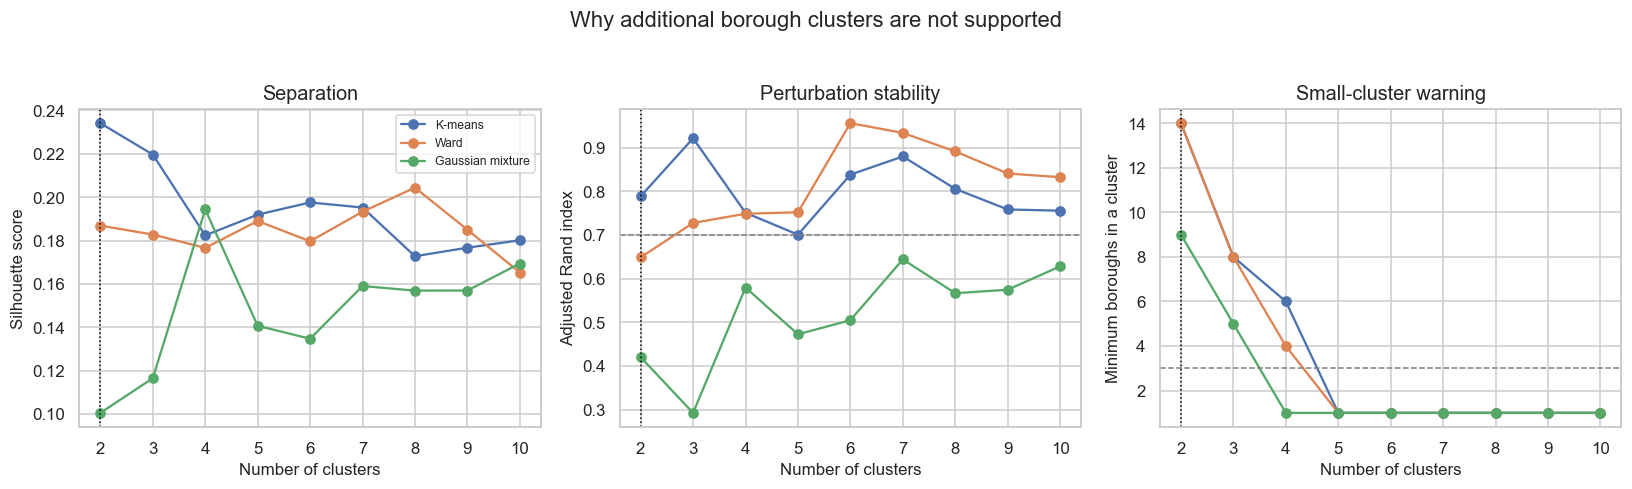

,boroughs,members
cluster,,
Cluster 1,18,"Barking and Dagenham, Barnet, Bexley, Brent, C..."
Cluster 2,14,"Bromley, Camden, Hackney, Hammersmith and Fulh..."


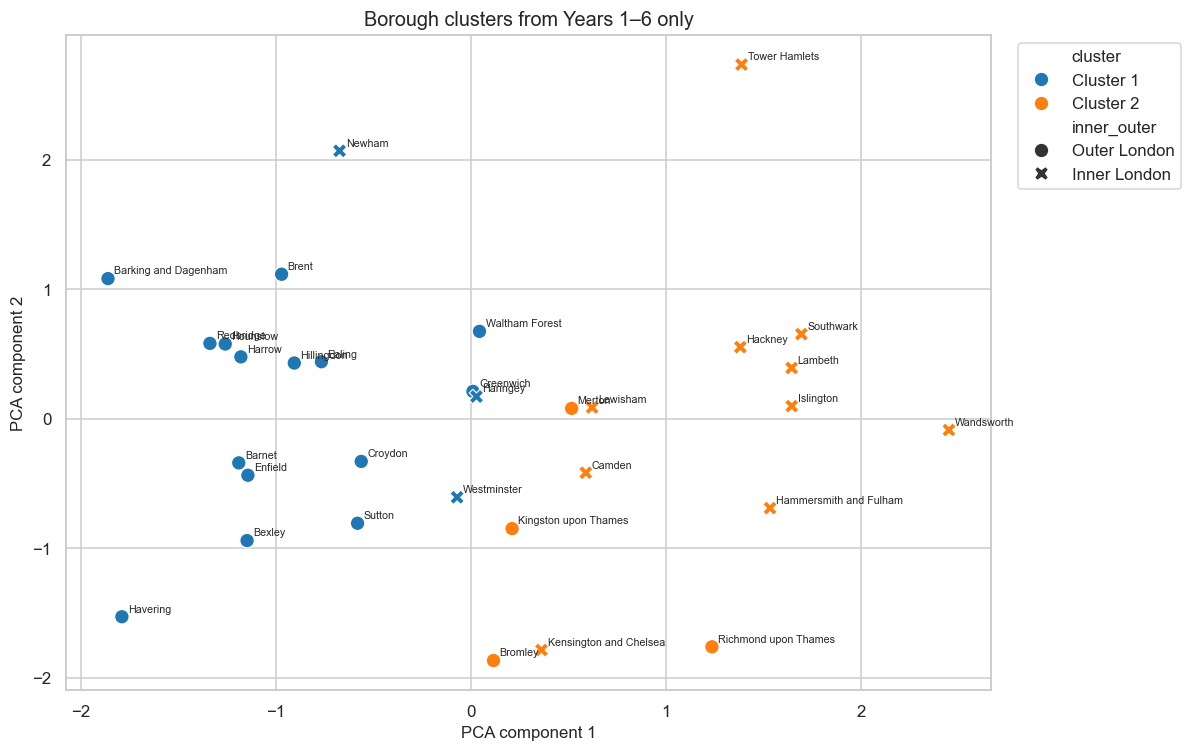

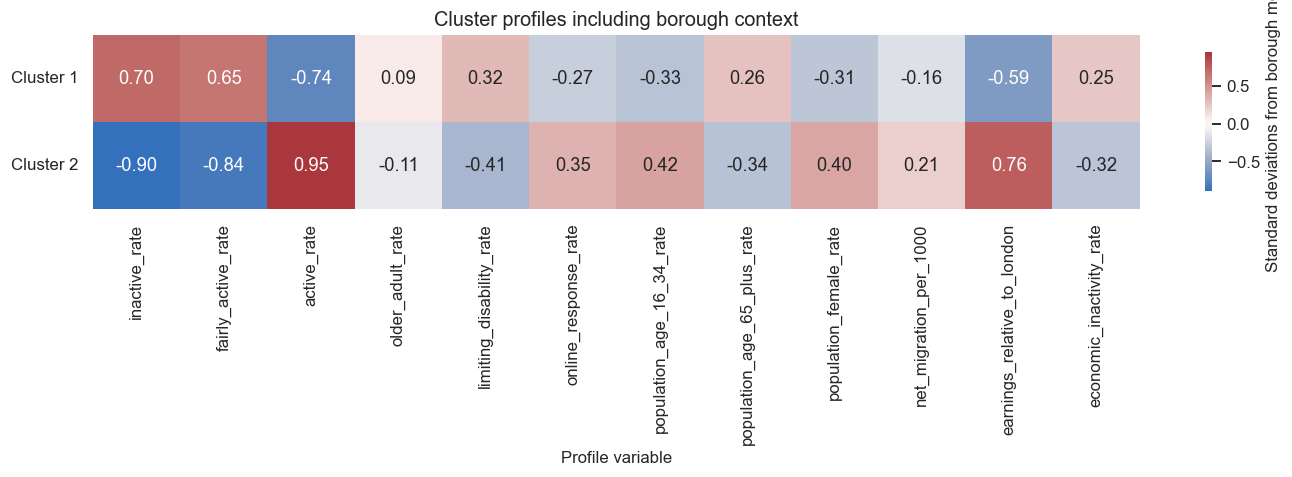

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), sharex=True)
for method, group in cluster_selection.groupby('method', sort=False):
    group = group.sort_values('n_clusters')
    axes[0].plot(group['n_clusters'], group['silhouette'], marker='o', label=method)
    axes[1].plot(group['n_clusters'], group['stability_ari'], marker='o', label=method)
    axes[2].plot(group['n_clusters'], group['minimum_cluster_size'], marker='o', label=method)
axes[0].set(title='Separation', ylabel='Silhouette score')
axes[1].set(title='Perturbation stability', ylabel='Adjusted Rand index')
axes[1].axhline(0.70, color='grey', linestyle='--', linewidth=1, label='Eligibility threshold')
axes[2].set(title='Small-cluster warning', ylabel='Minimum boroughs in a cluster')
axes[2].axhline(3, color='grey', linestyle='--', linewidth=1, label='Minimum acceptable size')
for ax in axes:
    ax.axvline(CHOSEN_N_CLUSTERS, color='black', linestyle=':', linewidth=1)
    ax.set_xlabel('Number of clusters')
    ax.set_xticks(range(2, 11))
axes[0].legend(fontsize=8)
plt.suptitle('Why additional borough clusters are not supported', y=1.03)
plt.tight_layout()
plt.show()

cluster_members = cluster_assignments.groupby('cluster').agg(
    boroughs=('geography_name', 'size'),
    members=('geography_name', lambda values: ', '.join(values)),
)
display(cluster_members)

fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(
    data=cluster_assignments,
    x='pca_1',
    y='pca_2',
    hue='cluster',
    style='inner_outer',
    s=90,
    palette='tab10',
    ax=ax,
)
for _, row in cluster_assignments.iterrows():
    ax.annotate(
        row['geography_name'],
        (row['pca_1'], row['pca_2']),
        xytext=(4, 3),
        textcoords='offset points',
        fontsize=7,
    )
ax.set(
    title='Borough clusters from Years 1–6 only',
    xlabel='PCA component 1',
    ylabel='PCA component 2',
)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

cluster_display_features = TARGETS + COMPOSITION_FEATURES + CLUSTER_CONTEXT_FEATURES
cluster_display_values = pd.DataFrame(
    StandardScaler().fit_transform(borough_profiles[cluster_display_features]),
    columns=cluster_display_features,
    index=borough_profiles.index,
)
cluster_display_values['cluster'] = borough_profiles['cluster']
cluster_standardised_profile = cluster_display_values.groupby('cluster').mean()
fig, ax = plt.subplots(figsize=(13, max(4.5, 1.6 * CHOSEN_N_CLUSTERS)))
sns.heatmap(
    cluster_standardised_profile,
    annot=True,
    fmt='.2f',
    cmap='vlag',
    center=0,
    cbar_kws={'label': 'Standard deviations from borough mean', 'shrink': 0.80},
    ax=ax,
)
ax.set(title='Cluster profiles including borough context', xlabel='Profile variable', ylabel='')
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()


,representation,features,pca_components,ari_vs_selected_solution,silhouette,minimum_cluster_size
0,"Outcomes + composition, Years 1–6",6,3,1.000,0.328,14
1,"External context only, Years 1–6",6,4,0.227,0.291,10
2,"Outcomes + composition + context, Years 1–6",12,5,1.000,0.278,14
3,"Balanced full representation, Years 1–6",384,12,1.000,0.234,14
4,"Balanced full representation, pre-COVID Years 1–4",384,13,0.650,0.242,11


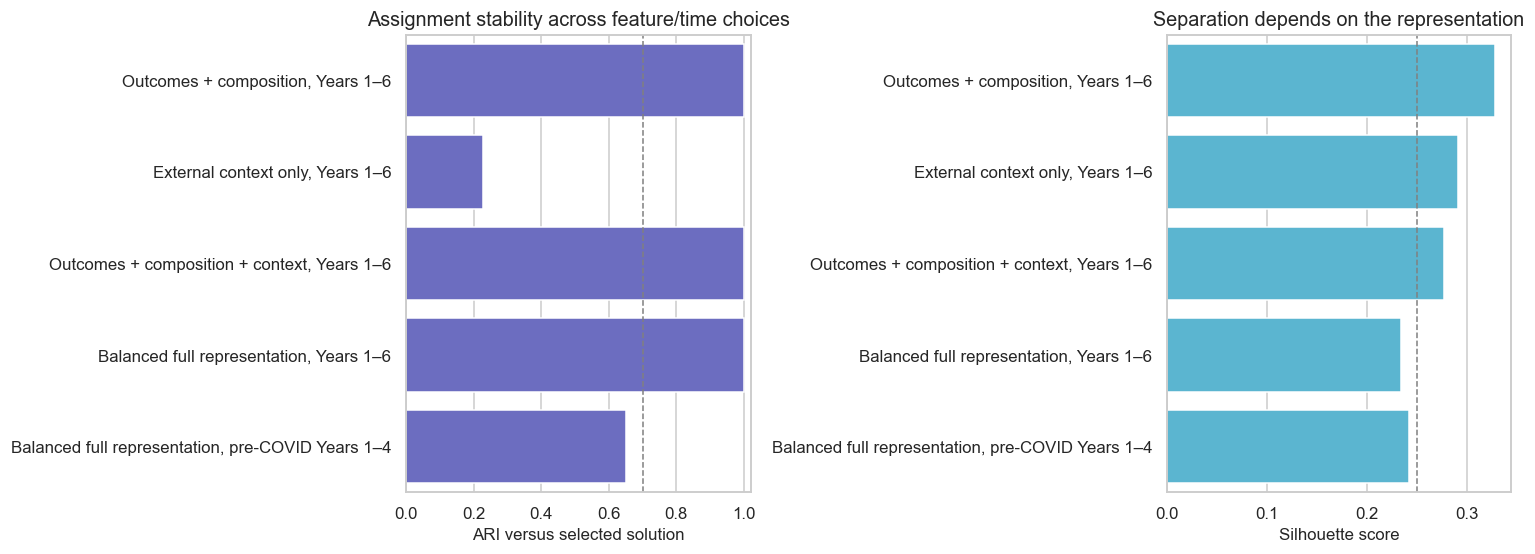

In [44]:
def fit_cluster_sensitivity_profile(years, feature_blocks):
    features = sum(feature_blocks.values(), [])
    rows = []
    source = borough_annual.loc[borough_annual['year'].isin(years)].copy()
    for (code, name), group in source.groupby(['geography_code', 'geography_name'], sort=True):
        row = {'geography_code': code, 'geography_name': name}
        row.update(dict(zip(features, weighted_profile(group, features))))
        rows.append(row)
    profiles = pd.DataFrame(rows).sort_values('geography_code').reset_index(drop=True)
    assert profiles['geography_code'].tolist() == borough_profiles['geography_code'].tolist()
    values = balanced_cluster_matrix(profiles, feature_blocks)
    pca = PCA(n_components=0.90, svd_solver='full', random_state=RANDOM_STATE)
    scores = pca.fit_transform(values)
    labels = fit_cluster_labels(CHOSEN_CLUSTER_METHOD, CHOSEN_N_CLUSTERS, scores)
    return labels, scores.shape[1], silhouette_score(scores, labels), np.bincount(labels).min()


cluster_sensitivity_specs = [
    (
        'Outcomes + composition, Years 1–6',
        range(1, 7),
        {
            'outcomes': TARGETS,
            'survey composition': COMPOSITION_FEATURES,
        },
    ),
    (
        'External context only, Years 1–6',
        range(1, 7),
        {
            'external borough context': CLUSTER_CONTEXT_FEATURES,
        },
    ),
    (
        'Outcomes + composition + context, Years 1–6',
        range(1, 7),
        {
            'outcomes': TARGETS,
            'survey composition': COMPOSITION_FEATURES,
            'external borough context': CLUSTER_CONTEXT_FEATURES,
        },
    ),
    ('Balanced full representation, Years 1–6', range(1, 7), CLUSTER_BLOCKS),
    ('Balanced full representation, pre-COVID Years 1–4', range(1, 5), CLUSTER_BLOCKS),
]
cluster_sensitivity_rows = []
for label, years, feature_blocks in cluster_sensitivity_specs:
    labels, components, silhouette, minimum_size = fit_cluster_sensitivity_profile(
        years, feature_blocks
    )
    cluster_sensitivity_rows.append(
        {
            'representation': label,
            'features': sum(len(features) for features in feature_blocks.values()),
            'pca_components': components,
            'ari_vs_selected_solution': adjusted_rand_score(raw_cluster_labels, labels),
            'silhouette': silhouette,
            'minimum_cluster_size': minimum_size,
        }
    )
cluster_sensitivity = pd.DataFrame(cluster_sensitivity_rows)
cluster_sensitivity.to_csv(
    OUTPUT_DIR / 'borough_cluster_sensitivity.csv', index=False, encoding='utf-8-sig'
)
display(
    cluster_sensitivity.style.format(
        {'ari_vs_selected_solution': '{:.3f}', 'silhouette': '{:.3f}'}
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
sns.barplot(
    data=cluster_sensitivity,
    y='representation',
    x='ari_vs_selected_solution',
    color='#5e60ce',
    ax=axes[0],
)
axes[0].axvline(0.70, color='grey', linestyle='--', linewidth=1)
axes[0].set(
    title='Assignment stability across feature/time choices',
    xlabel='ARI versus selected solution',
    ylabel='',
    xlim=(0, 1.02),
)
sns.barplot(
    data=cluster_sensitivity, y='representation', x='silhouette', color='#48bfe3', ax=axes[1]
)
axes[1].axvline(0.25, color='grey', linestyle='--', linewidth=1)
axes[1].set(title='Separation depends on the representation', xlabel='Silhouette score', ylabel='')
plt.tight_layout()
plt.show()


### Findings

The selected solution is **K-means with two clusters** (silhouette 0.234; perturbation ARI 0.789).
A three-cluster solution is stable but has weaker separation, so extra complexity is not supported.
The two clusters agree with Inner/Outer labels for 78.1% of boroughs but have only ARI 0.294.
Sensitivity ARI ranges from 0.227 to 1.000, and the low silhouette indicates weak natural
separation. Clusters are descriptive planning summaries, not fixed borough types.


## 15. Annual forecast: six-year history, Year 7 validation, Year 8 test

Annual predictors are lagged one survey year. Models train on target Years 2–6, parameters and the
algorithm are chosen on Year 7, and Year 8 is an independent test. The grid is deliberately small:
one validation year contains only 32 boroughs, so an extensive search would tune to that year.
Annual external inputs are omitted a priori rather than inheriting a monthly decision.


In [45]:
annual_panel = borough_annual.sort_values(['geography_code', 'year']).reset_index(drop=True).copy()

annual_base_lag_sources = TARGETS + COMPOSITION_FEATURES + activity_columns
# Annual forecasting is deliberately decoupled from every monthly-model decision.
# With only 160 Year 2–6 training rows and a transparent naive model in contention,
# external fields are omitted a priori from annual ML benchmarks.
ANNUAL_USE_EXTERNAL_CONTEXT = False
annual_external_lag_sources = []
annual_lag_sources = annual_base_lag_sources + annual_external_lag_sources
annual_grouped = annual_panel.groupby('geography_code', sort=False)
annual_engineered = {
    'annual_trend': annual_panel['year'].astype(float),
    'annual_covid_overlap_flag': annual_panel['year'].isin([5, 6, 7]).astype(int),
}
annual_engineered['annual_lag1_covid_source_flag'] = (
    annual_grouped['year'].shift(1).isin([5, 6, 7]).astype(int)
)
for column in annual_lag_sources:
    annual_engineered[f'{column}_lag1'] = annual_grouped[column].shift(1)
annual_engineered_frame = pd.DataFrame(annual_engineered, index=annual_panel.index)
annual_model_panel = pd.concat([annual_panel, annual_engineered_frame], axis=1)
annual_lagged_features = [f'{column}_lag1' for column in annual_lag_sources]
annual_model_panel['lag_missing_fraction'] = (
    annual_model_panel[annual_lagged_features].isna().mean(axis=1)
)

annual_numeric_features = [
    'annual_trend',
    'annual_covid_overlap_flag',
    'annual_lag1_covid_source_flag',
] + annual_lagged_features
annual_categorical_features = ['geography_name']
annual_model_features = annual_numeric_features + annual_categorical_features
annual_supervised = annual_model_panel.loc[
    annual_model_panel['year'].ge(2)
    & annual_model_panel[TARGETS].notna().all(axis=1)
    & annual_model_panel['lag_missing_fraction'].lt(0.95)
].copy()
annual_train = annual_supervised.loc[annual_supervised['year'].between(2, 6)].copy()
annual_validation = annual_supervised.loc[annual_supervised['year'].eq(7)].copy()
annual_test = annual_supervised.loc[annual_supervised['year'].eq(8)].copy()
assert len(annual_train) == 5 * 32
assert len(annual_validation) == len(annual_test) == 32
assert annual_test['annual_covid_overlap_flag'].eq(0).all()
assert annual_test['annual_lag1_covid_source_flag'].eq(1).all()
display(
    pd.DataFrame(
        [
            {'split': 'Training targets', 'years': '2–6', 'rows': len(annual_train)},
            {'split': 'Validation', 'years': '7', 'rows': len(annual_validation)},
            {'split': 'Independent test', 'years': '8', 'rows': len(annual_test)},
        ]
    )
)
annual_external_decision = pd.DataFrame(
    [
        {
            'annual_external_context_retained': ANNUAL_USE_EXTERNAL_CONTEXT,
            'decision_basis': 'Annual-specific parsimony rule; not inherited from monthly Ridge or any monthly model',
            'annual_training_rows': len(annual_train),
            'annual_numeric_features': len(annual_numeric_features),
        }
    ]
)
annual_external_decision.to_csv(
    OUTPUT_DIR / 'annual_forecast_external_context_decision.csv', index=False, encoding='utf-8-sig'
)
display(annual_external_decision)


,split,years,rows
0,Training targets,2–6,160
1,Validation,7,32
2,Independent test,8,32


,annual_external_context_retained,decision_basis,annual_training_rows,annual_numeric_features
0,False,Annual-specific parsimony rule; not inherited ...,160,381


In [46]:
def make_annual_preprocessor(scale_numeric):
    numeric_steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('variance', VarianceThreshold(threshold=1e-10)),
    ]
    if scale_numeric:
        numeric_steps.append(('scaler', StandardScaler()))
    return ColumnTransformer(
        [
            ('numeric', Pipeline(numeric_steps), annual_numeric_features),
            (
                'borough',
                OneHotEncoder(handle_unknown='ignore', sparse_output=False),
                annual_categorical_features,
            ),
        ]
    )


def make_annual_ridge(alpha):
    return Pipeline(
        [
            ('preprocessor', make_annual_preprocessor(scale_numeric=True)),
            ('model', Ridge(alpha=alpha)),
        ]
    )


def make_annual_forest(max_features, min_samples_leaf):
    return Pipeline(
        [
            ('preprocessor', make_annual_preprocessor(scale_numeric=False)),
            (
                'model',
                RandomForestRegressor(
                    n_estimators=300,
                    max_features=max_features,
                    min_samples_leaf=min_samples_leaf,
                    oob_score=True,
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


def make_annual_boost(max_depth, min_samples_leaf):
    base = GradientBoostingRegressor(
        n_estimators=140,
        learning_rate=0.03,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        loss='huber',
        random_state=RANDOM_STATE,
    )
    return Pipeline(
        [
            ('preprocessor', make_annual_preprocessor(scale_numeric=False)),
            ('model', MultiOutputRegressor(base, n_jobs=-1)),
        ]
    )


def fit_annual_model(estimator, training_frame):
    fitted = clone(estimator)
    fitted.fit(
        training_frame[annual_model_features],
        shares_to_alr(training_frame[TARGETS]),
        model__sample_weight=normalised_fit_weights(training_frame['effective_n']),
    )
    return fitted


def annual_naive(frame):
    prediction = frame[[f'{target}_lag1' for target in TARGETS]].to_numpy(float)
    assert np.isfinite(prediction).all()
    return prediction / prediction.sum(axis=1, keepdims=True)


### Year 7 parameter and model selection

The three fitted algorithms receive small pre-declared grids and are compared with the transparent one-year naive rule.


In [47]:
annual_tuning_specs = {
    'Ridge': [
        (f'alpha={alpha:g}', make_annual_ridge(alpha)) for alpha in [1.0, 10.0, 100.0, 1000.0]
    ],
    'Random Forest': [
        (f'max_features={features}, min_leaf={leaf}', make_annual_forest(features, leaf))
        for features in [0.25, 0.50]
        for leaf in [3, 6]
    ],
    'Gradient Boosting': [
        (f'depth={depth}, min_leaf={leaf}', make_annual_boost(depth, leaf))
        for depth in [1, 2]
        for leaf in [6, 12]
    ],
}
annual_tuning_rows = []
annual_best_templates = {}
actual_validation = annual_validation[TARGETS].to_numpy(float)
for model_name, candidates in annual_tuning_specs.items():
    candidate_results = []
    for configuration, estimator in candidates:
        fitted = fit_annual_model(estimator, annual_train)
        predicted = alr_to_shares(fitted.predict(annual_validation[annual_model_features]))
        metrics = composition_metrics(
            actual_validation, predicted, annual_validation['effective_n']
        )
        annual_tuning_rows.append({'model': model_name, 'configuration': configuration, **metrics})
        candidate_results.append((metrics['weighted_tv'], estimator))
    annual_best_templates[model_name] = min(candidate_results, key=lambda item: item[0])[1]
annual_tuning = pd.DataFrame(annual_tuning_rows).sort_values(['model', 'weighted_tv'])

annual_validation_rows = [
    {
        'model': 'Seasonal naive',
        **composition_metrics(
            actual_validation, annual_naive(annual_validation), annual_validation['effective_n']
        ),
    }
]
for model_name, template in annual_best_templates.items():
    fitted = fit_annual_model(template, annual_train)
    predicted = alr_to_shares(fitted.predict(annual_validation[annual_model_features]))
    annual_validation_rows.append(
        {
            'model': model_name,
            **composition_metrics(actual_validation, predicted, annual_validation['effective_n']),
        }
    )
annual_validation_metrics = pd.DataFrame(annual_validation_rows).sort_values('weighted_tv')
ANNUAL_SELECTED_MODEL = annual_validation_metrics.iloc[0]['model']

annual_refit = annual_supervised.loc[annual_supervised['year'].between(2, 7)].copy()
annual_fitted_models = {}
annual_test_predictions = {'Seasonal naive': annual_naive(annual_test)}
for model_name, template in annual_best_templates.items():
    fitted = fit_annual_model(template, annual_refit)
    annual_fitted_models[model_name] = fitted
    annual_test_predictions[model_name] = alr_to_shares(
        fitted.predict(annual_test[annual_model_features])
    )


### Independent Year 8 assessment

The selected Year 7 model is not changed after seeing Year 8. Borough bootstrap intervals quantify the uncertainty of aggregate test TV.


In [48]:
def borough_bootstrap_interval(frame, predicted, repeats=2000):
    rng = np.random.default_rng(RANDOM_STATE)
    actual = frame[TARGETS].to_numpy(float)
    weights = frame['effective_n'].to_numpy(float)
    estimates = []
    for _ in range(repeats):
        indices = rng.choice(len(frame), size=len(frame), replace=True)
        estimates.append(
            composition_metrics(actual[indices], predicted[indices], weights[indices])[
                'weighted_tv'
            ]
        )
    return np.quantile(estimates, [0.025, 0.975])


actual_annual_test = annual_test[TARGETS].to_numpy(float)
annual_test_rows = []
for model_name, predicted in annual_test_predictions.items():
    metrics = composition_metrics(actual_annual_test, predicted, annual_test['effective_n'])
    low, high = borough_bootstrap_interval(annual_test, predicted)
    annual_test_rows.append(
        {
            'model': model_name,
            **metrics,
            'weighted_tv_ci_low': low,
            'weighted_tv_ci_high': high,
        }
    )
annual_test_metrics = pd.DataFrame(annual_test_rows).sort_values('weighted_tv')
annual_naive_error = annual_test_metrics.loc[
    annual_test_metrics['model'].eq('Seasonal naive'), 'weighted_tv'
].iloc[0]
annual_test_metrics['skill_vs_seasonal'] = (
    1 - annual_test_metrics['weighted_tv'] / annual_naive_error
)


### Export annual predictions and metrics

All four model results are retained so validation/test rank stability remains auditable.


In [49]:
annual_prediction_output = (
    annual_test[
        ['year', 'survey_wave', 'geography_code', 'geography_name', 'inner_outer', 'effective_n']
    ]
    .reset_index(drop=True)
    .copy()
)
for index, target in enumerate(TARGETS):
    annual_prediction_output[f'actual_{target}'] = actual_annual_test[:, index]
for model_name, predicted in annual_test_predictions.items():
    safe_name = model_name.lower().replace(' ', '_')
    for index, target in enumerate(TARGETS):
        annual_prediction_output[f'{safe_name}_{target}'] = predicted[:, index]

annual_tuning.to_csv(
    OUTPUT_DIR / 'annual_forecast_hyperparameter_validation.csv', index=False, encoding='utf-8-sig'
)
annual_validation_metrics.to_csv(
    OUTPUT_DIR / 'annual_forecast_validation_metrics.csv', index=False, encoding='utf-8-sig'
)
annual_test_metrics.to_csv(
    OUTPUT_DIR / 'annual_forecast_test_metrics.csv', index=False, encoding='utf-8-sig'
)
annual_prediction_output.to_csv(
    OUTPUT_DIR / 'annual_forecast_holdout_predictions.csv', index=False, encoding='utf-8-sig'
)

display(
    annual_tuning.groupby('model', group_keys=False)
    .head(4)
    .style.format({'weighted_tv': '{:.4f}', 'unweighted_tv': '{:.4f}'})
)
display(
    annual_validation_metrics[['model', 'weighted_tv', 'unweighted_tv']].style.format(
        {'weighted_tv': '{:.4f}', 'unweighted_tv': '{:.4f}'}
    )
)
display(
    annual_test_metrics[
        ['model', 'weighted_tv', 'weighted_tv_ci_low', 'weighted_tv_ci_high', 'skill_vs_seasonal']
    ].style.format(
        {
            'weighted_tv': '{:.4f}',
            'weighted_tv_ci_low': '{:.4f}',
            'weighted_tv_ci_high': '{:.4f}',
            'skill_vs_seasonal': '{:.4f}',
        }
    )
)


,model,configuration,weighted_tv,unweighted_tv,inactive_rate_mae,inactive_rate_rmse,inactive_rate_r2,fairly_active_rate_mae,fairly_active_rate_rmse,fairly_active_rate_r2,active_rate_mae,active_rate_rmse,active_rate_r2
9,Gradient Boosting,"depth=1, min_leaf=12",0.0416,0.0417,0.031434,0.039806,0.296689,0.014797,0.019765,-0.470804,0.037046,0.043569,0.172650
8,Gradient Boosting,"depth=1, min_leaf=6",0.0421,0.0422,0.031235,0.039757,0.298408,0.015416,0.020213,-0.538230,0.037566,0.043817,0.163203
10,Gradient Boosting,"depth=2, min_leaf=6",0.0442,0.0443,0.031864,0.041927,0.219706,0.015981,0.020429,-0.571211,0.040644,0.048095,-0.008191
11,Gradient Boosting,"depth=2, min_leaf=12",0.0450,0.0451,0.032629,0.042925,0.182148,0.015552,0.020390,-0.565349,0.041917,0.049488,-0.067438
4,Random Forest,"max_features=0.25, min_leaf=3",0.0431,0.0432,0.028532,0.036796,0.399002,0.018447,0.022785,-0.954574,0.039313,0.046149,0.071779
5,Random Forest,"max_features=0.25, min_leaf=6",0.0434,0.0435,0.028359,0.036824,0.398094,0.019160,0.023865,-1.144354,0.039348,0.046386,0.062199
6,Random Forest,"max_features=0.5, min_leaf=3",0.0482,0.0482,0.031518,0.040843,0.259568,0.019850,0.023817,-1.135642,0.045029,0.052791,-0.214674
7,Random Forest,"max_features=0.5, min_leaf=6",0.0494,0.0495,0.032358,0.042102,0.213181,0.020144,0.024387,-1.239116,0.046390,0.054172,-0.279052
3,Ridge,alpha=1000,0.0435,0.0435,0.031515,0.039018,0.324249,0.016819,0.021699,-0.772771,0.038566,0.046235,0.068309
2,Ridge,alpha=100,0.0573,0.0573,0.042525,0.050112,-0.114676,0.019039,0.023617,-1.099944,0.052952,0.060571,-0.599058


,model,weighted_tv,unweighted_tv
0,Seasonal naive,0.0386,0.0388
3,Gradient Boosting,0.0416,0.0417
2,Random Forest,0.0431,0.0432
1,Ridge,0.0435,0.0435


,model,weighted_tv,weighted_tv_ci_low,weighted_tv_ci_high,skill_vs_seasonal
1,Ridge,0.0346,0.0274,0.0424,0.1712
2,Random Forest,0.0366,0.0279,0.0454,0.1242
3,Gradient Boosting,0.0371,0.0289,0.0457,0.1121
0,Seasonal naive,0.0418,0.0338,0.0504,0.0000


### Calibration plot and composition checks

The figure compares actual and frozen selected-model shares borough by borough.


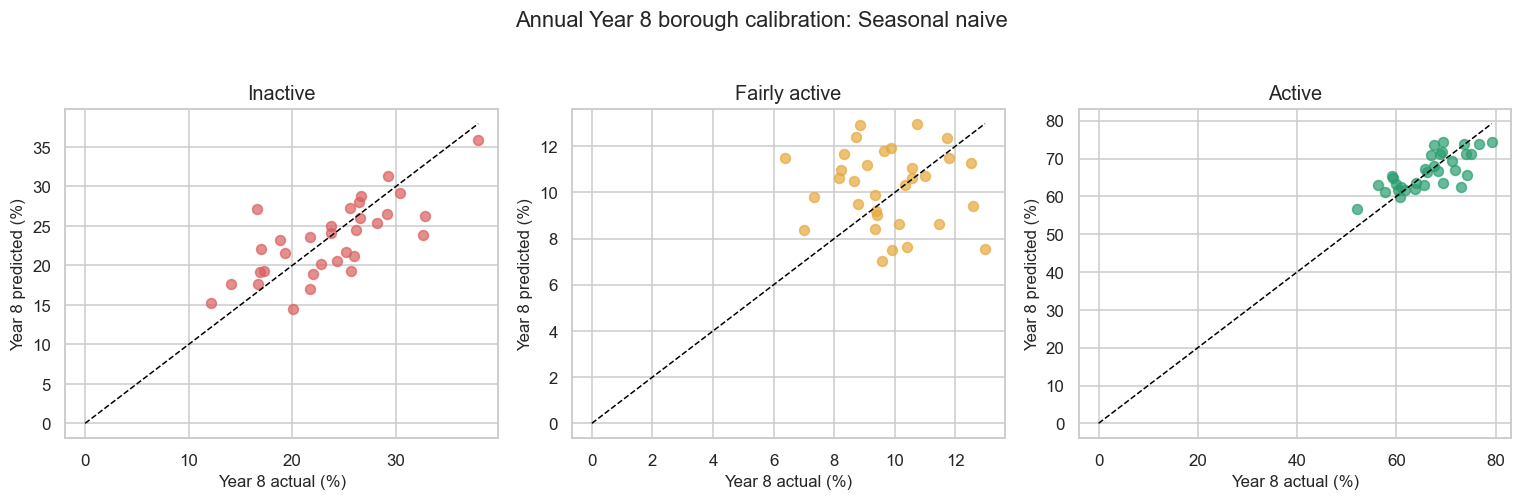

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
annual_selected_predictions = annual_test_predictions[ANNUAL_SELECTED_MODEL]
for index, (ax, target) in enumerate(zip(axes, TARGETS)):
    ax.scatter(
        100 * actual_annual_test[:, index],
        100 * annual_selected_predictions[:, index],
        s=42,
        alpha=0.7,
        color=colors[index],
    )
    limits = [
        0,
        100 * max(actual_annual_test[:, index].max(), annual_selected_predictions[:, index].max()),
    ]
    ax.plot(limits, limits, color='black', linestyle='--', linewidth=1)
    ax.set(title=TARGET_LABELS[target], xlabel='Year 8 actual (%)', ylabel='Year 8 predicted (%)')
plt.suptitle(f'Annual Year 8 borough calibration: {ANNUAL_SELECTED_MODEL}', y=1.03)
plt.tight_layout()
plt.show()

for predicted in annual_test_predictions.values():
    assert np.allclose(predicted.sum(axis=1), 1.0, atol=1e-12)
    assert ((predicted >= 0) & (predicted <= 1)).all()


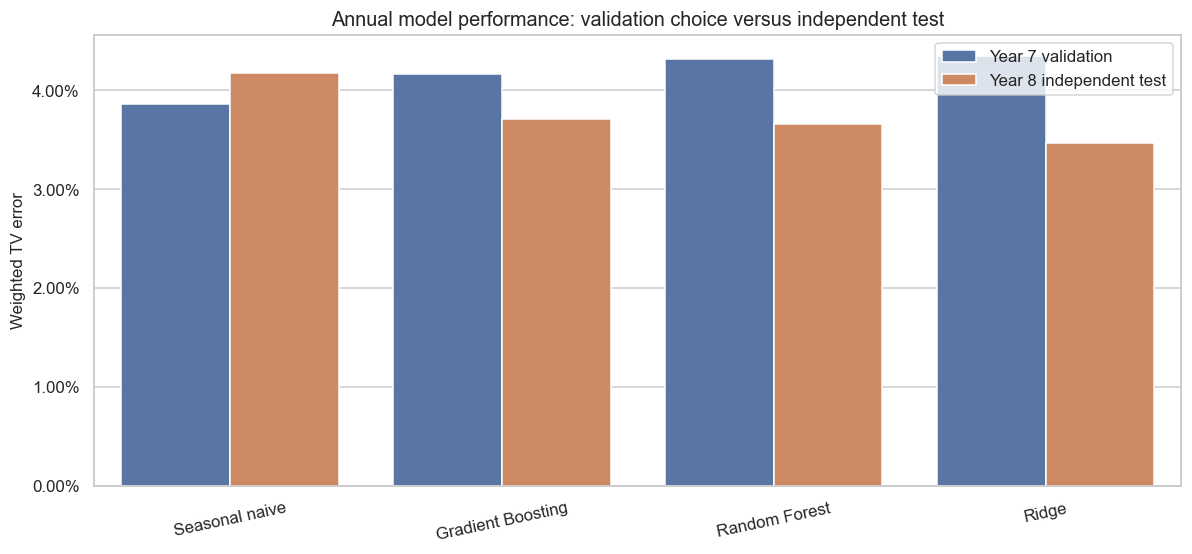

,model,validation_weighted_tv,test_weighted_tv,validation_rank,test_rank,rank_change
0,Seasonal naive,0.0386,0.0418,1,4,+3
1,Gradient Boosting,0.0416,0.0371,2,3,+1
2,Random Forest,0.0431,0.0366,3,2,-1
3,Ridge,0.0435,0.0346,4,1,-3


In [51]:
annual_phase_metrics = pd.concat(
    [
        annual_validation_metrics.assign(phase='Year 7 validation'),
        annual_test_metrics.assign(phase='Year 8 independent test'),
    ],
    ignore_index=True,
)
annual_stability = (
    annual_validation_metrics[['model', 'weighted_tv']]
    .rename(columns={'weighted_tv': 'validation_weighted_tv'})
    .merge(
        annual_test_metrics[['model', 'weighted_tv']].rename(
            columns={'weighted_tv': 'test_weighted_tv'}
        ),
        on='model',
        how='inner',
        validate='one_to_one',
    )
)
annual_stability['validation_rank'] = annual_stability['validation_weighted_tv'].rank(method='min')
annual_stability['test_rank'] = annual_stability['test_weighted_tv'].rank(method='min')
annual_stability['rank_change'] = (
    annual_stability['test_rank'] - annual_stability['validation_rank']
)
annual_stability.to_csv(
    OUTPUT_DIR / 'annual_forecast_validation_test_stability.csv', index=False, encoding='utf-8-sig'
)

fig, ax = plt.subplots(figsize=(11, 5.2))
sns.barplot(data=annual_phase_metrics, x='model', y='weighted_tv', hue='phase', ax=ax)
ax.set(
    title='Annual model performance: validation choice versus independent test',
    xlabel='',
    ylabel='Weighted TV error',
)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.tick_params(axis='x', rotation=12)
ax.legend(title='')
plt.tight_layout()
plt.show()
display(
    annual_stability.sort_values('validation_rank').style.format(
        {
            'validation_weighted_tv': '{:.4f}',
            'test_weighted_tv': '{:.4f}',
            'validation_rank': '{:.0f}',
            'test_rank': '{:.0f}',
            'rank_change': '{:+.0f}',
        }
    )
)


### Findings

Year 7 validation selects **Seasonal Naive** with TV **0.0386**. In Year 8 the ranking reverses:
Ridge is best at **0.0346**, while the frozen selected naive model records **0.0418**. The test-year
winner is reported as stability evidence but is not substituted after testing. Annual forecasting
is therefore a limited one-validation-year/one-test-year backtest, not a settled model comparison.


## 16. Decision on cluster-level forecasting

Cluster labels are evaluated only as a possible new forecasting level. A cluster forecast is
allowed only if the grouping is stable, meaningfully finer than Inner/Outer London and supported
by an independent sample size. The assertion below enforces the recorded decision.


In [52]:
assert not USE_CLUSTER_FORECASTS
assert cluster_assignments['cluster'].notna().all()


### Decision

No cluster-level monthly or annual model is fitted. The weakly separated two-cluster summary is
not an independent forecasting level, substantially overlaps existing Inner/Outer work and would
leave too little data per group. Borough forecasts remain independent of cluster labels.


## 17. Final decision register

This last table collects the pre-declared decision, supporting evidence and interpretation limit
for each analytical component. Assertions ensure that the displayed conclusion matches the model,
cluster and test objects created above.


In [53]:
monthly_selected_test = test_metrics.loc[test_metrics['model'].eq(SELECTED_MODEL)].iloc[0]
annual_selected_test = annual_test_metrics.loc[
    annual_test_metrics['model'].eq(ANNUAL_SELECTED_MODEL)
].iloc[0]
annual_test_winner = annual_test_metrics.iloc[0]

final_decisions = pd.DataFrame(
    [
        {
            'component': 'External data in monthly forecast',
            'decision': (
                'Retain lagged external inputs'
                if FORECAST_USE_EXTERNAL_CONTEXT
                else 'Keep external data for description/clustering; omit from forecasts'
            ),
            'evidence': (
                f'model-specific development-only ablation; selected-model gain={external_cv_gain:.4f}; '
                f'minimum required gain={CONTEXT_MIN_CV_GAIN:.4f}'
            ),
        },
        {
            'component': 'Monthly borough forecast',
            'decision': f'{MONTHLY_BOROUGH_STATUS}: retain as a backtest with explicit precision warnings',
            'evidence': (
                f'median effective_n={median_effective_n:.2f}; {share_below_20:.1%} below 20; '
                f'selected={SELECTED_MODEL}; test TV={monthly_selected_test["weighted_tv"]:.4f}; '
                f'Active MAE={monthly_selected_test["active_rate_mae"]:.1%}; '
                f'Inactive MAE={monthly_selected_test["inactive_rate_mae"]:.1%}; '
                f'Fairly-active R2={monthly_selected_test["fairly_active_rate_r2"]:.3f}'
            ),
        },
        {
            'component': 'Compact activity sensitivity',
            'decision': 'Retain all 372 fields in the primary benchmark; report 51-index model separately',
            'evidence': 'Development-only comparison for Ridge, Random Forest and Gradient Boosting; test year not used',
        },
        {
            'component': 'Monthly empirical error bands',
            'decision': 'Treat as descriptive empirical bands, not p05/p95 model quantiles',
            'evidence': 'Calibrated from rolling-development absolute residuals; componentwise bounds are not a joint simplex region',
        },
        {
            'component': 'Monthly split',
            'decision': 'Keep chronological base train + three rolling validation folds + untouched final-year test',
            'evidence': 'All data are published, but time-order simulation is required to prevent future-regime leakage',
        },
        {
            'component': 'Annual borough forecast',
            'decision': f'Retain only as a limited one-year validation/test backtest; selected={ANNUAL_SELECTED_MODEL}',
            'evidence': (
                f'selected-model test weighted TV={annual_selected_test["weighted_tv"]:.4f}; '
                f'test-year best={annual_test_winner["model"]}; model ranks reverse materially across the two years'
            ),
        },
        {
            'component': 'Borough clustering',
            'decision': 'Descriptive only; do not add cluster-level forecasts',
            'evidence': (
                f'chosen={CHOSEN_CLUSTER_METHOD}, k={CHOSEN_N_CLUSTERS}, '
                f'silhouette={chosen_cluster_row["silhouette"]:.3f}; '
                f'Inner/Outer agreement={inner_outer_agreement:.1%}; '
                f'sensitivity ARI minimum={cluster_sensitivity["ari_vs_selected_solution"].min():.3f}'
            ),
        },
    ]
)
final_decisions.to_csv(
    OUTPUT_DIR / 'question1_final_decisions.csv', index=False, encoding='utf-8-sig'
)
display(final_decisions)

assert MONTHLY_BOROUGH_EXPLORATORY
assert not USE_CLUSTER_FORECASTS
assert set(test_metrics['model']) == {
    'Seasonal naive',
    'Ridge',
    'Random Forest',
    'Gradient Boosting',
}
assert set(annual_test_metrics['model']) == {
    'Seasonal naive',
    'Ridge',
    'Random Forest',
    'Gradient Boosting',
}


,component,decision,evidence
0,External data in monthly forecast,Retain lagged external inputs,model-specific development-only ablation; sele...
1,Monthly borough forecast,Exploratory: retain as a backtest with explici...,median effective_n=25.18; 25.9% below 20; sele...
2,Compact activity sensitivity,Retain all 372 fields in the primary benchmark...,"Development-only comparison for Ridge, Random ..."
3,Monthly empirical error bands,"Treat as descriptive empirical bands, not p05/...",Calibrated from rolling-development absolute r...
4,Monthly split,Keep chronological base train + three rolling ...,"All data are published, but time-order simulat..."
5,Annual borough forecast,Retain only as a limited one-year validation/t...,selected-model test weighted TV=0.0418; test-y...
6,Borough clustering,Descriptive only; do not add cluster-level for...,"chosen=K-means, k=2, silhouette=0.234; Inner/O..."


### Final interpretation

The defensible deliverable is a transparent set of backtests with explicit limits: exploratory
monthly borough forecasts, a fragile annual rank comparison, descriptive borough clusters and no
cluster forecast. External context is retained only where development-only ablation supports it;
the independent test is never used to rewrite a selection decision.
